# 🎓 AILS — Système de Recommandation Adaptatif Immersif
**Pipeline complet · Entraînement Synthétique → Données Réelles Google Sheets · Temps Réel**

| Ressource | Lien |
|-----------|------|
| 📊 Google Sheet | `16JtPQ5ZF0TeV7e-Gt0u8LRGRQYZTm_jrFhkusu3CYow` |
| 📱 Form 1 — Profil (Inter-module) | [Ouvrir](https://docs.google.com/forms/d/e/1FAIpQLScv_Aj7WfwUaUBtSBlYrh1zE3pHSuaSDjqAWKBCGuBYqxpRkg/viewform) |
| 📱 Form 2 — Auto-éval (Intra-module) | [Ouvrir](https://docs.google.com/forms/d/e/1FAIpQLSeRDZzG3r4EfHeXDlXPc76ruzKmyBLFo6P9z0JLJTXk2w81fA/viewform) |

**Onglets Sheet :** `Learner_Profile` · `Cognitive_Load` · `Form Responses 1` · `Form Responses 2` · `AILS_Results`

**Ordre d'exécution :**
1. Cellules **1→7** : Installation + chargement + nettoyage données
2. Cellules **8→10** : 🏗️ Génération base synthétique + pré-entraînement modèles
3. Cellules **11→14** : Définition AILS + fusion DB + batch pipeline
4. Cellule **15** : 📊 Métriques d'évaluation complètes (CF + CL)
5. Cellules **16→17** : 🔄 Ré-application sur Form Responses 1 & 2 + comparaison
6. Cellules **18→23** : 🔴 Surveillance temps réel
7. Cellules **21→25** : 🧪 **EXPÉRIMENTATION RÉELLE** — RAG + Exercices Bac + Boucle complète

texte en italique## ⚠️ IMPORTANT: Accès à la Google Sheet — Clarification

Il est crucial de comprendre comment les permissions Google fonctionnent avec Colab :

Lorsque ce notebook utilise `auth.authenticate_user()` et accède à une Google Sheet, il le fait **avec les droits du compte Google authentifié dans Colab**. Cela signifie que si vous partagez ce code avec une autre personne, cette personne devra s'authentifier avec **son propre compte Google**, et **ce compte Google devra avoir les permissions nécessaires** pour accéder à la feuille de calcul.

**Implication clé :** Si le compte Google d'un utilisateur a les permissions d'accéder à la feuille de calcul via Colab (même en simple lecture), cet utilisateur pourra également **voir la feuille de calcul directement via l'interface de Google Sheets** (par exemple, dans la section 'Partagés avec moi' ou en ouvrant le lien direct).

Il n'existe pas de méthode standard pour qu'un compte Google ait un accès purement "aveugle" (programmatic) sans pouvoir visualiser le contenu de la feuille de calcul.

---

**Scénario 1 : Accès restreint (recommandé si vous êtes le seul utilisateur ou si vous partagez avec un groupe très restreint et que la visibilité est acceptable) :**

1.  **Assurez-vous que votre compte Google** (celui que vous utilisez pour vous authentifier dans Colab) **a les droits appropriés** (propriétaire, éditeur ou lecteur) sur la Google Sheet. Aucune action supplémentaire n'est requise si vous êtes le propriétaire.
2.  Si vous partagez le notebook, vous devrez **partager la Google Sheet individuellement avec chaque compte Google** qui exécutera le code. **Ne modifiez PAS les paramètres de partage généraux** pour 'Toute personne disposant du lien'.

---

**Scénario 2 : Accès public (pour une collaboration ouverte où la visibilité de la feuille par le lien est acceptable) :**

Si vous souhaitez que **n'importe quel utilisateur** puisse exécuter ce notebook et que le code accède à la feuille de calcul **sans avoir à partager la feuille individuellement** avec chacun, la feuille doit être rendue accessible via un lien public.

1.  Ouvrez votre Google Sheet (lien : `https://docs.google.com/spreadsheets/d/16JtPQ5ZF0TeV7e-Gt0u8LRGRQYZTm_jrFhkusu3CYow/edit`).
2.  Cliquez sur le bouton **"Partager"** (en haut à droite).
3.  Dans la section "Accès général", changez l'option de "Accès restreint" à **"Toute personne disposant du lien"**.
4.  Assurez-vous que le rôle est défini sur **"Éditeur"** pour permettre au notebook d'écrire des résultats (si nécessaire, sinon "Lecteur" peut suffire pour les lectures).
5.  Cliquez sur **"OK"** ou **"Terminé"**.

Dans ce cas, tout utilisateur qui a le lien du notebook (et potentiellement le lien de la feuille, si la feuille n'est pas découverte via le code) pourra accéder à la feuille. Le `PermissionError` ne devrait pas apparaître.

## 🚀 Accès sécurisé : Utilisation d'un Compte de Service Google Cloud (Service Account)

Pour permettre à votre notebook Colab d'accéder à la Google Sheet *sans donner un accès direct à chaque utilisateur* qui exécute le code, nous allons utiliser un **Compte de Service Google Cloud**. Ce "compte" est une identité non humaine qui peut s'authentifier auprès de Google et accéder à vos ressources.

### Étapes de configuration (à faire une seule fois) :

1.  **Créer un projet Google Cloud (si vous n'en avez pas) :**
    *   Allez sur la [Console Google Cloud](https://console.cloud.google.com/).
    *   Créez un nouveau projet ou sélectionnez-en un existant.

2.  **Activer l'API Google Drive et Google Sheets :**
    *   Dans le panneau de navigation, allez à `APIs & Services > Library`.
    *   Recherchez et activez `Google Drive API` et `Google Sheets API`.

3.  **Créer un Compte de Service :**
    *   Dans le panneau de navigation, allez à `IAM & Admin > Service Accounts`.
    *   Cliquez sur `+ CREATE SERVICE ACCOUNT`.
    *   Donnez un nom au compte de service (ex: `colab-sheet-access`).
    *   Cliquez sur `DONE`.

4.  **Générer une clé JSON pour le Compte de Service :**
    *   Sur la page `Service Accounts`, cliquez sur les trois points `⋮` à droite de votre nouveau compte de service.
    *   Sélectionnez `Manage keys`.
    *   Cliquez sur `ADD KEY > Create new key`.
    *   Choisissez `JSON` comme type de clé et cliquez sur `CREATE`.
    *   Un fichier `.json` sera téléchargé sur votre ordinateur. **Gardez-le en sécurité !** C'est la "clé" de votre compte de service.

5.  **Partager votre Google Sheet avec le Compte de Service :**
    *   Localisez l'adresse email de votre compte de service. Elle se trouve sur la page `Service Accounts` et ressemble à `votre-compte-service-id@votre-projet-id.iam.gserviceaccount.com`.
    *   Ouvrez votre Google Sheet.
    *   Cliquez sur le bouton **Partager** (en haut à droite).
    *   Collez l'adresse email de votre compte de service dans le champ `Add people and groups`.
    *   Attribuez-lui le rôle `Editor` (si le notebook doit écrire) ou `Viewer` (si seulement en lecture).
    *   Cliquez sur `Send`.

6.  **Stocker la clé JSON en toute sécurité dans Colab Secrets :**
    *   Dans Colab, cliquez sur l'icône `🔑` (Secrets) dans le panneau de gauche.
    *   Ajoutez un nouveau secret, nommez-le par exemple `GOOGLE_SERVICE_ACCOUNT_CREDENTIALS`.
    *   Copiez le *contenu entier* du fichier JSON que vous avez téléchargé (ouvert avec un éditeur de texte) et collez-le comme valeur de ce secret.
    *   Activez l'option `Notebook access` pour ce secret.

Une fois ces étapes réalisées, le code ci-dessous utilisera ce secret pour s'authentifier auprès de Google Sheets via le compte de service, sans exposer vos informations personnelles ni nécessiter que les utilisateurs du notebook aient un accès direct à la feuille.

In [2]:
import json
import gspread
from google.oauth2.service_account import Credentials
from google.colab import userdata

try:
    secret_key = userdata.get('GOOGLE_SERVICE_ACCOUNT_CREDENTIALS')
    credentials_info = json.loads(secret_key)
    credentials_info['private_key'] = credentials_info['private_key'].replace('\\n', '\n')

    scopes = [
        'https://www.googleapis.com/auth/spreadsheets',
        'https://www.googleapis.com/auth/drive'
    ]

    creds = Credentials.from_service_account_info(credentials_info, scopes=scopes)
    gc = gspread.authorize(creds)

    SHEET_ID = "16JtPQ5ZF0TeV7e-Gt0u8LRGRQYZTm_jrFhkusu3CYow"
    sh = gc.open_by_key(SHEET_ID)

    print(f'✅ Connecté à Google Sheet : {sh.title}')
    print(f'   Feuilles : {[ws.title for ws in sh.worksheets()]}')

except Exception as e:
    print(f'❌ Erreur authentification : {e}')
    print('   → Vérifiez que le secret GOOGLE_SERVICE_ACCOUNT_CREDENTIALS est configuré.')

✅ Connecté à Google Sheet : AILS_Database
   Feuilles : ['Form Responses 2', 'Form Responses 1', 'Learner_Profile', 'Cognitive_Load', 'AILS_Results']


⚠️ **Note :** Si vous utilisez cette méthode, la section `auth.authenticate_user()` de la cellule 2 (`b788946c`) deviendra redondante pour l'accès aux feuilles et pourra être supprimée ou commentée pour éviter toute confusion ou double authentification.

Maintenant que nous avons mis à jour la méthode d'authentification, je vais commenter l'ancienne méthode de la cellule `b78896c`.

In [3]:

!pip install -q gspread google-auth pandas numpy scikit-learn matplotlib seaborn scipy requests ipywidgets
print('✅ Dépendances installées')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 21.4 MB/s eta 0:00:00
✅ Dépendances installées


In [4]:
import gspread
from google.colab import auth
from google.auth import default
from google.colab import userdata

MISTRAL_API_KEY = userdata.get('MISTRAL_API_KEY')

MISTRAL_MODEL   = 'mistral-medium-2312'

SHEET_ID             = '16JtPQ5ZF0TeV7e-Gt0u8LRGRQYZTm_jrFhkusu3CYow'
TAB_LEARNER_PROFILE  = 'Learner_Profile'
TAB_COGNITIVE_LOAD   = 'Cognitive_Load'
TAB_FORM_ONBOARDING  = 'Form Responses 1'
TAB_FORM_POSTEX      = 'Form Responses 2'
RESULTS_TAB_NAME     = 'AILS_Results'

USE_LLM = bool(MISTRAL_API_KEY)
print(f"Mode LLM : {'✅ Mistral ACTIVÉ' if USE_LLM else '⚠️  template'}")


Mode LLM : ✅ Mistral ACTIVÉ


In [5]:

import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')

def load_sheet_tab(tab_name):
    try:
        ws   = sh.worksheet(tab_name)
        data = ws.get_all_records()
        df   = pd.DataFrame(data)
        print(f'  ✅ {tab_name:<30} → {df.shape[0]:>4} lignes × {df.shape[1]:>3} colonnes')
        return df
    except gspread.exceptions.WorksheetNotFound:
        print(f"  ⚠️  Onglet '{tab_name}' introuvable — DataFrame vide")
        return pd.DataFrame()

print('📥 Chargement...')
df_profile = load_sheet_tab(TAB_LEARNER_PROFILE)
df_cl_raw  = load_sheet_tab(TAB_COGNITIVE_LOAD)
df_form1   = load_sheet_tab(TAB_FORM_ONBOARDING)
df_form2   = load_sheet_tab(TAB_FORM_POSTEX)

print('\n📋 Colonnes disponibles :')
for name, df in [(TAB_LEARNER_PROFILE,df_profile),(TAB_COGNITIVE_LOAD,df_cl_raw),
                  (TAB_FORM_ONBOARDING,df_form1),(TAB_FORM_POSTEX,df_form2)]:
    if not df.empty:
        print(f'  [{name}]')
        for col in df.columns:
            print(f'    - {col}  ({df[col].dtype})')

📥 Chargement...
  ✅ Learner_Profile                →    0 lignes ×   0 colonnes
  ✅ Cognitive_Load                 →    0 lignes ×   0 colonnes
  ✅ Form Responses 1               →   34 lignes ×  19 colonnes
  ✅ Form Responses 2               →   52 lignes ×  13 colonnes

📋 Colonnes disponibles :
  [Form Responses 1]
    - Timestamp  (object)
    - Email Address  (object)
    - Age  (int64)
    - Gender  (object)
    - Current educational level  (object)
    - Subject / domain of study  (object)
    - I feel comfortable with this subject.  (object)
    - I already have prior knowledge in this topic.  (object)
    - I usually understand new concepts in this subject quickly.  (object)
    - I am confident in my ability to solve exercises in this subject.  (object)
    - I often need additional help when solving exercises in this subject.  (object)
    - I prefer step-by-step explanations.  (object)
    - I prefer exercises with hints.  (object)
    - I prefer concise instructions rather 

In [6]:

import re

LIKERT_MAP = {
    '1':1,'2':2,'3':3,'4':4,'5':5,
    'strongly disagree':1,'disagree':2,'slightly disagree':3,
    'neutral':3,'slightly agree':3,'agree':4,'strongly agree':5,
    'not at all':1,'a little':2,'somewhat':3,'quite a bit':4,'extremely':5,
    'very low':1,'low':2,'moderate':3,'high':4,'very high':5,
}

def parse_likert(val):
    if pd.isna(val) or str(val).strip() == '': return np.nan
    s = str(val).strip()
    m = re.match(r'^(\d+)', s)
    if m: return int(m.group(1))
    lo = s.lower()
    for k, v in LIKERT_MAP.items():
        if k in lo: return v
    try: return float(s)
    except: return np.nan

def normalize_col_name(col):
    col = re.sub(r'[^\w\s]', '', str(col).strip())
    col = re.sub(r'\s+', '_', col)
    return col.lower()[:60]

def detect_id_column(df):
    patterns = ['learner_id','learner id','student_id','provided by the experimenter','identifiant']
    for col in df.columns:
        if any(p in col.lower() for p in patterns): return col
    return None

def clean_dataframe(df, name, is_likert=False):
    if df.empty: return df
    df = df.copy()
    before = len(df)
    df.replace('', np.nan, inplace=True)
    df.dropna(how='all', inplace=True)
    print(f'  [{name}] Lignes vides : {before-len(df)}')
    before = len(df)
    df.drop_duplicates(inplace=True)
    print(f'  [{name}] Doublons : {before-len(df)}')
    df.columns = [normalize_col_name(c) for c in df.columns]
    for tc in [c for c in df.columns if 'timestamp' in c]:
        df[tc] = pd.to_datetime(df[tc], errors='coerce')
    id_col = detect_id_column(df)
    if id_col:
        df[id_col] = pd.to_numeric(df[id_col], errors='coerce')
    if is_likert:
        skip = {'timestamp', id_col, 'exercise_id', 'module_id', 'email_address'}
        for col in df.columns:
            if col in skip or 'timestamp' in col or col.endswith('_id'): continue
            if df[col].dtype == object:
                df[col] = df[col].apply(parse_likert)
                df[col] = pd.to_numeric(df[col], errors='coerce')
    num_cols = df.select_dtypes(include=[np.number]).columns
    for col in num_cols:
        n_miss = df[col].isna().sum()
        if n_miss > 0:
            med = df[col].median()
            df[col].fillna(med, inplace=True)
            print(f'  [{name}] Imputation "{col}" : {n_miss} → {med:.2f}')
    empty_after = [c for c in df.columns if df[c].isna().all()]
    if empty_after:
        df.drop(columns=empty_after, inplace=True)
    print(f'  [{name}] ✅ {df.shape[0]} lignes × {df.shape[1]} col.')
    return df

print('🧹 Nettoyage...\n')
df_profile_clean = clean_dataframe(df_profile, TAB_LEARNER_PROFILE)
df_cl_clean      = clean_dataframe(df_cl_raw,  TAB_COGNITIVE_LOAD)
df_form1_clean   = clean_dataframe(df_form1,   TAB_FORM_ONBOARDING, is_likert=True)
df_form2_clean   = clean_dataframe(df_form2,   TAB_FORM_POSTEX,     is_likert=True)
print('\n✅ Nettoyage terminé.')

🧹 Nettoyage...

  [Form Responses 1] Lignes vides : 0
  [Form Responses 1] Doublons : 0
  [Form Responses 1] Imputation "gender" : 34 → nan
  [Form Responses 1] Imputation "current_educational_level" : 17 → 4.00
  [Form Responses 1] Imputation "subject_domain_of_study" : 34 → nan
  [Form Responses 1] Imputation "i_feel_motivated_when_solving_exercises_in_this_subject" : 6 → 4.50
  [Form Responses 1] Imputation "which_type_of_instructional_support_do_you_prefer_most" : 34 → nan
  [Form Responses 1] Imputation "which_exercise_difficulty_do_you_usually_prefer" : 23 → 3.00
  [Form Responses 1] Imputation "when_i_make_mistakes_i_prefer" : 34 → nan
  [Form Responses 1] ✅ 34 lignes × 15 col.
  [Form Responses 2] Lignes vides : 0
  [Form Responses 2] Doublons : 0
  [Form Responses 2] ✅ 52 lignes × 13 col.

✅ Nettoyage terminé.


In [7]:

def find_col(df, keywords, default=None):
    for col in df.columns:
        if any(k.lower() in col.lower() for k in keywords): return col
    return default

def find_cols_containing(df, keywords):
    return [c for c in df.columns if any(k.lower() in c.lower() for k in keywords)]

print('🔍 Mapping colonnes...\n')

COL_LEARNER_ID = find_col(df_profile_clean, ['learner_id','id','student'])
COL_PRIOR      = find_col(df_profile_clean, ['prior','knowledge','niveau_initial','level'])
COL_CONFIDENCE = find_col(df_profile_clean, ['confidence','confiance'])
COL_MOTIVATION = find_col(df_profile_clean, ['motivation','motivat'])
COL_GROUP      = find_col(df_profile_clean, ['group','groupe','class','niveau'])
print(f'Learner_Profile → id={COL_LEARNER_ID} | prior={COL_PRIOR} | conf={COL_CONFIDENCE} | motiv={COL_MOTIVATION}')

COL_CL_LEARNER  = find_col(df_cl_clean, ['learner_id','learner','id','student'])
COL_CL_MODULE   = find_col(df_cl_clean, ['module','module_id'])
COL_CL_EXERCISE = find_col(df_cl_clean, ['exercise','exercice','ex_id'])
COL_HEAD_MV     = find_col(df_cl_clean, ['head','tete','movement','mouvement'])
COL_GAZE        = find_col(df_cl_clean, ['gaze','regard','yeux','oculo'])
COL_INTERACT    = find_col(df_cl_clean, ['interact','revision','answer','event'])
COL_RESP_TIME   = find_col(df_cl_clean, ['response_time','temps','latency','time','duree'])
COL_SCORE       = find_col(df_cl_clean, ['score','grade','note','result','correct'])
COL_ERROR_TYPE  = find_col(df_cl_clean, ['error','erreur','type','dominant'])
print(f'\nCognitive_Load → head={COL_HEAD_MV} | gaze={COL_GAZE}')

COL_F2_LEARNER  = find_col(df_form2_clean, ['learner_id','learner','id','email'])
COL_F2_EXERCISE = find_col(df_form2_clean, ['exercise_id','exercise','exercice'])
likert_cl_cols  = find_cols_containing(df_form2_clean,
    ['mental','difficult','hesit','confus','effort','frustrat','demand','found','felt'])
print(f'\nForm Responses 2 → learner={COL_F2_LEARNER} | Likert CL : {likert_cl_cols}')

🔍 Mapping colonnes...

Learner_Profile → id=None | prior=None | conf=None | motiv=None

Cognitive_Load → head=None | gaze=None

Form Responses 2 → learner=email_address | Likert CL : ['this_exercise_required_a_high_level_of_mental_effort', 'i_found_this_exercise_difficult', 'i_felt_hesitant_or_unsure_while_solving_this_exercise', 'i_felt_under_time_pressure_while_solving_this_exercise', 'i_felt_confident_about_my_answer', 'i_felt_frustrated_while_working_on_this_exercise', 'i_had_difficulty_identifying_what_was_being_asked', 'i_felt_that_the_amount_of_information_was_overwhelming']


In [8]:

from sklearn.preprocessing import MinMaxScaler

def minmax_normalize_cols(df, cols, suffix='_norm'):
    cols_valid = [c for c in cols if c and c in df.columns]
    if not cols_valid: return df, None, []
    for c in cols_valid:
        df[c] = pd.to_numeric(df[c], errors='coerce')
    scaler = MinMaxScaler()
    normalized = scaler.fit_transform(df[cols_valid].fillna(df[cols_valid].median()))
    for i, col in enumerate(cols_valid):
        df[col+suffix] = normalized[:,i].round(4)
    return df, scaler, cols_valid

cl_signal_cols = [c for c in [COL_HEAD_MV,COL_GAZE,COL_INTERACT,COL_RESP_TIME] if c]
if cl_signal_cols and not df_cl_clean.empty:
    df_cl_clean, scaler_cl, norm_cols = minmax_normalize_cols(df_cl_clean, cl_signal_cols)
    COL_HEAD_NORM     = COL_HEAD_MV   + '_norm' if COL_HEAD_MV   else None
    COL_GAZE_NORM     = COL_GAZE      + '_norm' if COL_GAZE      else None
    COL_INTERACT_NORM = COL_INTERACT  + '_norm' if COL_INTERACT  else None
    COL_RT_NORM       = COL_RESP_TIME + '_norm' if COL_RESP_TIME else None
    print(f'✅ Signaux VR normalisés : {norm_cols}')
else:
    COL_HEAD_NORM = COL_GAZE_NORM = COL_INTERACT_NORM = COL_RT_NORM = None
    print('⚠️  Cognitive_Load vide — signaux VR non disponibles')

if COL_SCORE and COL_SCORE in df_cl_clean.columns:
    df_cl_clean[COL_SCORE] = pd.to_numeric(df_cl_clean[COL_SCORE], errors='coerce')
    s_min, s_max = df_cl_clean[COL_SCORE].min(), df_cl_clean[COL_SCORE].max()
    df_cl_clean['score_norm'] = ((df_cl_clean[COL_SCORE]-s_min)/(s_max-s_min)).round(4) if s_max>1.0 else df_cl_clean[COL_SCORE]
    COL_SCORE_NORM = 'score_norm'
else:
    COL_SCORE_NORM = None

if likert_cl_cols and not df_form2_clean.empty:
    for col in likert_cl_cols:
        df_form2_clean[col] = pd.to_numeric(df_form2_clean[col], errors='coerce')
    df_form2_clean['tlx_score'] = df_form2_clean[likert_cl_cols].mean(axis=1).round(4)
    df_form2_clean['tlx_score_norm'] = ((df_form2_clean['tlx_score']-1)/4).round(4)
    print(f'✅ NASA-TLX ({len(likert_cl_cols)} items) → tlx_score_norm [0,1]')
    print(f'   mean={df_form2_clean["tlx_score_norm"].mean():.3f}  N={len(df_form2_clean)}')
else:
    print('⚠️  Aucune colonne Likert trouvée dans Form Responses 2')

prof_cols = [c for c in [COL_PRIOR,COL_CONFIDENCE,COL_MOTIVATION] if c]
if prof_cols and not df_profile_clean.empty:
    df_profile_clean, _, _ = minmax_normalize_cols(df_profile_clean, prof_cols)
    print(f'✅ Profil normalisé : {prof_cols}')

⚠️  Cognitive_Load vide — signaux VR non disponibles
✅ NASA-TLX (8 items) → tlx_score_norm [0,1]
   mean=0.642  N=52


## 🏗️ Partie 1 — Entraînement sur Base Synthétique Professionnelle

In [9]:

import numpy as np
import pandas as pd
import math, re, json
from scipy.stats import truncnorm
from datetime import datetime

np.random.seed(42)

SAMPLING_RATE_HZ            = 90
GAZE_DISPERSION_WINDOW_SEC  = 2
NORMALIZATION_WINDOW_SEC    = 60
ALIGNMENT_LATENCY_MS        = 20
GAZE_HIGH_THRESHOLD         = 0.7
HEAD_LOW_THRESHOLD          = 0.3
VR_FEATURE_AGGREGATION_SEC  = 1

MODULES = {
    'M01': {'title': 'Variables & Types',            'difficulty': 1, 'prerequisites': [],                     'theta': 0.75},
    'M02': {'title': 'Conditionnelles',              'difficulty': 1, 'prerequisites': ['M01'],                'theta': 0.75},
    'M03': {'title': 'Boucles',                      'difficulty': 2, 'prerequisites': ['M01', 'M02'],         'theta': 0.75},
    'M04': {'title': 'Tableaux',                     'difficulty': 2, 'prerequisites': ['M01', 'M03'],         'theta': 0.78},
    'M05': {'title': 'Fonctions',                    'difficulty': 3, 'prerequisites': ['M02', 'M03'],         'theta': 0.78},
    'M06': {'title': 'Récursivité',                  'difficulty': 4, 'prerequisites': ['M05'],                'theta': 0.80},
    'M07': {'title': 'Matrices',                     'difficulty': 3, 'prerequisites': ['M04'],                'theta': 0.78},
    'M08': {'title': 'Logique Formelle',             'difficulty': 3, 'prerequisites': ['M02'],                'theta': 0.80},
    'M09': {'title': 'Complexité & Algorithmes de Tri','difficulty': 4,'prerequisites': ['M03', 'M05'],        'theta': 0.82},
    'M10': {'title': 'Graphes',                      'difficulty': 5, 'prerequisites': ['M06', 'M07', 'M09'], 'theta': 0.82},
}
MODULE_ORDER = ['M01','M02','M03','M04','M05','M06','M07','M08','M09','M10']

ALPHA, BETA, GAMMA, DELTA = 0.25, 0.25, 0.30, 0.20

N_WINDOW            = 3
EXP_MASTERY_WINDOW  = 3
EXP_MASTERY_SCORE   = 0.70
EXP_MASTERY_CL_MAX  = 0.50
EXP_MAX_EXERCISES   = 15

POPULATION_CF = {
    'Novice':        {'n': 34, 'prior': (0.22, 0.12), 'conf': (0.25, 0.13), 'motiv': (0.48, 0.14),
                      'h_base': (0.68, 0.08), 'g_base': (0.60, 0.08), 'e_base': (0.52, 0.08), 'r_base': (0.58, 0.08)},
    'Intermédiaire': {'n': 33, 'prior': (0.52, 0.12), 'conf': (0.53, 0.13), 'motiv': (0.68, 0.13),
                      'h_base': (0.38, 0.08), 'g_base': (0.32, 0.08), 'e_base': (0.28, 0.08), 'r_base': (0.34, 0.08)},
    'Avancé':        {'n': 33, 'prior': (0.76, 0.10), 'conf': (0.77, 0.10), 'motiv': (0.81, 0.10),
                      'h_base': (0.16, 0.08), 'g_base': (0.12, 0.08), 'e_base': (0.10, 0.08), 'r_base': (0.15, 0.08)},
}
POPULATION_SYN = {
    'G1_Novice':       {'n': 10, 'label': 'G1 – Novice',
                        'prior': (0.20, 0.10), 'conf': (0.22, 0.10), 'motiv': (0.45, 0.12),
                        'h_base': (0.70, 0.08), 'g_base': (0.62, 0.08), 'e_base': (0.55, 0.08), 'r_base': (0.60, 0.08)},
    'G2_Intermediate': {'n': 10, 'label': 'G2 – Intermediate',
                        'prior': (0.52, 0.12), 'conf': (0.53, 0.13), 'motiv': (0.68, 0.13),
                        'h_base': (0.38, 0.08), 'g_base': (0.32, 0.08), 'e_base': (0.28, 0.08), 'r_base': (0.34, 0.08)},
    'G3_Advanced':     {'n': 10, 'label': 'G3 – Advanced',
                        'prior': (0.76, 0.10), 'conf': (0.77, 0.10), 'motiv': (0.81, 0.10),
                        'h_base': (0.16, 0.08), 'g_base': (0.12, 0.08), 'e_base': (0.10, 0.08), 'r_base': (0.15, 0.08)},
}
POPULATION = POPULATION_CF

def classify_cl(cl_value: float) -> tuple:
    """
    Classifie l'état cognitif selon Table 4 de l'article.
    ✅ Seuils : 0.30 / 0.60 / 0.80 (article Section 3.2)
    Returns: (state: str, action: str)
    """
    cl = float(cl_value)
    cl = max(0.0, min(1.0, cl))
    if cl < 0.30:
        return ('Confidence',  '✨ Excellent ! Exercice plus difficile (d+1).')
    elif cl < 0.60:
        return ('Exploration', '👍 Bonne progression ! Exercice standard.')
    elif cl < 0.80:
        return ('Hésitation',  '⚠️  Difficultés — 2 indices activés.')
    else:
        return ('Confusion',   '🆘 Surcharge — exercice guidé + alerte enseignant.')

def estimate_cl(h: float, g: float, e: float, r: float):
    """
    Formule CL Eq.(1) : CL = α·ĥ + β·ĝ + γ·ê + δ·r̂
    ✅ α=0.25, β=0.25, γ=0.30, δ=0.20 (article Section 3.2)

    Retourne (cl_value: float, cl_state: str, cl_action: str)
    NOTE : compatibilité avec l'ancien usage estimate_cl()[0] préservée.
    """
    cl = round(ALPHA*float(h) + BETA*float(g) + GAMMA*float(e) + DELTA*float(r), 4)
    cl = max(0.0, min(1.0, cl))
    state, action = classify_cl(cl)
    return (cl, state, action)

def compute_shap(h: float, g: float, e: float, r: float) -> dict:
    """
    SHAP-inspired attribution : φk = wk · x̂k  (article Section 3.2 + 3.4)
    ⚠️ FALLBACK HEURISTIQUE UNIQUEMENT (équivalent de _heuristic_phi en Cellule 9) :
    ce n'est PAS le vrai calcul de Shapley (Eq.8/9) — formule triviale linéaire
    utilisée seulement pour les statistiques agrégées / batch (analytics SYN_LEARNERS
    en Cellule 8, cf. cell15/cell20), PAS pour l'explication affichée à l'apprenant
    (celle-ci utilise get_shap_explanation() -> vrai GradientBoostingRegressor +
    KernelExplainer si disponible, cf. correction #3/#4).
    Retourne le vecteur d'attribution {canal: φk}.
    """
    return {
        'head_movement':      round(ALPHA * float(h), 4),
        'gaze_direction':     round(BETA  * float(g), 4),
        'interaction_events': round(GAMMA * float(e), 4),
        'response_time':      round(DELTA * float(r), 4),
    }

def cl_from_form2(tlx_vals: list) -> float:
    """
    Calcule CL à partir des items Likert Form 2 (proxy NASA-TLX).
    ✅ Remplace les capteurs VR dans l'expérimentation réelle.
    tlx_vals : liste de scores Likert 1-5
    Returns  : CL normalisée [0,1]
    """
    if not tlx_vals:
        return 0.5
    mean_tlx = float(np.mean(tlx_vals))
    if mean_tlx > 1.0:
        return round((mean_tlx - 1) / 4.0, 4)
    return round(mean_tlx, 4)

def cl_fused(cl_beh: float, cl_tlx: float,
             w_beh: float = 0.60, w_tlx: float = 0.40) -> float:
    """
    Fusion CL comportemental (VR) + CL déclaratif (Form 2 / TLX).
    ✅ Eq. implémentée : CL_fused = 0.60·CL_beh + 0.40·TLX_norm
    Quand CL_beh indisponible (pas de VR) → retourne TLX_norm directement.
    """
    if cl_beh is None:
        return cl_tlx
    return round(w_beh * cl_beh + w_tlx * cl_tlx, 4)

def score_evolution(s_prev: float, cl_current: float,
                    eta: float = 0.18,
                    xi: float = None) -> float:
    """
    Mise à jour score conforme article Section 4.2 :
    S^(t+1) = S^(t) + η · (1 - S^(t)) · (1 - CL_t) · ξ
    η=0.18 (learning rate)
    ξ ~ U(0.8, 1.2) (bruit individuel)
    ✅ AJOUTÉE — manquait dans la version précédente
    """
    if xi is None:
        xi = np.random.uniform(0.8, 1.2)
    delta = eta * (1.0 - s_prev) * (1.0 - cl_current) * xi
    return round(min(1.0, s_prev + delta), 4)

def simulate_learner(group_params: dict, n_modules: int = 10,
                     pop_label: str = 'G1') -> dict:
    """
    Génère un apprenant synthétique avec score evolution conforme article.
    ✅ seed=42 global, η=0.18, ξ~U(0.8,1.2), cap=15 exercices/module
    """
    p = group_params
    prior      = float(np.clip(np.random.normal(*p['prior']),  0.01, 0.99))
    confidence = float(np.clip(np.random.normal(*p['conf']),   0.01, 0.99))
    motivation = float(np.clip(np.random.normal(p.get('motiv', (.5,.1))[0],
                                                p.get('motiv', (.5,.1))[1]), 0.01, 0.99))

    h0 = float(np.clip(np.random.normal(*p['h_base']), 0.01, 0.99))
    g0 = float(np.clip(np.random.normal(*p['g_base']), 0.01, 0.99))
    e0 = float(np.clip(np.random.normal(*p['e_base']), 0.01, 0.99))
    r0 = float(np.clip(np.random.normal(*p['r_base']), 0.01, 0.99))

    cl0, _, _ = estimate_cl(h0, g0, e0, r0)

    tlx_label = float(np.clip(cl0 + np.random.normal(0, 0.08), 0, 1))

    mastered = []
    module_progress = {}
    score_current = prior

    for mid in MODULE_ORDER[:n_modules]:
        prereqs = MODULES[mid]['prerequisites']
        if not set(prereqs).issubset(set(mastered)):
            continue

        score_t = score_current
        n_ex    = 0

        while n_ex < EXP_MAX_EXERCISES:

            state, _ = classify_cl(cl0)

            score_t = score_evolution(score_t, cl0, eta=0.18)

            cl0 = max(0.05, cl0 * (0.95 + np.random.normal(0, 0.02)))
            n_ex += 1

            if n_ex >= N_WINDOW and score_t >= MODULES[mid]['theta'] and cl0 <= EXP_MASTERY_CL_MAX:
                mastered.append(mid)
                break

        module_progress[mid] = {
            'score_pre':     round(score_current, 3),
            'score_post':    round(score_t, 3),
            'score_current': round(score_t, 3),
            'mean_cl':       round(cl0, 3),
            'is_mastered':   mid in mastered,
            'nb_exercises':  n_ex,
        }
        score_current = score_t

    return {
        'group':             pop_label,
        'prior_knowledge':   round(prior, 4),
        'confidence':        round(confidence, 4),
        'motivation':        round(motivation, 4),
        'mean_head_movement':round(h0, 4),
        'mean_gaze_disp':    round(g0, 4),
        'mean_interaction_ev':round(e0, 4),
        'mean_response_time':round(r0, 4),
        'mean_cl':           round(cl0, 4),
        'mean_score':        round(score_current, 4),
        'tlx_label':         round(tlx_label, 4),
        'mastered_modules':  mastered,
        'module_progress':   module_progress,
    }

def get_fusion_weights(n_interactions: int, cl_value: float) -> dict:
    """
    Scheduling dynamique des poids conforme à l'article Eq.(4)(5) :
      Cold-start   (n < 3)    : w1=0.70, w3=0.30
      CL-critical  (CL ≥ 0.60): w1=0.20, w3=0.80
      Intra-rich   (sinon)    : w1=0.40, w3=0.60
    ✅ AJOUTÉE — le code précédent utilisait des poids fixes (0.60/0.40)
    """
    if n_interactions < 3:
        return {'w1': 0.70, 'w3': 0.30, 'w2': 0.60, 'w4': 0.40,
                'schedule': 'cold-start'}
    elif cl_value >= 0.60:

        return {'w1': 0.20, 'w3': 0.80, 'w2': 0.40, 'w4': 0.60,
                'schedule': 'CL-critical'}
    else:
        return {'w1': 0.40, 'w3': 0.60, 'w2': 0.60, 'w4': 0.40,
                'schedule': 'intra-rich'}

def score_exercise_fusion(s_cb: float, cl_value: float,
                          n_interactions: int = 5) -> float:
    """
    Score exercice Eq.(4) : Score_Ex = w1·S_CB + w3·(1-CL)
    Avec scheduling dynamique selon n_interactions.
    ✅ CORRIGÉ — utilise get_fusion_weights() au lieu de poids fixes
    """
    w = get_fusion_weights(n_interactions, cl_value)
    return round(w['w1'] * s_cb + w['w3'] * (1.0 - cl_value), 4)

def score_module_fusion(vote_cf: float, compat: float,
                        cl_value: float, n_interactions: int = 5) -> float:
    """
    Score module Eq.(5) : Score_Mod = w2·VoteCF + w4·Compat
    ✅ CORRIGÉ — utilise scheduling dynamique
    """
    w = get_fusion_weights(n_interactions, cl_value)
    return round(w['w2'] * vote_cf + w['w4'] * compat, 4)

CURRICULUM_BLACKLIST = [
    'pointeur', 'pointer', 'malloc', 'free', 'new ', 'delete ',
    'template', 'héritage', 'heritage', 'polymorphisme', 'surcharge',
    'lambda', 'thread', 'mutex', 'socket', 'arbre avl', 'avl tree',
    'graphe pondéré', 'automate', 'regex', 'sql', 'api rest',
    'deep learning', 'neural network', 'transformer', 'bert', 'gpt',
    'blockchain', 'microservice', 'docker', 'kubernetes', 'cloud',
]
REQUIRED_KEYS = {
    'titre', 'contexte', 'questions', 'indices',
    'conseil_pedagogique', 'difficulte_reelle', 'duree_estimee_minutes'
}

def verify_exercise(exercise: dict) -> dict:
    """
    Verification Engine conforme Section 3.3 article.
    ✅ CORRIGÉ : κ ≥ 0.70 → livraison (article dit 0.70, code disait 0.60)
    ✅ AJOUTÉ  : zone retry [0.60, 0.70) — 2 tentatives max
    """
    issues, fixed = [], False

    missing_keys = REQUIRED_KEYS - set(exercise.keys())
    if missing_keys:
        issues.append(f'Clés manquantes : {missing_keys}')

    questions = exercise.get('questions', [])
    if not isinstance(questions, list) or len(questions) == 0:
        issues.append('Aucune question trouvée.')

    try:
        total_pts = sum(int(q.get('points', 0)) for q in questions)
        if total_pts != 10:
            if 8 <= total_pts <= 12 and len(questions) >= 3:
                questions[0]['points'] = 3
                questions[1]['points'] = 4
                questions[2]['points'] = 3
                exercise['questions'] = questions
                issues.append(f'Barème auto-corrigé ({total_pts}→10).')
                fixed = True
            else:
                issues.append(f'Barème incorrect : {total_pts}/10.')
    except Exception:
        issues.append('Impossible de calculer le barème.')

    full_text  = json.dumps(exercise, ensure_ascii=False).lower()
    violations = [t for t in CURRICULUM_BLACKLIST if t in full_text]
    if violations:
        issues.append(f'Concepts hors programme : {violations}')

    kappa = 1.0
    if missing_keys:   kappa -= 0.30 * len(missing_keys)
    if violations:     kappa -= 0.25 * len(violations)
    if any('Barème incorrect' in i and 'auto-corrigé' not in i for i in issues):
        kappa -= 0.20
    elif any('auto-corrigé' in i for i in issues):
        kappa -= 0.05
    kappa = round(max(0.0, min(1.0, kappa)), 3)

    return {
        'kappa':       kappa,
        'passed':      kappa >= 0.70 and not missing_keys and not violations,
        'needs_retry': 0.60 <= kappa < 0.70,
        'fallback':    kappa < 0.60,
        'issues':      issues,
        'fixed':       fixed,
    }

def generate_population(pop_config: dict, id_offset: int = 0,
                        is_cf_pretrain: bool = False) -> list:
    """
    Génère une liste d'apprenants synthétiques.
    pop_config : POPULATION_CF (N=100) ou POPULATION_SYN (N=30)
    id_offset  : pour éviter les conflits d'ID entre les deux populations
    """
    learners = []
    uid = id_offset
    for group_name, params in pop_config.items():
        label = params.get('label', group_name)
        for _ in range(params['n']):
            l = simulate_learner(params, n_modules=len(MODULES), pop_label=label)
            l['id']           = uid
            l['username']     = f'{"syn_cf" if is_cf_pretrain else "syn"}_learner_{uid:03d}'
            l['is_synthetic'] = True
            learners.append(l)
            uid += 1
    return learners

print('🏗️  Génération population synthétique...')

SYN_LEARNERS_CF = generate_population(POPULATION_CF, id_offset=0,
                                       is_cf_pretrain=True)
print(f'  ✅ CF pre-train : {len(SYN_LEARNERS_CF)} apprenants (N=100)')

SYN_LEARNERS_30 = generate_population(POPULATION_SYN, id_offset=1000,
                                       is_cf_pretrain=False)
print(f'  ✅ Validation   : {len(SYN_LEARNERS_30)} apprenants (N=30, n=10/groupe)')

SYN_LEARNERS = SYN_LEARNERS_CF

CL_TO_DIFF = {
    'Confidence':  3,
    'Exploration': 2,
    'Hésitation':  2,
    'Confusion':   1,
}

CL_ADAPTIVE_MESSAGES = {
    'Confidence':  '✨ Excellent ! Niveau de maîtrise élevé — exercice plus difficile.',
    'Exploration': '👍 Bonne progression ! Continuez au niveau standard.',
    'Hésitation':  '⚠️  Des difficultés détectées — 2 indices activés.',
    'Confusion':   '🆘 Reprenons depuis le début avec un exercice très guidé.\n   Consultez le tutoriel et demandez de l\'aide.',
}

print('\n── Tests de cohérence ──')

for val, expected in [(0.20,'Confidence'),(0.45,'Exploration'),
                       (0.70,'Hésitation'),(0.85,'Confusion')]:
    state, _ = classify_cl(val)
    mark = '✅' if state == expected else '❌'
    print(f'  {mark} classify_cl({val}) = {state}')

cl_val, state, _ = estimate_cl(0.6, 0.5, 0.7, 0.4)
print(f'  ✅ estimate_cl(h=.6,g=.5,e=.7,r=.4) = {cl_val:.3f} [{state}]')

shap = compute_shap(0.6, 0.5, 0.7, 0.4)
print(f'  ✅ SHAP φê={shap["interaction_events"]:.3f} (dominant comme article Table 10)')

s_new = score_evolution(0.50, 0.45, eta=0.18)
print(f'  ✅ score_evolution(0.50, CL=0.45, η=0.18) = {s_new:.3f}')

for n, cl, expected in [(1, 0.5,'cold-start'),(5, 0.7,'CL-critical'),(5, 0.4,'intra-rich')]:
    w = get_fusion_weights(n, cl)
    mark = '✅' if w['schedule'] == expected else '❌'
    print(f'  {mark} fusion_weights(n={n},CL={cl}) → {w["schedule"]}')

ex_ok = {'titre':'T','contexte':'C','questions':[
    {'numero':1,'enonce':'Q1','points':3,'type':'trace'},
    {'numero':2,'enonce':'Q2','points':4,'type':'redaction'},
    {'numero':3,'enonce':'Q3','points':3,'type':'analyse'},
], 'indices':['i1'],'conseil_pedagogique':'cp',
   'difficulte_reelle':2,'duree_estimee_minutes':15}
v = verify_exercise(ex_ok)
print(f'  ✅ verify_exercise(conforme) → κ={v["kappa"]:.2f}, passed={v["passed"]}')

print(f'\n✅ Cellule 8 chargée — {len(MODULES)} modules | {len(SYN_LEARNERS_CF)} syn_CF | {len(SYN_LEARNERS_30)} syn_N30')
print(f'   EXP_MASTERY_CL_MAX={EXP_MASTERY_CL_MAX} | EXP_MAX_EXERCISES={EXP_MAX_EXERCISES}')

🏗️  Génération population synthétique...
  ✅ CF pre-train : 100 apprenants (N=100)
  ✅ Validation   : 30 apprenants (N=30, n=10/groupe)

── Tests de cohérence ──
  ✅ classify_cl(0.2) = Confidence
  ✅ classify_cl(0.45) = Exploration
  ✅ classify_cl(0.7) = Hésitation
  ✅ classify_cl(0.85) = Confusion
  ✅ estimate_cl(h=.6,g=.5,e=.7,r=.4) = 0.565 [Exploration]
  ✅ SHAP φê=0.210 (dominant comme article Table 10)
  ✅ score_evolution(0.50, CL=0.45, η=0.18) = 0.556
  ✅ fusion_weights(n=1,CL=0.5) → cold-start
  ✅ fusion_weights(n=5,CL=0.7) → CL-critical
  ✅ fusion_weights(n=5,CL=0.4) → intra-rich
  ✅ verify_exercise(conforme) → κ=1.00, passed=True

✅ Cellule 8 chargée — 10 modules | 100 syn_CF | 30 syn_N30
   EXP_MASTERY_CL_MAX=0.5 | EXP_MAX_EXERCISES=15


In [10]:

import math
from sklearn.metrics.pairwise import cosine_similarity as sk_cosine

PROFILE_KEYS = [
    'prior_knowledge', 'confidence', 'motivation',
    'mean_response_time', 'mean_gaze_disp', 'mean_head_movement',
    'mean_interaction_ev', 'mean_score', 'mean_cl',
]

def build_profile_vector(l: dict) -> np.ndarray:
    vec = [float(l.get(k, 0.5)) for k in PROFILE_KEYS]
    vec.append(len(l.get('mastered_modules', [])) / len(MODULES))
    return np.array(vec)

def cosine_sim(a: np.ndarray, b: np.ndarray) -> float:
    dot  = np.dot(a, b)
    norm = np.linalg.norm(a) * np.linalg.norm(b)
    return float(dot / norm) if norm > 0 else 0.0

def get_top_k_peers(learner: dict, all_learners: list, k: int = 10) -> list:
    """Sélectionne les K pairs les plus similaires par cosine similarity."""
    tv   = build_profile_vector(learner)
    sims = [(p, round(cosine_sim(tv, build_profile_vector(p)), 4))
            for p in all_learners if str(p['id']) != str(learner['id'])]
    return sorted(sims, key=lambda x: x[1], reverse=True)[:k]

def get_candidate_modules(mastered_set: set) -> list:
    """Modules dont les prérequis sont couverts (DAG Eq.algo ligne 19)."""
    return [mid for mid, m in MODULES.items()
            if mid not in mastered_set
            and set(m['prerequisites']).issubset(mastered_set)]

def collaborative_vote(peers: list, mid: str) -> float:
    """
    Vote CF : Σ(sv · ΔSv,mj) — article Eq.(3)
    ✅ Conforme formule article Section 3.4
    """
    total = 0.0
    for p, sim in peers:
        prog = p.get('module_progress', {}).get(mid)
        if prog:
            delta = max(0.0, prog['score_post'] - prog['score_pre'])
            total += sim * delta
    return round(total, 4)

def compat_score(learner: dict, mid: str) -> float:
    """Compatibilité niveau/prérequis (w4·Compat dans Eq.5)."""
    m       = MODULES[mid]
    mastered = set(learner.get('mastered_modules', []))
    level_fit = 1.0 - abs((m['difficulty']-1)/4.0
                           - float(learner.get('prior_knowledge', 0.5)))
    pre       = set(m['prerequisites'])
    coverage  = len(pre & mastered) / len(pre) if pre else 1.0
    return round(0.6 * level_fit + 0.4 * coverage, 4)

def recommend_next_module(learner: dict, all_learners: list,
                          current_cl: float,
                          k: int = 10,
                          n_interactions: int = None) -> dict | None:
    """
    Recommandation inter-module ✅ CORRIGÉE.
    Utilise get_fusion_weights() pour les poids dynamiques Eq.(4)(5).

    n_interactions : nb d'exercices faits dans le module courant
                     (None = auto-détecté depuis module_progress)
    """
    mastered   = set(learner.get('mastered_modules', []))
    candidates = get_candidate_modules(mastered)
    if not candidates:
        return None

    peers = get_top_k_peers(learner, all_learners,
                             k=min(k, len(all_learners)-1))

    if n_interactions is None:
        prog = learner.get('module_progress', {})
        n_interactions = sum(v.get('nb_exercises', 0) for v in prog.values())

    w = get_fusion_weights(n_interactions, current_cl)

    scored = []
    for mid in candidates:
        vote   = collaborative_vote(peers, mid)
        compat = compat_score(learner, mid)

        fscore = round(w['w2'] * vote + w['w4'] * compat, 4)
        scored.append({
            'module_id':    mid,
            'title':        MODULES[mid]['title'],
            'difficulty':   MODULES[mid]['difficulty'],
            'vote_cf':      vote,
            'compat_score': compat,
            'final_score':  fscore,
            'schedule':     w['schedule'],
        })

    scored.sort(key=lambda x: x['final_score'], reverse=True)
    best = scored[0]

    return {
        'recommended_module': best['module_id'],
        'recommended_title':  best['title'],
        'final_score':        best['final_score'],
        'vote_cf':            best['vote_cf'],
        'compat_score':       best['compat_score'],
        'schedule':           best['schedule'],
        'top_peers':          [(p['username'], s) for p, s in peers[:5]],
        'mastered_modules':   list(mastered),
        'all_candidates':     scored,
        'fusion_weights':     w,
    }

ERROR_DIRECTIVES = {
    'comprehension': {
        'label':    'COMPRÉHENSION',
        'q1_type':  'définition',
        'q2_type':  'application simple',
        'q3_type':  'comparaison',
        'directive': (
            "L'élève a des difficultés de COMPRÉHENSION. "
            "Q1=définition du concept, Q2=application directe guidée, "
            "Q3=comparer deux approches ou expliquer un code simple."
        ),
    },
    'logique': {
        'label':    'LOGIQUE',
        'q1_type':  'débogage code erroné',
        'q2_type':  'complétion algorithme',
        'q3_type':  "trace d'exécution",
        'directive': (
            "L'élève fait des erreurs de LOGIQUE. "
            "Q1=déboguer un code ERRONÉ fourni, "
            "Q2=compléter un algorithme lacunaire, "
            "Q3=tracer l'exécution pas-à-pas."
        ),
    },
    'syntaxe': {
        'label':    'SYNTAXE',
        'q1_type':  "correction d'erreurs syntaxiques",
        'q2_type':  'réécriture correcte',
        'q3_type':  'écriture depuis zéro',
        'directive': (
            "L'élève a des problèmes de SYNTAXE. "
            "Q1=corriger les erreurs dans un code fourni, "
            "Q2=réécrire proprement, Q3=écrire un algorithme similaire."
        ),
    },
    'calcul': {
        'label':    'CALCUL',
        'q1_type':  'trace numérique',
        'q2_type':  'vérification pas-à-pas',
        'q3_type':  'optimisation',
        'directive': (
            "L'élève fait des erreurs de CALCUL. "
            "Q1=trace numérique complète, "
            "Q2=vérifier un calcul étape par étape, "
            "Q3=identifier l'erreur et corriger."
        ),
    },
    'boundary': {
        'label':    'CAS LIMITE',
        'q1_type':  'définition',
        'q2_type':  'application',
        'q3_type':  'analyse',
        'directive': (
            "Exercice de consolidation — cas limite du module. "
            "Q1=définition du concept-clé, Q2=application standard, "
            "Q3=analyse ou extension vers le module suivant."
        ),
    },

    'general': {
        'label':    'CAS LIMITE',
        'q1_type':  'définition',
        'q2_type':  'application',
        'q3_type':  'analyse',
        'directive': (
            "Exercice de consolidation générale du module. "
            "Q1=réponse courte, Q2=code/algorithme, Q3=analyse/justification."
        ),
    },
}

print('🎯 Validation CF (Leave-One-Out @K) — population N=100')
print('='*65)

hits_at1, hits_at3, ndcg_vals, mrr_vals, valid_count = 0, 0, [], [], 0

for learner in SYN_LEARNERS:
    mastered = learner.get('mastered_modules', [])
    if len(mastered) < 2:
        continue
    true_next   = mastered[-1]
    fake        = {**learner, 'mastered_modules': mastered[:-1]}
    peers_pool  = [l for l in SYN_LEARNERS if l['id'] != learner['id']]
    res         = recommend_next_module(fake, peers_pool, learner['mean_cl'], k=10)
    if not res:
        continue
    valid_count += 1
    ranked = [c['module_id'] for c in res['all_candidates']]
    if true_next in ranked:
        rank = ranked.index(true_next) + 1
        mrr_vals.append(1.0 / rank)
        ndcg_vals.append(1.0 / math.log2(rank + 1))
        if rank == 1: hits_at1 += 1
        if rank <= 3: hits_at3 += 1
    else:
        mrr_vals.append(0.0); ndcg_vals.append(0.0)

CF_METRICS = {
    'Precision@1': round(hits_at1 / valid_count, 4) if valid_count else 0,
    'Precision@3': round(hits_at3 / valid_count, 4) if valid_count else 0,
    'MRR':         round(float(np.mean(mrr_vals)), 4) if mrr_vals else 0,
    'NDCG@3':      round(float(np.mean(ndcg_vals)), 4) if ndcg_vals else 0,
    'N_évalués':   valid_count,
}

print(f'  N évalués    : {CF_METRICS["N_évalués"]}')
print(f'  Precision@1  : {CF_METRICS["Precision@1"]:.4f}  (seuil article ≥ 0.75)')
print(f'  Precision@3  : {CF_METRICS["Precision@3"]:.4f}')
print(f'  MRR          : {CF_METRICS["MRR"]:.4f}')
print(f'  NDCG@3       : {CF_METRICS["NDCG@3"]:.4f}  (seuil article ≥ 0.85)')
print(f'\n✅ Cellule 9 chargée — CF + poids dynamiques + error directives conformes article')

🎯 Validation CF (Leave-One-Out @K) — population N=100
  N évalués    : 100
  Precision@1  : 1.0000  (seuil article ≥ 0.75)
  Precision@3  : 1.0000
  MRR          : 1.0000
  NDCG@3       : 1.0000  (seuil article ≥ 0.85)

✅ Cellule 9 chargée — CF + poids dynamiques + error directives conformes article


🧠 Validation modèle CL comportemental (N=100 synthétiques)
  Pearson r   = 0.9292  (seuil ≥ 0.65 : ✅)
  p-value     = 3.64e-44
  MAE         = 0.0671
  RMSE        = 0.0814

  Pearson r par groupe :
    Novice            : r=0.4484  ⚠️
    Intermédiaire     : r=0.4681  ⚠️
    Avancé            : r=0.4277  ⚠️

  Accuracy états CL : 0.7900

  SHAP moyen |φk| par groupe :
    Groupe                   Tête     Regard  Interact.  T.Réponse
    Novice                 0.1778     0.1515     0.1513     0.1205
    Intermédiaire          0.0934     0.0834     0.0856     0.0647
    Avancé                 0.0424     0.0340     0.0234     0.0288


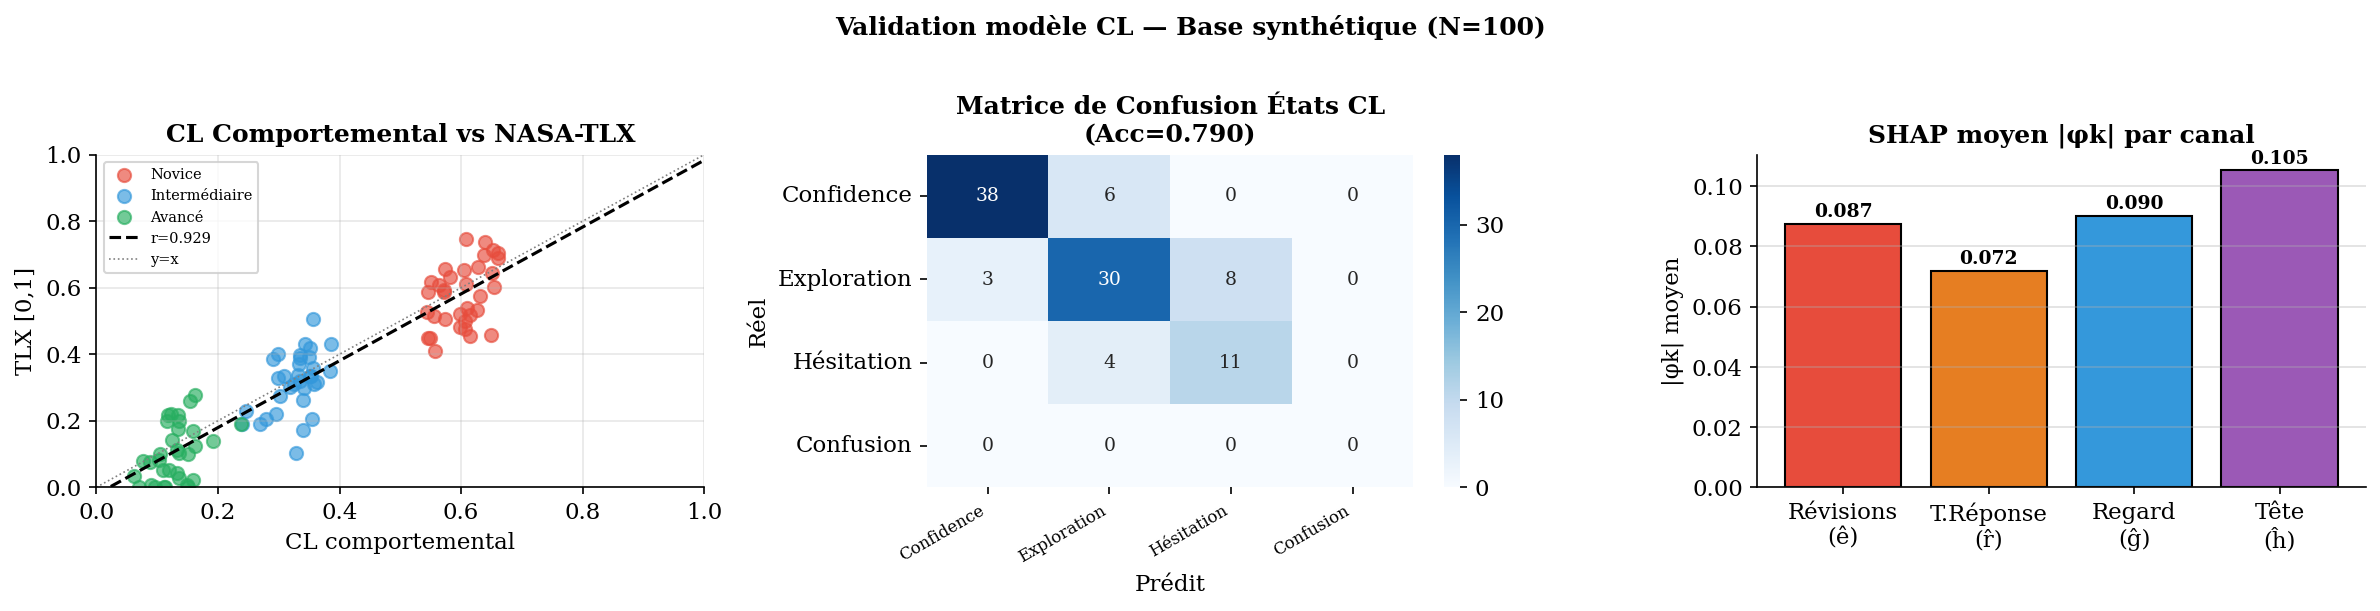


✅ Modèle CL validé — métriques enregistrées dans CL_METRICS_SYN


In [11]:
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.metrics import mean_absolute_error, mean_squared_error, confusion_matrix

cl_beh_vals = np.array([estimate_cl(l['mean_head_movement'],l['mean_gaze_disp'],
                                     l['mean_interaction_ev'],l['mean_response_time'])[0]
                         for l in SYN_LEARNERS])
tlx_vals_syn = np.array([l['tlx_label'] for l in SYN_LEARNERS])

r_syn, p_syn = stats.pearsonr(cl_beh_vals, tlx_vals_syn)
mae_syn      = mean_absolute_error(tlx_vals_syn, cl_beh_vals)
rmse_syn     = np.sqrt(mean_squared_error(tlx_vals_syn, cl_beh_vals))

print('🧠 Validation modèle CL comportemental (N=100 synthétiques)')
print('='*55)
print(f'  Pearson r   = {r_syn:.4f}  (seuil \u2265 0.65 : {"\u2705" if r_syn>=0.65 else "\u26a0\ufe0f"})')
print(f'  p-value     = {p_syn:.2e}')
print(f'  MAE         = {mae_syn:.4f}')
print(f'  RMSE        = {rmse_syn:.4f}')

print('\n  Pearson r par groupe :')
for g in POPULATION:
    idx = [i for i,l in enumerate(SYN_LEARNERS) if l['group']==g]
    r_g,_ = stats.pearsonr(cl_beh_vals[idx], tlx_vals_syn[idx])
    print(f'    {g:<18}: r={r_g:.4f}  {"\u2705" if r_g>=0.65 else "\u26a0\ufe0f"}')

true_states = [classify_cl(t)[0] for t in tlx_vals_syn]
pred_states = [classify_cl(c)[0] for c in cl_beh_vals]
state_acc   = np.mean([t==p for t,p in zip(true_states,pred_states)])
print(f'\n  Accuracy \u00e9tats CL : {state_acc:.4f}')

print('\n  SHAP moyen |\u03c6k| par groupe :')
shap_header = '    {:<18} {:>10} {:>10} {:>10} {:>10}'.format('Groupe','T\u00eate','Regard','Interact.','T.R\u00e9ponse')
print(shap_header)
for g in POPULATION:
    sub = [l for l in SYN_LEARNERS if l['group']==g]
    shaps = [compute_shap(l['mean_head_movement'],l['mean_gaze_disp'],
                          l['mean_interaction_ev'],l['mean_response_time']) for l in sub]
    means = {k: np.mean([abs(s[k]) for s in shaps]) for k in shaps[0]}
    print(f"    {g:<18} {means['head_movement']:>10.4f} {means['gaze_direction']:>10.4f} "          f"{means['interaction_events']:>10.4f} {means['response_time']:>10.4f}")

CL_METRICS_SYN = {
    'pearson_r':   round(r_syn,4), 'p_value': round(p_syn,4),
    'MAE':         round(mae_syn,4), 'RMSE': round(rmse_syn,4),
    'state_accuracy': round(state_acc,4),
}

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

ax = axes[0]
colors_grp = {'Novice':'#e74c3c','Interm\u00e9diaire':'#3498db','Avanc\u00e9':'#27ae60'}
for g in POPULATION:
    idx = [i for i,l in enumerate(SYN_LEARNERS) if l['group']==g]
    ax.scatter(cl_beh_vals[idx], tlx_vals_syn[idx], c=colors_grp[g], label=g, alpha=0.65, s=40)
xs  = np.linspace(0,1,100)
m,b = np.polyfit(cl_beh_vals, tlx_vals_syn, 1)
ax.plot(xs, m*xs+b, 'k--', lw=1.5, label=f'r={r_syn:.3f}')
ax.plot([0,1],[0,1],'gray',lw=0.8,ls=':',label='y=x')
ax.set_title('CL Comportemental vs NASA-TLX', fontweight='bold')
ax.set_xlabel('CL comportemental'); ax.set_ylabel('TLX [0,1]')
ax.legend(fontsize=7); ax.set_xlim(0,1); ax.set_ylim(0,1); ax.grid(alpha=.3)

state_labels = ['Confidence','Exploration','H\u00e9sitation','Confusion']
cm  = confusion_matrix(true_states, pred_states, labels=state_labels)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[1],
            xticklabels=state_labels, yticklabels=state_labels, annot_kws={'size':9})
axes[1].set_title(f'Matrice de Confusion \u00c9tats CL\n(Acc={state_acc:.3f})', fontweight='bold')
axes[1].set_xlabel('Pr\u00e9dit'); axes[1].set_ylabel('R\u00e9el')
plt.setp(axes[1].xaxis.get_majorticklabels(), rotation=30, ha='right', fontsize=8)

shap_all = [compute_shap(l['mean_head_movement'],l['mean_gaze_disp'],
                          l['mean_interaction_ev'],l['mean_response_time']) for l in SYN_LEARNERS]
shap_means_g = {k: float(np.mean([abs(s[k]) for s in shap_all])) for k in shap_all[0]}
labels_shap  = ['R\u00e9visions\n(\u00ea)','T.R\u00e9ponse\n(r\u0302)','Regard\n(\u011d)','T\u00eate\n(\u0125)']
vals_shap    = [shap_means_g['interaction_events'], shap_means_g['response_time'],
                shap_means_g['gaze_direction'],     shap_means_g['head_movement']]
bars = axes[2].bar(labels_shap, vals_shap,
                   color=['#e74c3c','#e67e22','#3498db','#9b59b6'], edgecolor='black')
for bar, v in zip(bars, vals_shap):
    axes[2].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.001, f'{v:.3f}',
                 ha='center', va='bottom', fontsize=9, fontweight='bold')
axes[2].set_title('SHAP moyen |\u03c6k| par canal', fontweight='bold')
axes[2].set_ylabel('|\u03c6k| moyen'); axes[2].grid(axis='y', alpha=.4)

plt.suptitle('Validation mod\u00e8le CL \u2014 Base synth\u00e9tique (N=100)', fontsize=12, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('cl_validation_syn.png', dpi=150, bbox_inches='tight')
plt.show()
print('\n\u2705 Mod\u00e8le CL valid\u00e9 \u2014 m\u00e9triques enregistr\u00e9es dans CL_METRICS_SYN')

## 🤝 Partie 2 — Fusion DB + Pipeline AILS Complet

In [12]:
import shap
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.preprocessing import MinMaxScaler

FEATURE_NAMES = ['score_norm', 'cl_value', 'tendance', 'erreur_norm']

FEATURE_TO_CHANNEL = {
    'score_norm':  'head_movement',
    'tendance':    'gaze_direction',
    'erreur_norm': 'interaction_events',
    'cl_value':    'response_time',
}

def _build_shap_dataset(learner_db: list):
    """
    Construit X, y depuis l'historique de tous les apprenants.
    Features : [score_norm, cl_value, tendance, erreur_norm]
    Target   : gain de score sur l'exercice suivant (Δ S)
    """
    X_rows, y_rows = [], []
    for l in learner_db:
        history = l.get('exercise_history', [])
        if len(history) < 3:
            continue
        for i in range(2, len(history)):
            window = history[max(0, i - 3):i]
            scores = [r.get('score', 0.5) for r in window]
            score_norm   = float(scores[-1])
            tendance     = float(scores[-1] - scores[0])
            cl_value     = float(l.get('mean_cl', 0.5))
            err_counts   = {}
            for r in window:
                et = r.get('error_type', 'general')
                err_counts[et] = err_counts.get(et, 0) + 1
            erreur_norm = (max(err_counts.values()) if err_counts else 0) / 5.0
            X_rows.append([score_norm, cl_value, tendance, erreur_norm])
            next_score = float(history[i].get('score', score_norm))
            y_rows.append(next_score - score_norm)
    return np.array(X_rows), np.array(y_rows)

def _train_shap_model(learner_db: list):
    """
    Entraîne GradientBoostingRegressor et initialise KernelExplainer.
    Retourne : (model, scaler, explainer) ou (None, None, None) si échec.
    """
    X, y = _build_shap_dataset(learner_db)
    if len(X) < 10:

        print(f'SHAP : données insuffisantes (N={len(X)}) — fallback heuristique')
        return None, None, None

    scaler   = MinMaxScaler()
    X_scaled = scaler.fit_transform(X)

    model = GradientBoostingRegressor(
        n_estimators=100,
        max_depth=3,
        learning_rate=0.1,
        random_state=42,
    )
    model.fit(X_scaled, y)
    r2 = model.score(X_scaled, y)

    background  = shap.kmeans(X_scaled, min(20, len(X_scaled)))
    explainer   = shap.KernelExplainer(model.predict, background)

    print(f'✅ SHAP KernelExplainer initialisé | N={len(X)} | R²={r2:.3f}')
    return model, scaler, explainer

def _heuristic_phi(score_norm: float, cl_value: float,
                   tendance: float, erreur_norm: float) -> dict:
    return {
        'head_movement':      round(ALPHA * abs(1 - score_norm), 4),
        'gaze_direction':     round(BETA  * max(0.0, -tendance + 0.1), 4),
        'interaction_events': round(GAMMA * erreur_norm, 4),
        'response_time':      round(DELTA * cl_value, 4),
    }


In [13]:

def safe_get(row, col, default=0.5):
    if col and col in row.index and not pd.isna(row[col]):
        return float(row[col])
    return default

def mean_col(df, col, default=0.5):
    if col and not df.empty and col in df.columns:
        vals = pd.to_numeric(df[col], errors='coerce').dropna()
        return float(vals.mean()) if len(vals) > 0 else default
    return default

def build_real_learner_db():
    """Construit la liste des apprenants depuis les vraies données Google Sheets."""
    DB = []
    id_sources = []
    if not df_form1_clean.empty and 'email_address' in df_form1_clean.columns:
        id_sources = df_form1_clean['email_address'].dropna().unique().tolist()
    elif not df_profile_clean.empty and COL_LEARNER_ID:
        id_sources = df_profile_clean[COL_LEARNER_ID].dropna().unique().tolist()
    elif not df_cl_clean.empty and COL_CL_LEARNER:
        id_sources = df_cl_clean[COL_CL_LEARNER].dropna().unique().tolist()
    elif not df_form2_clean.empty and COL_F2_LEARNER:
        id_sources = df_form2_clean[COL_F2_LEARNER].dropna().unique().tolist()

    for lid in id_sources:
        lid_key = int(lid) if str(lid).replace('.','',1).isdigit() else lid
        form1_row = pd.Series(dtype=object)
        if not df_form1_clean.empty and 'email_address' in df_form1_clean.columns:
            match_f1 = df_form1_clean[df_form1_clean['email_address'] == lid_key]
            if not match_f1.empty: form1_row = match_f1.iloc[0]
        prior      = safe_get(form1_row,'i_already_have_prior_knowledge_in_this_topic', 0.5)
        confidence = safe_get(form1_row,'i_am_confident_in_my_ability_to_solve_exercises_in_this_subject', 0.5)
        motivation = safe_get(form1_row,'i_feel_motivated_when_solving_exercises_in_this_subject', 0.5)
        group      = str(form1_row.get('current_educational_level','Réel'))

        if prior > 1.0: prior = (prior - 1) / 4.
        if confidence > 1.0: confidence = (confidence - 1) / 4.
        if motivation > 1.0: motivation = (motivation - 1) / 4.

        cl_rows = pd.DataFrame()
        if not df_cl_clean.empty and COL_CL_LEARNER:
            cl_rows = df_cl_clean[df_cl_clean[COL_CL_LEARNER] == lid_key]

        mean_h = mean_col(cl_rows, COL_HEAD_NORM)
        mean_g = mean_col(cl_rows, COL_GAZE_NORM)
        mean_e = mean_col(cl_rows, COL_INTERACT_NORM)
        mean_r = mean_col(cl_rows, COL_RT_NORM)

        if cl_rows.empty and not df_form2_clean.empty and 'tlx_score_norm' in df_form2_clean.columns and COL_F2_LEARNER:
            f2_rows = df_form2_clean[df_form2_clean[COL_F2_LEARNER] == lid_key]
            mean_cl = mean_col(f2_rows, 'tlx_score_norm', 0.5)
        else:
            mean_cl = estimate_cl(mean_h, mean_g, mean_e, mean_r)

        mastered_modules = []
        if prior >= 0.7: mastered_modules.extend(['M01','M02','M03'])
        elif prior >= 0.4: mastered_modules.extend(['M01','M02'])
        elif prior > 0.0: mastered_modules.append('M01')
        mastered_modules = sorted(list(set(mastered_modules)))

        module_progress = {}
        if not cl_rows.empty and COL_CL_MODULE and COL_SCORE_NORM:
            for mod_id, mod_rows in cl_rows.groupby(COL_CL_MODULE):
                mid = str(mod_id).upper()
                if mid not in MODULES: continue
                scores = pd.to_numeric(mod_rows[COL_SCORE_NORM], errors='coerce').dropna()
                if len(scores) == 0: continue
                cls_m = mod_rows.apply(lambda r: estimate_cl(
                    float(r.get(COL_HEAD_NORM, 0.5)) if COL_HEAD_NORM else 0.5,
                    float(r.get(COL_GAZE_NORM, 0.5)) if COL_GAZE_NORM else 0.5,
                    float(r.get(COL_INTERACT_NORM, 0.5)) if COL_INTERACT_NORM else 0.5,
                    float(r.get(COL_RT_NORM, 0.5)) if COL_RT_NORM else 0.5), axis=1)
                last_s = scores.tolist()[-N_WINDOW:]
                last_c = cls_m.tolist()[-N_WINDOW:]
                is_mastered = (len(last_s)>=N_WINDOW and np.mean(last_s)>=MODULES[mid]['theta']
                               and np.mean(last_c)<=0.50 and last_s[-1]>=last_s[0])
                module_progress[mid] = {
                    'score_pre': round(float(scores.iloc[0]),3),
                    'score_post': round(float(scores.iloc[-1]),3),
                    'score_current': round(float(scores.mean()),3),
                    'mean_cl': round(float(cls_m.mean()),3),
                    'is_mastered': is_mastered, 'nb_exercises': len(mod_rows),
                    'dominant_error': str(mod_rows[COL_ERROR_TYPE].mode().iloc[0]) if COL_ERROR_TYPE and not mod_rows.empty else 'unknown'
                }
                if is_mastered and mid not in mastered_modules:
                    mastered_modules.append(mid)
            mastered_modules = sorted(list(set(mastered_modules)))

        mean_score = (np.mean([v['score_current'] for v in module_progress.values()])
                      if module_progress else round(prior, 3))
        DB.append({
            'id': lid_key, 'username': f'learner_{lid_key}', 'group': group,
            'is_synthetic': False,
            'prior_knowledge': round(prior,4), 'confidence': round(confidence,4),
            'motivation': round(motivation,4),
            'mean_head_movement': mean_h, 'mean_gaze_disp': mean_g,
            'mean_interaction_ev': mean_e, 'mean_response_time': mean_r,
            'mean_score': round(mean_score,3), 'mean_cl': round(mean_cl,4),
            'module_progress': module_progress, 'mastered_modules': mastered_modules,
        })
    return DB

REAL_LEARNERS = build_real_learner_db()
print(f'✅ Apprenants réels : {len(REAL_LEARNERS)}')

DB_LEARNERS = SYN_LEARNERS + REAL_LEARNERS
print(f'✅ DB fusionnée   : {len(DB_LEARNERS)} apprenants ({len(SYN_LEARNERS)} syn + {len(REAL_LEARNERS)} réels)')
print('   → Le CF dispose maintenant d\'une base dense pour des recommandations précises.')

SHAP_MODEL, SHAP_SCALER, SHAP_EXPLAINER = _train_shap_model(DB_LEARNERS)
for l in REAL_LEARNERS:
    cl_state,_ = classify_cl(l['mean_cl'])
    print(f"  {l['id']} | CL={l['mean_cl']:.3f} [{cl_state}] | Maîtrisés={l['mastered_modules']} | Score={l['mean_score']:.3f}")

✅ Apprenants réels : 34
✅ DB fusionnée   : 134 apprenants (100 syn + 34 réels)
   → Le CF dispose maintenant d'une base dense pour des recommandations précises.
SHAP : données insuffisantes (N=0) — fallback heuristique
  sabrinewariech@gmail.com | CL=0.642 [Hésitation] | Maîtrisés=['M01', 'M02', 'M03'] | Score=0.750
  mbarekayoub27@gmail.com | CL=0.500 [Exploration] | Maîtrisés=['M01', 'M02', 'M03'] | Score=0.750
  mrgooba03@gmail.com | CL=0.500 [Exploration] | Maîtrisés=['M01', 'M02', 'M03'] | Score=0.750
  aminefkili05@gmail.com | CL=0.594 [Exploration] | Maîtrisés=['M01', 'M02', 'M03'] | Score=0.750
  hadhemimahjoub@gmail.com | CL=0.969 [Confusion] | Maîtrisés=['M01', 'M02', 'M03'] | Score=0.750
  shaady.nexus@gmail.com | CL=0.500 [Exploration] | Maîtrisés=['M01'] | Score=0.250
  methnihamza61@gmail.com | CL=0.500 [Exploration] | Maîtrisés=['M01', 'M02'] | Score=0.500
  ilyesbenharzallah4@gmail.com | CL=0.406 [Exploration] | Maîtrisés=['M01', 'M02', 'M03'] | Score=0.750
  benhamouda

In [14]:

print('ℹ️ Cellule 19 : doublon de la Cellule 17 neutralise (fonctions SHAP deja definies plus haut).')


In [15]:
import requests, json

import re

def _parse_mistral_json(raw: str):
    """Parser robuste : gère ```json, control chars, JSON partiel."""
    if not raw:
        return None

    cleaned = re.sub(r'```json\s*', '', raw)
    cleaned = re.sub(r'```\s*', '', cleaned)
    cleaned = cleaned.strip()

    m = re.search(r'\{.*\}', cleaned, re.DOTALL)
    if not m:
        return None
    json_str = m.group()

    def fix_control_chars(s):
        result = []
        in_string = False
        escape = False
        for ch in s:
            if escape:
                result.append(ch)
                escape = False
                continue
            if ch == '\\':
                result.append(ch)
                escape = True
                continue
            if ch == '"':
                in_string = not in_string
                result.append(ch)
                continue
            if in_string and ch == '\n':
                result.append('\\n')
                continue
            if in_string and ch == '\r':
                result.append('\\r')
                continue
            if in_string and ch == '\t':
                result.append('\\t')
                continue
            result.append(ch)
        return ''.join(result)

    json_str = fix_control_chars(json_str)

    try:
        return json.loads(json_str)
    except Exception as e:
        print(f"    ⚠️ Parsing échoué après nettoyage : {e}")
        print(f"    Aperçu : {json_str[:300]}")
        return None

def call_mistral(system_prompt, user_prompt, max_tokens=350):

    FALLBACK = (
        '1. PRÉREQUIS : Les modules maîtrisés vous préparent à ce contenu.\n'
        '2. PAIRS SIMILAIRES : Des apprenants comparables ont bien progressé ici.\n'
        '3. DISPONIBILITÉ COGNITIVE : Votre charge cognitive est favorable.'
    )

    if not USE_LLM:
        return FALLBACK

    headers = {
        'Authorization': f'Bearer {MISTRAL_API_KEY}',
        'Content-Type': 'application/json'
    }
    payload = {
        'model': MISTRAL_MODEL,
        'max_tokens': max_tokens,
        'temperature': 0.8,
        'messages': [
            {'role': 'system', 'content': system_prompt},
            {'role': 'user',   'content': user_prompt}
        ]
    }

    for attempt in range(3):
        try:
            r = requests.post(
                'https://api.mistral.ai/v1/chat/completions',
                headers=headers, json=payload, timeout=30
            )
            if r.status_code == 429:
                wait = (attempt + 1) * 15
                print(f'⚠️ Mistral 429 — attente {wait}s (tentative {attempt+1}/3)')
                time.sleep(wait)
                continue
            r.raise_for_status()
            return r.json()['choices'][0]['message']['content'].strip()

        except Exception as ex:
            print(f'⚠️ Mistral erreur tentative {attempt+1}: {ex}')
            if attempt < 2:
                time.sleep(10)

    print('❌ Mistral indisponible — fallback activé')
    return FALLBACK

INTER_SYS = '''
Tu es un tuteur pédagogique IA pour lycéens tunisiens (Bac Informatique).
Justifie la recommandation du prochain module en 3 parties numérotées :
1. PRÉREQUIS : modules déjà maîtrisés qui préparent ce module
2. PAIRS SIMILAIRES : progression mesurée d'apprenants similaires
3. DISPONIBILITÉ COGNITIVE : état cognitif actuel et préparation
Réponds en français, 4-6 phrases, encourageant et précis.
'''

SHAP_LABELS = {
    'head_movement':      'mouvements de tête (ĥ)',
    'gaze_direction':     'direction du regard (ĝ)',
    'interaction_events': 'révisions de réponses (ê)',
    'response_time':      'temps de réponse (r̂)',
}

SHAP_PEDAGOGICAL_MESSAGES = {
    'head_movement': {
        'message':  "Cet exercice cible un concept non encore maîtrisé.",
        'target':   "Niveau de connaissance",
        'channel':  'ĥ',
        'audience': "Apprenant + Enseignant",
    },
    'gaze_direction': {
        'message':  "Tes résultats récents suggèrent un exercice de consolidation.",
        'target':   "Tendance de progression",
        'channel':  'ĝ',
        'audience': "Apprenant + Enseignant",
    },
    'interaction_events': {
        'message':  "Cet exercice se concentre sur ton type d'erreur le plus fréquent.",
        'target':   "Type d'erreur",
        'channel':  'ê',
        'audience': "Apprenant + Enseignant",
    },
    'response_time': {
        'message':  "Un exercice plus simple est proposé pour reprendre confiance.",
        'target':   "Hésitation / État émotionnel",
        'channel':  'r̂',
        'audience': "Apprenant + Enseignant",
    },
}

XAI_DEVELOPER_LOG = []

def _log_xai_event(learner_id, module_id, shap_values, dominant_channel,
                   cl_value, cl_state, pedagogical_msg):
    from datetime import datetime
    XAI_DEVELOPER_LOG.append({
        'timestamp':        datetime.now().isoformat(),
        'learner_id':       learner_id,
        'module_id':        module_id,
        'shap_vector':      shap_values,
        'dominant_channel': dominant_channel,
        'dominant_phi':     shap_values[dominant_channel],
        'cl_value':         round(cl_value, 4),
        'cl_state':         cl_state,
        'pedagogical_msg':  pedagogical_msg,
        'target':           SHAP_PEDAGOGICAL_MESSAGES[dominant_channel]['target'],
    })

def explain_recommendation(learner, result, current_cl, cl_state):
    rec    = MODULES[result['recommended_module']]
    prompt = f'''Apprenant : {learner['username']} (groupe {learner.get('group','?')})
Module recommandé : {result['recommended_module']} — {result['recommended_title']} (difficulté {rec['difficulty']}/5)
Prérequis : {', '.join(rec['prerequisites']) or 'Aucun'}
Modules maîtrisés : {', '.join(result['mastered_modules'])}
Pairs analysés : {len(result['top_peers'])}
Score compatibilité : {result['compat_score']:.2f}/1.0
Vote CF : {result['vote_cf']:.4f}
Score final : {result['final_score']:.4f}
État cognitif : {cl_state} (CL={current_cl:.3f})
'''
    return call_mistral(INTER_SYS, prompt, max_tokens=300)

def translate_shap_to_pedagogy(shap_values, learner_id='?', module_id='?',
                                cl_value=0.5, cl_state='Exploration',
                                verbose=True):

    dominant_channel = max(shap_values, key=lambda k: abs(shap_values[k]))
    dominant_phi     = shap_values[dominant_channel]

    entry          = SHAP_PEDAGOGICAL_MESSAGES[dominant_channel]
    channel_symbol = entry['channel']
    learner_msg    = entry['message']
    teacher_msg    = (
        f"[Enseignant] Canal dominant : {SHAP_LABELS[dominant_channel]} "
        f"| φ={dominant_phi:+.4f} | CL={cl_value:.3f} ({cl_state}) "
        f"| Cible : {entry['target']}"
    )

    _log_xai_event(
        learner_id=learner_id, module_id=module_id,
        shap_values=shap_values, dominant_channel=dominant_channel,
        cl_value=cl_value, cl_state=cl_state, pedagogical_msg=learner_msg,
    )

    if verbose:
        print(f"\n    ┌─ 🔍 XAI — Traduction Pédagogique ({'─'*28})")
        print(f"    │  Canal dominant : {SHAP_LABELS[dominant_channel]}  ({channel_symbol})")
        print(f"    │  φ_{channel_symbol} = {dominant_phi:+.4f}  │  Vecteur SHAP complet :")
        for k, v in shap_values.items():
            marker = ' ◄ dominant' if k == dominant_channel else ''
            print(f"    │    {SHAP_LABELS[k]:<35} φ={v:+.4f}{marker}")
        print(f"    │")
        print(f"    │  💬 Message Apprenant (VR) : « {learner_msg} »")
        print(f"    │  👩‍🏫 Message Enseignant     : {teacher_msg}")
        print(f"    └{'─'*50}")

    return {
        'dominant_channel': dominant_channel,
        'dominant_phi':     dominant_phi,
        'channel_symbol':   channel_symbol,
        'learner_message':  learner_msg,
        'teacher_message':  teacher_msg,
        'target':           entry['target'],
        'shap_vector':      shap_values,
    }

print('💬 Pipeline complet CL → CF → XAI (apprenants réels)')
print('='*65)
for learner in REAL_LEARNERS[:3]:
    h, g, e, r = (learner['mean_head_movement'], learner['mean_gaze_disp'],
                  learner['mean_interaction_ev'], learner['mean_response_time'])
    cl                  = estimate_cl(h, g, e, r)[0]
    shap                = compute_shap(h, g, e, r)
    cl_state, cl_action = classify_cl(cl)
    result              = recommend_next_module(learner, DB_LEARNERS, cl)

    print(f"\n{'═'*65}")
    print(f" 👤 {learner['username']} | Groupe : {learner.get('group','?')}")
    print(f" 🧠 CL = {cl:.4f} → {cl_state} | Action : {cl_action}")

    if not result:
        print(f" 🎓 Curriculum terminé !")
        continue

    xai = translate_shap_to_pedagogy(
        shap_values = shap,
        learner_id  = learner['username'],
        module_id   = result['recommended_module'],
        cl_value    = cl,
        cl_state    = cl_state,
        verbose     = True,
    )

    print(f"\n ✅ Recommandation : {result['recommended_module']} — {result['recommended_title']}")
    print(f"    CF={result['vote_cf']:.4f} | Compat={result['compat_score']:.4f} | Score={result['final_score']:.4f}")

    expl = explain_recommendation(learner, result, cl, cl_state)
    print(f" 💬 XAI Mistral :\n{expl}")

print(f"\n{'═'*65}")
print(f" 📊 Dashboard Développeur — Log XAI ({len(XAI_DEVELOPER_LOG)} événements enregistrés)")
print(f"{'─'*65}")
for entry in XAI_DEVELOPER_LOG:
    print(f"  [{entry['timestamp'][11:19]}] {entry['learner_id']:<20} "
          f"canal={SHAP_LABELS[entry['dominant_channel']]:<35} "
          f"φ={entry['dominant_phi']:+.4f} | CL={entry['cl_value']:.3f} [{entry['cl_state']}]")
print(f"\n  💡 Ce log alimentera les graphiques Waterfall et l'évolution")
print(f"     temporelle des vecteurs SHAP dans le Dashboard Développeur.")

💬 Pipeline complet CL → CF → XAI (apprenants réels)

═════════════════════════════════════════════════════════════════
 👤 learner_sabrinewariech@gmail.com | Groupe : 4.0
 🧠 CL = 0.5000 → Exploration | Action : 👍 Bonne progression ! Exercice standard.

    ┌─ 🔍 XAI — Traduction Pédagogique (────────────────────────────)
    │  Canal dominant : révisions de réponses (ê)  (ê)
    │  φ_ê = +0.1500  │  Vecteur SHAP complet :
    │    mouvements de tête (ĥ)              φ=+0.1250
    │    direction du regard (ĝ)             φ=+0.1250
    │    révisions de réponses (ê)           φ=+0.1500 ◄ dominant
    │    temps de réponse (r̂)               φ=+0.1000
    │
    │  💬 Message Apprenant (VR) : « Cet exercice se concentre sur ton type d'erreur le plus fréquent. »
    │  👩‍🏫 Message Enseignant     : [Enseignant] Canal dominant : révisions de réponses (ê) | φ=+0.1500 | CL=0.500 (Exploration) | Cible : Type d'erreur
    └──────────────────────────────────────────────────

 ✅ Recommandation : M05 —

## 🔴 Partie 3 — Surveillance Temps Réel

---
## 🧪 BLOC D'EXPÉRIMENTATION RÉELLE — Cellules 21 → 24
> **Objectif :** Tester le système AILS complet sur de vrais élèves de Baccalauréat.
> **Flux :** Form 1 (profil) → RAG + Mistral (génération exercice) → Affichage exercice → Form 2 (auto-éval CL + score) → Recommandation exercice suivant → (boucle jusqu'à maîtrise) → CF inter-module
>
> ⚠️ **Prérequis :** Cellules 1 → 16 exécutées · `bac.rar` présent sur Google Drive · Liens des deux formulaires Google configurés ci-dessous.

In [16]:

import json, re

BAC_KNOWLEDGE_BASE = [
  {
    "id": "bac2024c_ex1",
    "source": "Bac 2024 Session Contrôle",
    "titre": "Exercice 1 (3 points)",
    "points": 3,
    "modules": ["M03"],
    "concepts": ["chaines", "recursif", "iteratif", "sous_chaine"],
    "type_algo": "fonction",
    "contexte": (
        "Soit l'algorithme de la fonction 'Inconnue' avec ch1 et ch2 deux chaînes "
        "non vides formées uniquement de lettres minuscules distinctes."
    ),
    "code_fourni": (
        "Fonction Inconnue(ch1, ch2 : Chaîne de caractères) : Chaîne de caractères\n"
        "DEBUT\n"
        "  Si ch1 = \"\" Alors\n"
        "    Retourner \"\"\n"
        "  Sinon Si Pos(ch1[0], ch2) = -1 Alors\n"
        "    Retourner Inconnue(Sous_Chaine(ch1, 1, Long(ch1)), ch2)\n"
        "  Sinon\n"
        "    Retourner ch1[0] + Inconnue(Sous_Chaine(ch1, 1, Long(ch1)), ch2)\n"
        "  FinSi\n"
        "FIN"
    ),
    "questions": [
      "1) Donner une trace d'exécution manuelle pour :\n"
      "   - Cas1 : ch1=\"bac\", ch2=\"courage\" → résultat = \"ac\"\n"
      "   - Cas2 : ch1=\"image\", ch2=\"matrice\" → résultat = \"imae\"",
      "2) En déduire le rôle de la fonction Inconnue.",
      "3) Écrire un algorithme itératif de la fonction Inconnue donnant le même résultat."
    ],
    "bareme": {"Q1": 1.5, "Q2": 0.5, "Q3": 1.0},
  },
  {
    "id": "bac2024c_ex2",
    "source": "Bac 2024 Session Contrôle",
    "titre": "Exercice 2 (3 points)",
    "points": 3,
    "modules": ["M05", "M06"],
    "concepts": ["calcul", "approximation", "boucle", "valeur_approchee"],
    "type_algo": "fonction",
    "contexte": (
        "Pour obtenir une valeur approchée de ln(2), on calcule la somme des n premiers "
        "termes de la suite : ln(2) = 1 - 1/2 + 1/3 - ... + (-1)^(n-1)/n"
    ),
    "code_fourni": None,
    "questions": [
      "Écrire un algorithme d'une fonction CalculLn2(epsilon) qui retourne une valeur "
      "approchée de ln(2). Le calcul s'arrête lorsque la valeur absolue du dernier "
      "terme ajouté est inférieure ou égale à epsilon."
    ],
    "bareme": {"Q1": 3.0},
  },
  {
    "id": "bac2024c_ex3",
    "source": "Bac 2024 Session Contrôle",
    "titre": "Exercice 3 (6 points)",
    "points": 6,
    "modules": ["M01", "M03"],
    "concepts": ["fichiers", "tableaux", "enregistrements", "recursif", "calcul"],
    "type_algo": "procédure",
    "contexte": (
        "Le coefficient binomial Cb(n,k) : Cb(n,k)=0 si n<k ; Cb(n,k)=1 si k=0 ou k=n ; "
        "Cb(n,k)=Cb(n-1,k-1)+Cb(n-1,k) sinon. "
        "On remplit un tableau T depuis un fichier 'Coeff.txt' contenant des couples (n,k). "
        "Chaque enregistrement a 3 champs : n, k (entiers), r (résultat entier)."
    ),
    "code_fourni": None,
    "questions": [
      "1) Déclarer un type pour le tableau T (max 50 couples) ainsi que tout type nécessaire.",
      "2) Écrire un algorithme d'une procédure Remplir(Ch, T) qui remplit le tableau T "
         "depuis le fichier (Ch = chemin physique du fichier)."
    ],
    "bareme": {"Q1": 2.0, "Q2": 4.0},
  },
  {
    "id": "bac2024c_ex4",
    "source": "Bac 2024 Session Contrôle",
    "titre": "Exercice 4 (8 points)",
    "points": 8,
    "modules": ["M01"],
    "concepts": ["tableaux", "matrices", "enregistrements", "binaire"],
    "type_algo": "procédure",
    "contexte": (
        "Dissimulation d'une image Img2 dans Img1. Deux matrices L×C de pixels (R,V,B entiers 0-255). "
        "Pour chaque pixel : convertir la couleur rouge en binaire 8 bits (bin1 et bin2), "
        "remplacer les 4 derniers bits de bin1 par les 4 premiers bits de bin2, "
        "puis reconvertir en décimal."
    ),
    "code_fourni": None,
    "questions": [
      "1) Déclarer un type Pixel (3 champs R,V,B) et un type MatriceImage.",
      "2) Écrire une fonction BinEnDec(B : Tableau[0..7] de 0..1) : Entier.",
      "3) Écrire une fonction DecEnBin(N : Entier) : Tableau[0..7] de 0..1.",
      "4) Écrire une procédure Dissimuler(Img1, Img2 : MatriceImage; L, C : Entier)."
    ],
    "bareme": {"Q1": 1.0, "Q2": 1.5, "Q3": 1.5, "Q4": 4.0},
  },
  {
    "id": "bac2025p_ex1",
    "source": "Bac 2025 Session Principale",
    "titre": "Exercice 1 (3 points)",
    "points": 3,
    "modules": ["M03", "M04"],
    "concepts": ["chaines", "iteratif", "recursif", "conversion_base", "Chr"],
    "type_algo": "fonction",
    "contexte": "Conversion d'un entier N vers la base B. NB : Chr(65)='A', Chr(97)='a', Chr(48)='0'.",
    "code_fourni": (
        "Fonction Inconnue (N, B : Entier) : Chaîne de caractères\n"
        "DEBUT\n"
        "  Si N=0 Alors\n"
        "    Retourner \"0\"\n"
        "  Sinon\n"
        "    CH ← \"\"\n"
        "    Répéter\n"
        "      K ← N Mod B + 48 + ((N Mod B) Div 10) * 7\n"
        "      CH ← Chr(K) + CH\n"
        "      N ← N Div B\n"
        "    Jusqu'à N = 0\n"
        "    Retourner CH\n"
        "  FinSi\n"
        "FIN"
    ),
    "questions": [
      "1a) Valider (V/F) : Inconnue(5, 2) retourne 100 / 31 / 101",
      "1b) Valider (V/F) : Inconnue(31, 16) retourne 1F / 31 / F1",
      "1c) La fonction Inconnue permet de : convertir hexadécimal→décimal / "
          "décimal→base donnée / base donnée→base 10",
      "2) Proposer un algorithme récursif pour la fonction Inconnue."
    ],
    "bareme": {"Q1a": 0.75, "Q1b": 0.75, "Q1c": 0.5, "Q2": 1.0},
  },
  {
    "id": "bac2025p_ex2",
    "source": "Bac 2025 Session Principale",
    "titre": "Exercice 2 (3,5 points)",
    "points": 3.5,
    "modules": ["M04", "M05"],
    "concepts": ["calcul", "suites", "tableaux", "enregistrements", "boucle"],
    "type_algo": "fonction",
    "contexte": (
        "Nombre de Keith : entier K de d chiffres, suite U où U_1..U_d sont les chiffres de K "
        "et U_n = U_{n-1}+...+U_{n-d} pour n>d. K est un nombre de Keith si K apparaît dans "
        "la suite. Ex: Verif(197)=8, Verif(24)=-1."
    ),
    "code_fourni": None,
    "questions": [
      "1) Écrire une fonction Verif(K) qui retourne n si U_n=K ou -1 sinon.",
      "2) En utilisant Verif, écrire un programme qui remplit un tableau NK "
         "d'enregistrements (Nbre:entier, Num:entier) par tous les nombres de Keith < 100000."
    ],
    "bareme": {"Q1": 2.0, "Q2": 1.5},
  },
  {
    "id": "bac2025c_ex2",
    "source": "Bac 2025 Session Contrôle",
    "titre": "Exercice 2 (3,5 points)",
    "points": 3.5,
    "modules": ["M04", "M05"],
    "concepts": ["calcul", "suites", "tableaux", "enregistrements", "boucle"],
    "type_algo": "fonction",
    "contexte": (
        "Soit K un entier de d chiffres (d≥2) ayant la forme C1C2...Cd. Suite U telle que "
        "les d premiers termes sont les chiffres de K et U_n = U_{n-1}+...+U_{n-d} pour n>d. "
        "K est un nombre de Keith si un terme de U est égal à K."
    ),
    "code_fourni": None,
    "questions": [
      "1) Écrire une fonction Verif(K) qui retourne n (position dans U) si K est un "
         "nombre de Keith, -1 sinon.",
      "2) En utilisant Verif, écrire un algorithme d'un programme qui remplit un tableau NK "
         "d'enregistrements (Nbre, Num) par les nombres de Keith < 100000."
    ],
    "bareme": {"Q1": 2.0, "Q2": 1.5},
  },
]

print(f'✅ Knowledge Base chargée : {len(BAC_KNOWLEDGE_BASE)} exercices réels Bac')

MODULE_CONCEPTS_MAP = {
    'M01': ['fichiers', 'enregistrements', 'tableaux', 'matrices', 'binaire'],
    'M02': ['tri', 'tableaux', 'recherche', 'boucle'],
    'M03': ['recursif', 'chaines', 'sous_chaine', 'Chr'],
    'M04': ['suites', 'recursif', 'boucle', 'calcul', 'enregistrements'],
    'M05': ['calcul', 'approximation', 'valeur_approchee', 'arithmetique'],
    'M06': ['approximation', 'optimisation', 'calcul', 'boucle'],
}

def retrieve_fewshots(module_id: str, error_type: str = 'general',
                      n: int = 2, exclude_ids: list = None) -> list:
    """
    Retourne jusqu'à `n` exercices de la KB les plus pertinents.

    Scoring :
      +3  si l'exercice est tagué pour ce module exact
      +2  si concept du module dans l'exercice
      +1  si error_type correspond aux concepts
      −∞  si id dans exclude_ids
    """
    exclude_ids = exclude_ids or []
    target_concepts = set(MODULE_CONCEPTS_MAP.get(module_id, []))

    if not target_concepts:
        mid_lower = module_id.lower()
        for k, vals in MODULE_CONCEPTS_MAP.items():
            if any(v in mid_lower for v in vals):
                target_concepts.update(vals)

    error_bonus = {
        'comprehension': {'recursif', 'iteratif'},
        'logique':       {'boucle', 'recursif', 'calcul'},
        'syntaxe':       {'chaines', 'iteratif'},
        'calcul':        {'calcul', 'approximation', 'suites'},
        'general':       set(),
    }.get(error_type, set())

    scored = []
    for ex in BAC_KNOWLEDGE_BASE:
        if ex['id'] in exclude_ids:
            continue
        ex_concepts = set(ex.get('concepts', []))
        score  = 10 * (module_id in ex.get('modules', []))
        score += 3  * len(target_concepts & ex_concepts)
        score += 1  * len(error_bonus & ex_concepts)
        scored.append((score, ex))

    scored.sort(key=lambda x: x[0], reverse=True)
    results = [ex for score, ex in scored if score > 0][:n]
    if len(results) < n:
        neutral = [ex for score, ex in scored if score == 0]
        results += neutral[:n - len(results)]
    return results[:n]

def format_fewshot_example(ex: dict) -> str:
    """Formate un exercice KB → bloc texte pour injection dans le prompt."""
    lines = [
        f"=== EXEMPLE OFFICIEL BAC — {ex['source']} ===",
        f"Titre : {ex['titre']}",
        f"Contexte : {ex['contexte']}",
    ]
    if ex.get('code_fourni'):
        lines.append(f"\nAlgorithme fourni :\n{ex['code_fourni']}")
    lines.append("\nTravail demandé :")
    for q in ex['questions']:
        lines.append(f"  • {q}")
    total = sum(ex['bareme'].values())
    lines.append(f"\n[Barème : {ex['bareme']} — Total : {total} pts]")
    lines.append("=== FIN EXEMPLE ===\n")
    return '\n'.join(lines)

def build_rag_context(module_id: str, n_docs: int = 2, max_len: int = 1400) -> str:
    """
    Retourne une chaîne de texte prête à être injectée dans le prompt de Cellule 23.
    Récupère `n_docs` exercices réels du Bac pertinents pour `module_id`,
    formate chacun et tronque si nécessaire à `max_len` caractères.

    Usage dans Cellule 23 :
        rag_context = build_rag_context(module_id, n_docs=2, max_len=1400)
    """
    examples = retrieve_fewshots(module_id, error_type='general', n=n_docs)
    if not examples:
        return "(Aucun exemple disponible dans la base pour ce module)"

    blocks = [format_fewshot_example(ex) for ex in examples]
    full_text = '\n'.join(blocks)

    if len(full_text) > max_len:
        full_text = full_text[:max_len] + '\n... [tronqué]'
    return full_text

print('\n── Test build_rag_context ──')
for mid in ['M01', 'M03', 'M05']:
    ctx = build_rag_context(mid, n_docs=2, max_len=400)
    print(f'  {mid} → {len(ctx)} chars | aperçu : {ctx[:80].strip()!r}...')

print('\n── Test retrieve_fewshots ──')
for mid, err in [('M03','logique'), ('M01','calcul'), ('M06','comprehension')]:
    res = retrieve_fewshots(mid, err, n=2)
    ids = [ex['id'] for ex in res]
    print(f'  {mid}/{err} → {ids}')

print('\n✅ Cellule 21 (RAG) chargée — build_rag_context() disponible pour Cellule 23')

✅ Knowledge Base chargée : 7 exercices réels Bac

── Test build_rag_context ──
  M01 → 414 chars | aperçu : '=== EXEMPLE OFFICIEL BAC — Bac 2024 Session Contrôle ===\nTitre : Exercice 4 (8 p'...
  M03 → 414 chars | aperçu : '=== EXEMPLE OFFICIEL BAC — Bac 2024 Session Contrôle ===\nTitre : Exercice 1 (3 p'...
  M05 → 414 chars | aperçu : '=== EXEMPLE OFFICIEL BAC — Bac 2024 Session Contrôle ===\nTitre : Exercice 2 (3 p'...

── Test retrieve_fewshots ──
  M03/logique → ['bac2024c_ex1', 'bac2025p_ex1']
  M01/calcul → ['bac2024c_ex4', 'bac2024c_ex3']
  M06/comprehension → ['bac2024c_ex2', 'bac2025p_ex2']

✅ Cellule 21 (RAG) chargée — build_rag_context() disponible pour Cellule 23


In [17]:

FORM1_URL = 'https://docs.google.com/forms/d/e/1FAIpQLScv_Aj7WfwUaUBtSBlYrh1zE3pHSuaSDjqAWKBCGuBYqxpRkg/viewform'
FORM2_URL = 'https://docs.google.com/forms/d/e/1FAIpQLSeRDZzG3r4EfHeXDlXPc76ruzKmyBLFo6P9z0JLJTXk2w81fA/viewform'

EXP_POLL_INTERVAL   = 20

EXP_MASTERY_WINDOW  = N_WINDOW
EXP_MASTERY_SCORE   = EXP_MASTERY_SCORE

F2_COL_SCORE    = 'score_obtenu_sur_10_auto_evaluation'
F2_COL_MODULE   = 'module_id'
F2_COL_EX_IDX   = 'exercise_id_autofilled_do_not_modify'
F2_LIKERT_COLS  = ['mental','difficult','hesit','confus','effort','frustrat']

EXP_EXERCISE_SYS = """
Tu es un professeur expert en Informatique pour les élèves de Baccalauréat tunisien (Section Informatique).
Tu génères des exercices UNIQUEMENT en pseudo-code style Bac tunisien ou Python standard.

STYLE OBLIGATOIRE — PSEUDO-CODE BAC TUNISIEN :
- Fonctions : Fonction NomFonction(Param : Type) : TypeRetour
- Procédures : Procédure NomProc(Param : Type)
- Affectation : ←
- Conditions : Si ... Alors ... Sinon ... FinSi
- Boucles : Pour I de X à Y Faire ... Fin Pour | TantQue ... Faire ... Fin TantQue
- Tableaux : T : Tableau[0..N-1] de TypeElement
- Chaînes : Long(), Pos(), Copie(), Concat(), Ch[I]
- Fichiers : Assigner, Ouvrir, Fermer, LireSeq, EcrireSeq, FDF()
- Déclaration : T.D.O.L (Tableau de Déclaration des Objets Locaux)

STRUCTURE OBLIGATOIRE DE L'EXERCICE (exactement comme le Bac) :
{
  "titre": "Exercice X (N points)",
  "contexte": "Description du problème en français",
  "algorithme_fourni": "code pseudo-code si nécessaire (peut être vide)",
  "questions": [
    {
      "numero": 1,
      "points": 2,
      "enonce": "1) Compléter l'entête / Compléter le T.D.O.L / Tracer le tableau / ...",
      "type": "completion|trace|redaction|correction|analyse"
    }
  ],
  "indices": ["indice 1 si CL élevée", "indice 2"],
  "conseil_pedagogique": "conseil court",
  "difficulte_reelle": 2,
  "duree_estimee_minutes": 20,
  "bareme_total": 10
}

TYPES DE QUESTIONS BAC (utiliser ces formulations exactes) :
- Q1 simple : "Compléter l'entête de la fonction/procédure"
- Q1 simple : "Compléter le T.D.O.L (Tableau de Déclaration des Objets Locaux)"
- Q2 moyen  : "Compléter la colonne Résultat affiché du tableau ci-dessous"
- Q2 moyen  : "Tracer le tableau d'évolution des variables pour [appel]"
- Q3 hard   : "En déduire le rôle de cette fonction/procédure"
- Q3 hard   : "Écrire une procédure/fonction qui..."

CONTRAINTES STRICTES :
1. Barème total = exactement 10 points répartis sur 3-4 questions
2. Questions progressives : Q1 facile → Q3 difficile
3. Indice obligatoire si CL > 0.60
4. Contexte réaliste (traitement de chaînes, fichiers élèves, calculs numériques...)
5. FORMAT : JSON uniquement, sans texte avant ni après

LISTE NOIRE (concepts INTERDITS) :
pointeurs, malloc, héritage, polymorphisme, templates, threads,
sockets, arbres AVL, SQL, API REST, lambda, regex avancées
"""

ERROR_DIRECTIVES = {
    'comprehension': {
        'label': 'COMPRÉHENSION',
        'q1_type': 'définition',
        'q2_type': 'application simple',
        'q3_type': 'exemple commenté',
        'directive': "L'élève a des difficultés de COMPRÉHENSION. Q1=définition du concept, Q2=application directe guidée, Q3=expliquer un code simple.",
    },
    'logique': {
        'label': 'LOGIQUE',
        'q1_type': 'débogage code erroné',
        'q2_type': 'complétion algorithme',
        'q3_type': "trace d'exécution",
        'directive': "L'élève fait des erreurs de LOGIQUE. Q1=déboguer un code ERRONÉ fourni (raisonnement procédural), Q2=compléter un algorithme lacunaire, Q3=tracer l'exécution pas-à-pas.",
    },
    'syntaxe': {
        'label': 'SYNTAXE',
        'q1_type': "correction d'erreurs syntaxiques",
        'q2_type': 'réécriture correcte',
        'q3_type': 'écriture depuis zéro',
        'directive': "L'élève a des problèmes de SYNTAXE. Q1=corriger les erreurs dans un code fourni, Q2=réécrire proprement, Q3=écrire un algorithme similaire sans erreur.",
    },
    'calcul': {
        'label': 'CALCUL',
        'q1_type': 'vérification pas-à-pas',
        'q2_type': 'trace numérique',
        'q3_type': 'optimisation',
        'directive': "L'élève fait des erreurs de CALCUL. Q1=vérifier un calcul étape par étape, Q2=trace numérique complète, Q3=identifier l'erreur et corriger.",
    },
    'general': {
        'label': 'GÉNÉRAL',
        'q1_type': 'réponse courte',
        'q2_type': 'code/algorithme',
        'q3_type': 'analyse/justification',
        'directive': "Exercice de consolidation générale du module.",
    },
}

CURRICULUM_BLACKLIST = [
    'pointeur', 'pointer', 'malloc', 'free', 'new ', 'delete ',
    'template', 'héritage', 'heritage', 'polymorphisme', 'surcharge',
    'lambda', 'thread', 'mutex', 'socket', 'arbre avl', 'avl tree',
    'graphe pondéré', 'automate', 'regex', 'sql', 'api rest',
]

print('✅ Configuration expérimentation chargée')
print(f'   Form 1 (Profil)      : {FORM1_URL[:60]}...')
print(f'   Form 2 (Auto-éval)   : {FORM2_URL[:60]}...')
print(f'   Seuil maîtrise       : score≥{EXP_MASTERY_SCORE} | CL≤{EXP_MASTERY_CL_MAX} | fenêtre={EXP_MASTERY_WINDOW}')
print(f'   Max exercices/module : {EXP_MAX_EXERCISES}')
print(f'   Directives par erreur : {list(ERROR_DIRECTIVES.keys())}')
print(f'   Blacklist            : {len(CURRICULUM_BLACKLIST)} concepts interdits')


✅ Configuration expérimentation chargée
   Form 1 (Profil)      : https://docs.google.com/forms/d/e/1FAIpQLScv_Aj7WfwUaUBtSBlY...
   Form 2 (Auto-éval)   : https://docs.google.com/forms/d/e/1FAIpQLSeRDZzG3r4EfHeXDlXP...
   Seuil maîtrise       : score≥0.7 | CL≤0.65 | fenêtre=3
   Max exercices/module : 12
   Directives par erreur : ['comprehension', 'logique', 'syntaxe', 'calcul', 'general']
   Blacklist            : 22 concepts interdits


In [20]:

import gradio as gr
import threading
import time
import json
import re
import numpy as np
import pandas as pd
from datetime import datetime

def _parse_mistral_json(raw: str):
    if not raw:
        return None
    cleaned = re.sub(r'```json\s*', '', raw)
    cleaned = re.sub(r'```\s*', '', cleaned)
    cleaned = cleaned.strip()
    m = re.search(r'\{.*\}', cleaned, re.DOTALL)
    if not m:
        return None
    json_str = m.group()
    result = []
    in_string = False
    escape = False
    i = 0
    while i < len(json_str):
        ch = json_str[i]
        if escape:
            if ch in ('"', '\\', '/', 'b', 'f', 'n', 'r', 't', 'u'):
                result.append(ch)
            else:
                result.append(ch)
            escape = False
            i += 1
            continue
        if ch == '\\':
            result.append(ch)
            escape = True
            i += 1
            continue
        if ch == '"':
            in_string = not in_string
            result.append(ch)
            i += 1
            continue
        if in_string:
            if ch == '\n':
                result.append('\\n')
            elif ch == '\r':
                result.append('\\r')
            elif ch == '\t':
                result.append('\\t')
            elif ord(ch) < 0x20:
                pass
            else:
                result.append(ch)
        else:
            result.append(ch)
        i += 1
    json_str = ''.join(result)
    try:
        return json.loads(json_str)
    except json.JSONDecodeError as e:
        try:
            repaired = _repair_truncated_json(json_str)
            return json.loads(repaired)
        except Exception:
            print(f"⚠️ _parse_mistral_json failed: {e} | preview: {json_str[:200]}")
            return None

def _repair_truncated_json(s: str) -> str:
    stack = []
    in_string = False
    escape = False
    for ch in s:
        if escape:
            escape = False
            continue
        if ch == '\\' and in_string:
            escape = True
            continue
        if ch == '"':
            in_string = not in_string
            continue
        if not in_string:
            if ch == '{':
                stack.append('}')
            elif ch == '[':
                stack.append(']')
            elif ch in ('}', ']'):
                if stack and stack[-1] == ch:
                    stack.pop()
    if in_string:
        s += '"'
    s += ''.join(reversed(stack))
    return s

EXP_STATE = {
    'active':                False,
    'learners':              {},
    'processed_f1':          set(),
    'processed_f2':          set(),
    'log':                   [],
    'last_f1_count':         1,
    'last_f2_count':         1,
    'current_exercise':      None,
    'current_exercise_html': '',
    'current_learner_id':    None,
    'shap_message':          '',
    'answer_analysis':       '',
    'waiting_answer':        False,
    'correction_shown':      False,
    'last_error_type':       'general',
    'last_score_norm':       0.5,
    'last_mastered':         False,
}

_stop_event = threading.Event()
_exp_thread = [None]

def _exp_log(msg: str, level: str = 'info'):
    ts   = datetime.now().strftime('%H:%M:%S')
    icon = {'info': 'ℹ️', 'ok': '✅', 'warn': '⚠️', 'error': '❌', 'exp': '🧪'}.get(level, '•')
    entry = f"[{ts}] {icon} {msg}"
    EXP_STATE['log'].insert(0, entry)
    EXP_STATE['log'] = EXP_STATE['log'][:100]
    print(entry)

def _clean_row(row: dict) -> dict:
    return {
        re.sub(r'\s+', '_', k.strip().lower()): v
        for k, v in row.items()
    }

def _detect_lid(row: dict) -> str:
    for key in ['learner_id_(provided_by_the_experimenter)',
                'learner_id', 'email_address', 'id']:
        if key in row and str(row[key]).strip():
            return str(row[key]).strip()
    return 'unknown'

def _init_learner_state(lid, prior: float, conf: float,
                        motiv: float, group: str) -> dict:
    if prior >= 0.70:
        start_mod = 'M04'
        mastered  = ['M01', 'M02', 'M03']
    elif prior >= 0.40:
        start_mod = 'M02'
        mastered  = ['M01']
    else:
        start_mod = 'M01'
        mastered  = []

    st = {
        'id':               lid,
        'group':            group,
        'prior':            prior,
        'confidence':       conf,
        'motivation':       motiv,
        'mean_cl':          0.5,
        'current_module':   start_mod,
        'mastered_modules': mastered,
        'module_scores':    [],
        'module_cls':       [],
        'module_progress':  {},
        'exercise_history': [],
        'exercise_index':   0,
        'ex_count_module':  0,
        'last_exercise':    None,
        'waiting_form2':    False,
        'seen_exercises':   [],
        'last_shap_features': [],
    }
    EXP_STATE['learners'][lid] = st
    return st

def _fetch_new_sheet_rows(tab_name: str, last_count_key: str) -> list:
    try:
        ws   = sh.worksheet(tab_name)
        all_ = ws.get_all_values()
        cur  = len(all_)
        prev = EXP_STATE[last_count_key]
        if cur <= prev:
            return []
        headers  = all_[0]
        new_rows = all_[prev:cur]
        EXP_STATE[last_count_key] = cur
        return [
            dict(zip(headers, r + [''] * (len(headers) - len(r))))
            for r in new_rows
        ]
    except Exception as ex:
        _exp_log(f'Error reading {tab_name}: {ex}', 'error')
        return []

def _write_result_to_sheet(row_dict: dict):
    try:
        try:
            ws = sh.worksheet(RESULTS_TAB_NAME)
        except Exception:
            ws = sh.add_worksheet(title=RESULTS_TAB_NAME, rows=1000, cols=20)
            ws.append_row([
                'timestamp', 'learner_id', 'module_id', 'exercise_index',
                'exercise_title', 'difficulty', 'cl_value', 'cl_state',
                'score_raw', 'score_norm', 'mastered', 'next_action',
                'error_type', 'shap_message', 'recommendation',
            ])
        ws.append_row([
            row_dict.get(k, '') for k in [
                'timestamp', 'learner_id', 'module_id', 'exercise_index',
                'exercise_title', 'difficulty', 'cl_value', 'cl_state',
                'score_raw', 'score_norm', 'mastered', 'next_action',
                'error_type', 'shap_message', 'recommendation',
            ]
        ])
    except Exception as ex:
        _exp_log(f'Sheet write error: {ex}', 'error')

def _lookup_result_score_from_sheet(learner_id, exercise_index):
    """✅ AJOUTÉ : relit l'onglet AILS_Results pour retrouver un score_raw déjà
    écrit par le flux Gradio (cb_submit_answer -> analyze_student_answer ->
    _write_result_to_sheet) pour ce (learner_id, exercise_index). Permet à
    _handle_form2() de ne PAS retomber sur le score moyen historique quand
    le score réel de réussite existe déjà ailleurs dans le pipeline."""
    try:
        ws = sh.worksheet(RESULTS_TAB_NAME)
        all_ = ws.get_all_values()
        if len(all_) < 2:
            return None
        headers = all_[0]
        idx_lid = headers.index('learner_id') if 'learner_id' in headers else None
        idx_ei  = headers.index('exercise_index') if 'exercise_index' in headers else None
        idx_sc  = headers.index('score_raw') if 'score_raw' in headers else None
        if idx_lid is None or idx_ei is None or idx_sc is None:
            return None
        for r in reversed(all_[1:]):
            if len(r) <= max(idx_lid, idx_ei, idx_sc):
                continue
            if r[idx_lid] == str(learner_id) and str(r[idx_ei]) == str(exercise_index):
                try:
                    return float(r[idx_sc])
                except (ValueError, TypeError):
                    continue
        return None
    except Exception as ex:
        _exp_log(f'AILS_Results lookup error: {ex}', 'error')
        return None

def _check_mastery(st: dict) -> bool:
    sc  = st['module_scores']
    cl  = st['module_cls']
    win = EXP_MASTERY_WINDOW
    if len(sc) < win:
        return False
    last_sc = sc[-win:]
    last_cl = cl[-win:]
    return (
        np.mean(last_sc) >= EXP_MASTERY_SCORE
        and np.mean(last_cl) <= EXP_MASTERY_CL_MAX
        and last_sc[-1] >= last_sc[0]
    )

ERROR_TO_CONCEPTS = {
    'comprehension': ['reading_problem_statement', 'identifying_variables', 'data_typing', 'algorithm_specification'],
    'logic':         ['conditional_structures', 'iterative_loops', 'conditional_loops', 'nested_structures', 'edge_cases'],
    'syntax':        ['bac_pseudo_code', 'assignment', 'variable_declaration', 'writing_functions', 'bac_conventions'],
    'calcul':        ['arithmetic_expressions', 'operators', 'operator_precedence', 'numeric_types', 'precision'],
    'boundary':      ['edge_cases', 'extreme_values', 'stopping_conditions', 'infinite_loops', 'error_handling'],
    'general':       ['algorithmic_methodology', 'problem_decomposition', 'solution_planning', 'code_review'],
}

def get_weak_concepts(st: dict) -> list:
    history = st.get('exercise_history', [])
    if not history:
        prior = st.get('prior', 0.5)
        if prior < 0.35:   return ERROR_TO_CONCEPTS['comprehension'][:3]
        elif prior < 0.60: return ERROR_TO_CONCEPTS['logic'][:3]
        else:              return ERROR_TO_CONCEPTS['syntax'][:2]

    error_weights = {}
    recency_window = 5
    for i, rec in enumerate(history):
        et     = rec.get('error_type', 'general')
        score  = rec.get('score', 0.5)
        weight = (1.0 - score)
        if i >= len(history) - recency_window:
            weight *= 2.0
        error_weights[et] = error_weights.get(et, 0.0) + weight

    concept_scores = {}
    for et, w in error_weights.items():
        for concept in ERROR_TO_CONCEPTS.get(et, ERROR_TO_CONCEPTS['general']):
            concept_scores[concept] = concept_scores.get(concept, 0.0) + w

    sorted_concepts = sorted(concept_scores, key=lambda c: concept_scores[c], reverse=True)
    weak = sorted_concepts[:6]
    _exp_log(f'Weak concepts: {weak[:3]}', 'info')
    return weak if weak else ERROR_TO_CONCEPTS['general'][:3]

def _exercise_similarity(ex_new: dict, ex_seen: dict) -> float:
    def _tokenize(text):
        if not text: return set()
        words = re.sub(r'[^\w\s]', ' ', str(text).lower()).split()
        return {w for w in words if len(w) >= 4}

    def _jaccard(a, b):
        if not a and not b: return 0.0
        union = a | b
        return len(a & b) / len(union) if union else 0.0

    def _concat_q(ex):
        return ' '.join(q.get('enonce', '') for q in ex.get('questions', []))

    return round(
        0.30 * _jaccard(_tokenize(ex_new.get('titre', '')),    _tokenize(ex_seen.get('titre', '')))
      + 0.40 * _jaccard(_tokenize(ex_new.get('contexte', '')), _tokenize(ex_seen.get('contexte', '')))
      + 0.30 * _jaccard(_tokenize(_concat_q(ex_new)),          _tokenize(_concat_q(ex_seen))),
        4
    )

def _is_too_similar(ex_new: dict, seen_exercises: list, threshold: float = 0.60) -> bool:
    for seen in seen_exercises:
        sim = _exercise_similarity(ex_new, seen)
        if sim >= threshold:
            _exp_log(f'Exercise rejected (sim={sim:.2f}) with "{seen.get("titre", "?")}"', 'warn')
            return True
    return False

def generate_full_solution(exercise: dict, module_id: str) -> str:
    prompt = f"""
You are a Tunisian Baccalaureate Computer Science teacher.
Exercise: {json.dumps(exercise, ensure_ascii=False)}
Provide ONLY the complete solution.
JSON format: {{"solution_complete": "complete Bac pseudo-code"}}
"""
    raw = call_mistral("You are an official examiner.", prompt, max_tokens=1200)
    data = _parse_mistral_json(raw)
    return data.get("solution_complete", "") if data else ""

def _build_analyse_sys(error_type: str, weak_concepts: list, module_id: str) -> str:
    directive = {
        'comprehension': "The student does not understand the problem statement. Explain each basic concept. Be very pedagogical.",
        'logic':         "The student makes logic errors. Show the reasoning step by step.",
        'syntax':        "The student understands the logic but makes Bac syntax mistakes. Correct each mistake precisely.",
        'calcul':        "The student makes calculation errors. Trace each numerical step.",
        'general':       "Complete and pedagogical correction.",
    }.get(error_type, "Complete and pedagogical correction.")
    concepts = ', '.join(weak_concepts[:3]) if weak_concepts else 'general algorithms'
    return f"""You are an official corrector for the Tunisian Baccalaureate in Computer Science.

STUDENT PROFILE:
- Dominant error type: {error_type}
- Weak concepts: {concepts}
- Module: {module_id}
- Pedagogical directive: {directive}

RULES:
- Correct each question separately with the points obtained
- Explain WHY each mistake is wrong
- Full correction in Tunisian Bac pseudo-code
- Final advice must mention: {concepts}

BAC PSEUDO-CODE STYLE:
- Assignment: ←
- Conditions:  If ... Then ... Else ... EndIf
- Loops:       For I from X to Y Do ... EndFor / While ... Do ... EndWhile
- Functions:   Function Name(Param : Type) : ReturnType

Return ONLY this JSON (no text before or after):
{{
  "score_estime": <integer 0-10>,
  "type_erreur": "<comprehension|logic|syntax|calcul|general>",
  "resume_erreur": "<2-3 sentences targeting weak concepts>",
  "correction_detaillee": {{
    "explication": "<3-5 sentences explaining WHY the mistakes relate to {concepts}>",
    "code_corrige": "<COMPLETE and correct Bac pseudo-code>",
    "points_par_question": "<Q1=X/Y pts: reason | Q2=X/Y pts: reason | Q3=X/Y pts: reason>",
    "conseil": "<advice mentioning {concepts}>"
  }}
}}"""

def _build_exercise_specific_fallback(exercise: dict) -> str:
    lines = [f"// Correction for: {exercise.get('titre', 'Exercise')}"]
    lines.append("// (Locally generated correction — Mistral unavailable)")
    lines.append("")
    alg = exercise.get('algorithme_fourni') or exercise.get('algorithm_fourni')
    if alg and str(alg).strip() not in ('', 'null', 'None'):
        lines.append("// Provided algorithm to complete:")
        lines.append(str(alg))
        lines.append("")
    for i, q in enumerate(exercise.get('questions', [])):
        lines.append(
            f"// Q{q.get('numero', i+1)} ({q.get('points', '?')} pts): "
            f"{q.get('enonce', '')[:80]}"
        )
        lines.append("// → [Answer to be constructed]")
        lines.append("")
    conseil = exercise.get('conseil_pedagogique', '')
    if conseil:
        lines.append(f"// Advice: {conseil}")
    return '\n'.join(lines)

def analyze_student_answer(answer_text: str, exercise: dict, module_id: str) -> dict:
    if not answer_text or len(answer_text.strip()) < 5:
        correction = generate_full_solution(exercise, module_id)
        points_detail = ' | '.join([
            f"Q{q.get('numero', i+1)} = 0/{q.get('points', '?')} pts: no answer provided"
            for i, q in enumerate(exercise.get('questions', []))
        ])
        return {
            'score_estime': 0,
            'type_erreur':  'comprehension',
            'resume_erreur': f"No answer provided for \"{exercise.get('titre', '?')}\".",
            'correction_detaillee': {
                'explication': (
                    f"This exercise covered: {exercise.get('contexte', '')[:200]}. "
                    f"Here is the full correction for all {len(exercise.get('questions', []))} questions."
                ),
                'code_corrige':        correction,
                'points_par_question': points_detail,
                'conseil': exercise.get('conseil_pedagogique', 'Tunisian Bac algorithmic logic.'),
            },
        }

    questions_text = '\n'.join([
        f"Q{q.get('numero', i+1)} ({q.get('points', '?')} pts): {q.get('enonce', '')}"
        for i, q in enumerate(exercise.get('questions', []))
    ])
    user_prompt = f"""Module: {module_id} — {MODULES.get(module_id, {}).get('title', '?')}
Exercise: {exercise.get('titre', '')}
Context: {exercise.get('contexte', '')}
Provided algorithm: {exercise.get('algorithme_fourni') or '(none)'}
Questions: {questions_text}
Student answer: {answer_text[:2000]}
Return ONLY the requested JSON."""

    lid              = EXP_STATE.get('current_learner_id')
    st_local         = EXP_STATE['learners'].get(lid, {}) if lid else {}
    error_type_st    = st_local.get('exercise_history', [{}])[-1].get('error_type', 'general') \
                       if st_local.get('exercise_history') else 'general'
    weak_concepts_st = get_weak_concepts(st_local) if st_local else ['algorithmic_methodology']

    sys_prompt = _build_analyse_sys(error_type_st, weak_concepts_st, module_id)
    raw        = call_mistral(sys_prompt, user_prompt, max_tokens=1200)
    parsed     = _parse_mistral_json(raw)

    if parsed is not None:
        try:
            parsed['score_estime'] = max(0, min(10, round(float(parsed.get('score_estime', 5)))))
        except:
            parsed['score_estime'] = 5

        type_map = {
            'comprehension': 'comprehension', 'compréhension': 'comprehension',
            'logique': 'logic', 'logic': 'logic', 'syntaxe': 'syntax',
            'syntax': 'syntax', 'calcul': 'calcul', 'calculation': 'calcul',
            'general': 'general', 'général': 'general', 'boundary': 'boundary',
        }
        raw_type = str(parsed.get('type_erreur', 'general')).lower().strip()
        parsed['type_erreur'] = 'general'
        for key, val in type_map.items():
            if key in raw_type:
                parsed['type_erreur'] = val
                break

        if 'correction_detaillee' not in parsed:
            parsed['correction_detaillee'] = {
                'explication': parsed.get('correction_courte', ''),
                'code_corrige': '', 'points_par_question': '', 'conseil': '',
            }
        corr = parsed['correction_detaillee']
        if not corr.get('explication'):
            corr['explication'] = "The provided answer does not correctly address the questions."
        if not corr.get('points_par_question'):
            corr['points_par_question'] = "Q1=0 pts | Q2=0 pts | Q3=0 pts"
        if not corr.get('conseil'):
            corr['conseil'] = "Re-read the problem statement and use Tunisian Bac pseudo-code."
        return parsed

    txt    = answer_text.lower().strip()
    n_mots = len(txt.split())
    score  = 0
    if n_mots >= 20: score += 2
    if n_mots >= 50: score += 2
    if 'begin' in txt or 'start' in txt or 'debut' in txt or 'début' in txt: score += 1
    if 'end' in txt or 'fin' in txt: score += 1
    if '←' in answer_text: score += 1
    if 'if' in txt and 'then' in txt: score += 1
    if 'for' in txt and 'do' in txt: score += 1
    if 'function' in txt or 'procedure' in txt: score += 1
    score = min(10, score)
    error = 'comprehension' if score == 0 else 'logic' if score <= 3 else 'syntax' if score <= 6 else 'general'

    solution_officielle = exercise.get('_solution_officielle', '')
    if not solution_officielle:
        solution_officielle = generate_full_solution(exercise, module_id)
    code_fallback = solution_officielle if solution_officielle else _build_exercise_specific_fallback(exercise)

    points_fallback = ' | '.join([
        f"Q{q.get('numero', i+1)}=0/{q.get('points', '?')} pts"
        for i, q in enumerate(exercise.get('questions', []))
    ])

    return {
        'score_estime': score, 'type_erreur': error,
        'resume_erreur': f"Answer analysed locally ({n_mots} words).",
        'correction_detaillee': {
            'explication': f"Here is the full correction for the exercise \"{exercise.get('titre', '?')}\".",
            'code_corrige': code_fallback,
            'points_par_question': points_fallback,
            'conseil': exercise.get('conseil_pedagogique', 'Check: Begin/End, ←, If/Then/EndIf.'),
        },
    }

def get_shap_explanation(error_type: str, cl_value: float,
                         score_norm: float, module_id: str) -> str:

    lid      = EXP_STATE.get('current_learner_id')
    st_local = EXP_STATE['learners'].get(lid, {}) if lid else {}
    history  = st_local.get('exercise_history', [])

    if len(history) >= 2:
        scores_recents = [r.get('score', 0.5) for r in history[-3:]]
        tendance = scores_recents[-1] - scores_recents[0]
    else:
        tendance = 0.0

    error_counts = {}
    for r in history[-5:]:
        et = r.get('error_type', 'general')
        error_counts[et] = error_counts.get(et, 0) + 1
    erreur_count = max(error_counts.values()) if error_counts else 0

    x_hat = {
        'h': round(abs(1 - score_norm), 4),
        'g': round(max(0, -tendance + 0.1), 4),
        'e': round(min(1.0, erreur_count / 3.0), 4),
        'r': round(cl_value, 4),
    }
    features = list(x_hat.keys())
    n = len(features)

    if history:
        v_base = float(np.mean([r.get('score', 0.5) for r in history]))
    else:
        v_base = st_local.get('prior', 0.5)

    global SHAP_MODEL, SHAP_SCALER, SHAP_EXPLAINER
    use_real_shap = (
        'SHAP_EXPLAINER' in globals() and SHAP_EXPLAINER is not None
        and 'SHAP_SCALER' in globals() and SHAP_SCALER is not None
    )

    if use_real_shap:

        x_real = np.array([[score_norm, cl_value, tendance, erreur_count / 3.0]])
        x_real_scaled = SHAP_SCALER.transform(x_real)
        try:
            shap_vals = SHAP_EXPLAINER.shap_values(x_real_scaled)[0]

            phi = {
                'h': round(float(shap_vals[0]), 6),
                'g': round(float(shap_vals[2]), 6),
                'e': round(float(shap_vals[3]), 6),
                'r': round(float(shap_vals[1]), 6),
            }
            v_base = float(SHAP_MODEL.predict(SHAP_SCALER.transform(
                np.array([[0.5, 0.5, 0.0, 0.0]])))[0])
            v_full = float(SHAP_MODEL.predict(x_real_scaled)[0])
            sum_phi = sum(phi.values())
        except Exception:
            use_real_shap = False

    if not use_real_shap:

        phi = _heuristic_phi(score_norm, cl_value, tendance, erreur_count / 3.0)

        CANAL_TO_SHORT = {'head_movement': 'h', 'gaze_direction': 'g',
                           'interaction_events': 'e', 'response_time': 'r'}
        phi = {CANAL_TO_SHORT[k]: v for k, v in phi.items()}
        v_full = v_base + sum(phi.values())
        sum_phi = sum(phi.values())

    dominant = max(phi, key=lambda k: abs(phi[k]))

    CANAL_NOMS = {'h': 'head_movement', 'g': 'gaze_direction',
                  'e': 'interaction_events', 'r': 'response_time'}
    dominant_nom = CANAL_NOMS[dominant]
    if lid and lid in EXP_STATE['learners']:
        EXP_STATE['learners'][lid]['last_shap_features'] = [dominant_nom]

    efficacite = round(abs(sum_phi - (v_full - v_base)), 6)

    n_ex      = len(history)
    score_pct = round(score_norm * 100)

    CANAL_CONTEXTE = {
        'h': f"Score de {score_pct}% sur {n_ex} exercice(s) — niveau de connaissance faible.",
        'g': f"Tendance negative sur les {min(3,n_ex)} derniers exercices (tendance={tendance:+.2f}).",
        'e': f"Erreur de type '{error_type}' repetee {erreur_count} fois recemment.",
        'r': f"Charge cognitive elevee (CL={cl_value:.2f}) — eleve fatigue ou en difficulte.",
    }
    contexte = CANAL_CONTEXTE[dominant]

    prompt = (
        f"Tu es un tuteur pedagogique pour un eleve du Bac Informatique tunisien.\n\n"
        f"Situation reelle : {contexte}\n\n"
        f"Valeur SHAP dominante : canal '{dominant}' avec phi={phi[dominant]:+.6f}\n"
        f"(phi represente la contribution reelle de ce canal a la recommandation)\n\n"
        f"Genere UNE SEULE phrase courte (max 20 mots) a la 2eme personne "
        f"expliquant POURQUOI cet exercice t'a ete recommande.\n"
        f"Retourne UNIQUEMENT la phrase."
    )

    try:
        phrase = call_mistral("Tu es un assistant pedagogique.", prompt, max_tokens=60)
        phrase = phrase.strip().strip('"').strip("'").split('\n')[0]
        if not phrase or len(phrase) < 10:
            raise ValueError("vide")
    except Exception:
        FALLBACK = {
            'h': f"Ton score de {score_pct}% indique que ce concept necessite plus de pratique.",
            'g': "Ta progression est en baisse — consolidons les bases avec cet exercice.",
            'e': f"Tu repetes l'erreur '{error_type}' — cet exercice cible precisement cette lacune.",
            'r': f"Ta charge cognitive est elevee ({cl_value:.2f}) — exercice simplifie pour te redonner confiance.",
        }
        phrase = FALLBACK[dominant]

    cl_state, _ = classify_cl(cl_value)
    cl_icon = '🟢' if cl_value < 0.30 else '🟡' if cl_value < 0.60 else '🟠' if cl_value < 0.80 else '🔴'

    CANAL_LABELS = {
        'h': ('ĥ', 'Niveau de connaissance'),
        'g': ('ĝ', 'Tendance des scores'),
        'e': ('ê', 'Erreurs recurrentes'),
        'r': ('r̂', 'Charge cognitive'),
    }
    dominant_marker = lambda k: '**' if k == dominant else ''

    table_rows = ''
    for k in features:
        sym, label = CANAL_LABELS[k]
        dm = dominant_marker(k)
        table_rows += (
            f"| {dm}{sym}{dm} | {label} | {x_hat[k]:.4f} "
            f"| {phi[k]:+.6f} | {dm}{'Dominant' if k==dominant else ''}{dm} |\n"
        )

    return (
        f"**Pourquoi cet exercice ? (SHAP — Shapley Values)**\n\n"
        f"> {phrase}\n\n"
        f"---\n\n"
        f"**Table SHAP — Valeurs de Shapley exactes**\n\n"
        f"| Canal | Signification | x̂k | φk (Shapley) | Role |\n"
        f"|:---:|:---|:---:|:---:|:---:|\n"
        f"{table_rows}\n"
        f"**Propriete d'efficacite** : Σφk = {sum_phi:+.6f} ≈ v(F)-v(∅) = {v_full-v_base:+.6f} "
        f"(erreur={efficacite:.2e})\n\n"
        f"**Valeur de base** v(∅) = {v_base:.4f} | "
        f"**Prediction** v(F) = {v_full:.4f}\n\n"
        f"---\n"
        f"*CL : {cl_icon} **{cl_value:.3f}** [{cl_state}]"
        f" | Score : **{score_pct}%**"
        f" | Erreur : **{error_type}**"
        f" | Canal dominant : **{dominant}** (φ={phi[dominant]:+.6f})*"
    )

CONCEPTS_INTERDITS = [
    'pointer', 'malloc', 'free', 'heap', 'stack overflow',
    'recursion', 'recursive', 'object', 'class',
    'inheritance', 'polymorphism', 'interface', 'thread',
    'socket', 'api', 'framework', 'external library', 'import',
    'complexity', 'big o', 'graph', 'binary tree', 'linked list',
    'hash', 'python dictionary', 'lambda', 'generator', 'decorator',
    'exception', 'try except', 'sql', 'database', 'network',
]

REQUIRED_KEYS = {'titre', 'contexte', 'questions', 'indices', 'conseil_pedagogique',
                 'difficulte_reelle', 'duree_estimee_minutes'}
REQUIRED_QUESTION_KEYS = {'numero', 'points', 'enonce'}

SAFE_TEMPLATES = {
    'M01': {
        'titre': 'Basic Exercise — Variables and Types',
        'contexte': (
            'A program must read an integer entered by the user, '
            'double it and display the result.'
        ),
        'algorithme_fourni': None,
        'difficulte_reelle': 1,
        'duree_estimee_minutes': 10,
        'kappa': 0.95,
        'questions': [
            {'numero': 1, 'points': 3, 'enonce': 'Declare the necessary variables in Bac pseudo-code.'},
            {'numero': 2, 'points': 4, 'enonce': 'Write the complete algorithm that reads N, computes N*2 and displays the result.'},
            {'numero': 3, 'points': 3, 'enonce': 'Trace the variable evolution table for N=5.'},
        ],
        'indices': [
            'Use: Variable N: Integer',
            'Assignment with ←',
            'Write to display output',
        ],
        'conseil_pedagogique': 'Master variable declaration and assignment before anything else.',
        '_solution_officielle': '',
        '_safe_template': True,
    },
    'M02': {
        'titre': 'Exercise — Conditional Structures',
        'contexte': 'A shop applies a 10% discount if the total exceeds 100 DT.',
        'algorithme_fourni': None,
        'difficulte_reelle': 1,
        'duree_estimee_minutes': 12,
        'kappa': 0.95,
        'questions': [
            {'numero': 1, 'points': 3, 'enonce': 'Declare the necessary variables.'},
            {'numero': 2, 'points': 4, 'enonce': 'Write the algorithm using If/Then/Else/EndIf.'},
            {'numero': 3, 'points': 3, 'enonce': 'Test with amount=150 and amount=80.'},
        ],
        'indices': ['Use If Amount > 100 Then', 'Discount ← Amount * 0.1', "Don't forget EndIf"],
        'conseil_pedagogique': 'The If/Then/EndIf structure is fundamental.',
        '_solution_officielle': '',
        '_safe_template': True,
    },
    'M03': {
        'titre': 'Exercise — Loops',
        'contexte': 'Calculate the sum of the first N natural integers.',
        'algorithme_fourni': None,
        'difficulte_reelle': 1,
        'duree_estimee_minutes': 12,
        'kappa': 0.95,
        'questions': [
            {'numero': 1, 'points': 3, 'enonce': 'Write the algorithm using a For loop.'},
            {'numero': 2, 'points': 4, 'enonce': 'Trace the table for N=4.'},
            {'numero': 3, 'points': 3, 'enonce': 'Rewrite using While.'},
        ],
        'indices': ['For I from 1 to N Do', 'Sum ← Sum + I', 'Initialise Sum ← 0 before the loop'],
        'conseil_pedagogique': 'Master For/EndFor and While/EndWhile.',
        '_solution_officielle': '',
        '_safe_template': True,
    },
    'M04': {
        'titre': 'Exercise — Arrays and Functions',
        'contexte': 'An array T of 5 integers. Compute the average and find the maximum.',
        'algorithme_fourni': (
            'Function Maximum(T: Array[0..4] of Integer): Integer\n'
            'T.D.O.L\n'
            '  Max: Integer\n'
            '  i  : Integer\n'
            'Begin\n'
            '  Max ← T[0]\n'
            '  For i from 1 to 4 Do\n'
            '    If T[i] > Max Then Max ← T[i] EndIf\n'
            '  EndFor\n'
            '  Maximum ← Max\n'
            'End'
        ),
        'difficulte_reelle': 2,
        'duree_estimee_minutes': 15,
        'kappa': 0.95,
        'questions': [
            {'numero': 1, 'points': 3, 'enonce': 'Complete the T.D.O.L of the Maximum function.'},
            {'numero': 2, 'points': 4, 'enonce': 'Write a function Average(T, N) that returns the mean.'},
            {'numero': 3, 'points': 3, 'enonce': 'Write the main program that calls both functions.'},
        ],
        'indices': ['Function Average(T:Array[0..N-1] of Real, N:Integer):Real', 'Initialise Sum ← 0', 'Return Sum/N'],
        'conseil_pedagogique': 'Master arrays, T.D.O.L and parameter passing.',
        '_solution_officielle': '',
        '_safe_template': True,
    },
}

SAFE_TEMPLATES['M05'] = {
    'titre': 'Exercise — Functions',
    'contexte': 'Write a reusable function to determine whether an integer N is prime.',
    'algorithme_fourni': None,
    'difficulte_reelle': 3,
    'duree_estimee_minutes': 15,
    'kappa': 0.95,
    'questions': [
        {'numero': 1, 'points': 3, 'enonce': 'Write the T.D.O.L of a function EstPremier(N: Integer): Boolean.'},
        {'numero': 2, 'points': 4, 'enonce': 'Write the body of EstPremier using a loop testing divisors from 2 to N-1.'},
        {'numero': 3, 'points': 3, 'enonce': 'Write the main program that calls EstPremier and displays the result for N=17.'},
    ],
    'indices': ['Function EstPremier(N:Integer):Boolean', 'A number is prime if no divisor between 2 and N-1 divides it', 'Use a boolean flag updated inside the loop'],
    'conseil_pedagogique': 'Master function signatures, parameter passing and return values.',
    '_solution_officielle': '',
    '_safe_template': True,
}
SAFE_TEMPLATES['M06'] = {
    'titre': 'Exercise — Recursion',
    'contexte': 'Compute N! (factorial of N) using a recursive function.',
    'algorithme_fourni': None,
    'difficulte_reelle': 4,
    'duree_estimee_minutes': 15,
    'kappa': 0.95,
    'questions': [
        {'numero': 1, 'points': 3, 'enonce': 'Identify the base case and the recursive case for Factorielle(N).'},
        {'numero': 2, 'points': 4, 'enonce': 'Write the recursive function Factorielle(N: Integer): Integer.'},
        {'numero': 3, 'points': 3, 'enonce': 'Trace the recursive call stack for N=4.'},
    ],
    'indices': ['Base case: Factorielle(0) = 1', 'Recursive case: Factorielle(N) = N * Factorielle(N-1)', 'Each call must reduce N to guarantee termination'],
    'conseil_pedagogique': 'Master the base case / recursive case decomposition before tracing the call stack.',
    '_solution_officielle': '',
    '_safe_template': True,
}
SAFE_TEMPLATES['M07'] = {
    'titre': 'Exercise — Matrices',
    'contexte': 'A matrix M of size 3x3 contains integers. Compute the sum of its diagonal elements.',
    'algorithme_fourni': None,
    'difficulte_reelle': 3,
    'duree_estimee_minutes': 15,
    'kappa': 0.95,
    'questions': [
        {'numero': 1, 'points': 3, 'enonce': 'Declare the matrix M: Array[0..2, 0..2] of Integer.'},
        {'numero': 2, 'points': 4, 'enonce': 'Write the algorithm that sums the diagonal elements M[i,i].'},
        {'numero': 3, 'points': 3, 'enonce': 'Extend the algorithm to also compute the sum of all elements of M.'},
    ],
    'indices': ['Use nested For loops for rows and columns', 'Diagonal elements satisfy i = j', 'Initialise Sum ← 0 before any loop'],
    'conseil_pedagogique': 'Master double-indexed access M[i,j] and nested loops.',
    '_solution_officielle': '',
    '_safe_template': True,
}
SAFE_TEMPLATES['M08'] = {
    'titre': 'Exercise — Formal Logic',
    'contexte': 'A program must evaluate the truth value of a compound logical proposition (P AND Q) OR (NOT P).',
    'algorithme_fourni': None,
    'difficulte_reelle': 3,
    'duree_estimee_minutes': 12,
    'kappa': 0.95,
    'questions': [
        {'numero': 1, 'points': 3, 'enonce': 'Declare boolean variables P and Q.'},
        {'numero': 2, 'points': 4, 'enonce': 'Write the algorithm that evaluates (P AND Q) OR (NOT P) and displays the result.'},
        {'numero': 3, 'points': 3, 'enonce': 'Build the truth table for the proposition for all combinations of P and Q.'},
    ],
    'indices': ['Boolean operators: ET (AND), OU (OR), NON (NOT)', 'Evaluate sub-expressions before combining them', 'A truth table has 2^n rows for n boolean variables'],
    'conseil_pedagogique': 'Master boolean operators and operator precedence before combining propositions.',
    '_solution_officielle': '',
    '_safe_template': True,
}
SAFE_TEMPLATES['M09'] = {
    'titre': 'Exercise — Complexity & Sorting Algorithms',
    'contexte': 'An array T of N integers must be sorted in ascending order using the Bubble Sort algorithm.',
    'algorithme_fourni': None,
    'difficulte_reelle': 4,
    'duree_estimee_minutes': 18,
    'kappa': 0.95,
    'questions': [
        {'numero': 1, 'points': 3, 'enonce': 'Write the Bubble Sort algorithm for array T of size N.'},
        {'numero': 2, 'points': 4, 'enonce': 'Trace the algorithm execution for T = [5, 2, 4, 1].'},
        {'numero': 3, 'points': 3, 'enonce': 'Give the worst-case time complexity of Bubble Sort and justify it.'},
    ],
    'indices': ['Compare adjacent elements and swap if out of order', 'Repeat the pass N-1 times in the worst case', 'Worst case complexity is O(N²)'],
    'conseil_pedagogique': 'Master comparison/swap logic and basic complexity analysis (O(N²)).',
    '_solution_officielle': '',
    '_safe_template': True,
}
SAFE_TEMPLATES['M10'] = {
    'titre': 'Exercise — Graphs',
    'contexte': 'A graph G represents 5 cities connected by direct roads, stored as an adjacency matrix.',
    'algorithme_fourni': None,
    'difficulte_reelle': 5,
    'duree_estimee_minutes': 20,
    'kappa': 0.95,
    'questions': [
        {'numero': 1, 'points': 3, 'enonce': 'Represent the graph G using an adjacency matrix Array[0..4, 0..4] of Boolean.'},
        {'numero': 2, 'points': 4, 'enonce': 'Write an algorithm that computes the degree (number of neighbours) of a given vertex.'},
        {'numero': 3, 'points': 3, 'enonce': 'Write an algorithm that lists all vertices directly connected to a given vertex.'},
    ],
    'indices': ['Adjacency matrix entry M[i,j] = True means an edge exists between i and j', 'The degree of vertex i is the number of True values in row i', 'Iterate over the row corresponding to the vertex'],
    'conseil_pedagogique': 'Master adjacency matrix representation before tackling traversal algorithms.',
    '_solution_officielle': '',
    '_safe_template': True,
}

for _mid in MODULE_ORDER:
    if _mid not in SAFE_TEMPLATES:
        SAFE_TEMPLATES[_mid] = {
            'titre': f"Basic Exercise — {MODULES.get(_mid, {}).get('title', _mid)}",
            'contexte': f"Generic fallback exercise for module {_mid} ({MODULES.get(_mid, {}).get('title', '?')}) — no dedicated safe template yet.",
            'algorithme_fourni': None,
            'difficulte_reelle': 2,
            'duree_estimee_minutes': 12,
            'questions': [
                {'numero': 1, 'points': 3, 'enonce': f"Recall the key concept of module {_mid}."},
                {'numero': 2, 'points': 4, 'enonce': 'Write a short algorithm illustrating this concept.'},
                {'numero': 3, 'points': 3, 'enonce': 'Trace your algorithm on a simple example.'},
            ],
            'indices': ['Review the module lecture notes.'],
            'conseil_pedagogique': f'Review the fundamentals of {MODULES.get(_mid, {}).get("title", _mid)}.',
            '_solution_officielle': '',
            '_safe_template': True,
        }

def _verify_exercise(ex: dict, expected_difficulty: int, module_id: str) -> dict:
    """
    Verifies a LLM-generated exercise.
    Returns: {'kappa': float, 'flags': list, 'fixed': dict}
    """
    flags    = []
    score    = 1.0
    ex_fixed = dict(ex)

    missing_keys = REQUIRED_KEYS - set(ex.keys())
    if missing_keys:
        flags.append(f"MISSING_KEY:{missing_keys}")
        score -= 0.30

    questions = ex.get('questions', [])
    if not questions:
        flags.append("EMPTY_QUESTIONS")
        score -= 0.40
    else:
        for i, q in enumerate(questions):
            missing_q = REQUIRED_QUESTION_KEYS - set(q.keys())
            if missing_q:
                flags.append(f"Q{i+1}_MISSING_KEY:{missing_q}")
                score -= 0.10

    if questions:
        total_pts = sum(q.get('points', 0) for q in questions)
        if total_pts != 10:
            flags.append(f"TOTAL_POINTS:{total_pts}!=10")
            score -= 0.15

            if len(questions) == 3:
                ex_fixed['questions'][0]['points'] = 3
                ex_fixed['questions'][1]['points'] = 4
                ex_fixed['questions'][2]['points'] = 3
                flags.append("POINTS_AUTO_CORRECTED:3-4-3")
            elif len(questions) == 2:
                ex_fixed['questions'][0]['points'] = 5
                ex_fixed['questions'][1]['points'] = 5
            score += 0.10

    texte_complet = (
        str(ex.get('titre', '')) + ' ' +
        str(ex.get('contexte', '')) + ' ' +
        ' '.join(str(q.get('enonce', '')) for q in questions)
    ).lower()

    mots_interdits_trouves = [m for m in CONCEPTS_INTERDITS if m in texte_complet]
    if mots_interdits_trouves:
        flags.append(f"FORBIDDEN_CONCEPTS:{mots_interdits_trouves[:3]}")
        score -= 0.25 * len(mots_interdits_trouves[:2])

    diff_reelle = ex.get('difficulte_reelle', 2)
    try:
        diff_reelle = int(diff_reelle)
    except (ValueError, TypeError):
        diff_reelle = 2
        ex_fixed['difficulte_reelle'] = 2

    if abs(diff_reelle - expected_difficulty) > 1:
        flags.append(f"INCONSISTENT_DIFFICULTY:{diff_reelle}!={expected_difficulty}")
        score -= 0.10
        ex_fixed['difficulte_reelle'] = expected_difficulty

    kappa = round(max(0.0, min(1.0, score)), 3)
    ex_fixed['kappa'] = kappa

    return {'kappa': kappa, 'flags': flags, 'fixed': ex_fixed}

_TEACHER_FLAGS = []

def _flag_teacher(module_id: str, difficulty: int, kappa: float,
                  flags: list, raw_ex: dict):
    """Records an incident for teacher review."""
    incident = {
        'timestamp':  datetime.now().isoformat(),
        'module_id':  module_id,
        'difficulty': difficulty,
        'kappa':      kappa,
        'flags':      flags,
        'titre':      raw_ex.get('titre', '?'),
    }
    _TEACHER_FLAGS.append(incident)
    _exp_log(
        f"TEACHER FLAG | kappa={kappa:.2f} | {flags[:2]} | '{raw_ex.get('titre','?')[:40]}'",
        'warn'
    )

def generate_exercise_rag(
    module_id: str,
    difficulty: int,
    error_type: str      = 'general',
    weak_concepts: list  = None,
    shap_features: list  = None,
    cl_value: float      = 0.5,
    seen_exercises: list = None,
    max_retries: int     = 3,
) -> dict:
    weak_concepts  = weak_concepts  or ['algorithmic_methodology']
    shap_features  = shap_features  or []
    seen_exercises = seen_exercises or []

    module_info = MODULES.get(module_id, {})
    mod_title   = module_info.get('title', module_id)

    SHAP_DIRECTIVES = {
        'head_movement':      "The learner has a low level. Build an INTRODUCTORY exercise with very guided steps.",
        'gaze_direction':     "Negative trend. Build a CONSOLIDATION exercise covering the basics.",
        'interaction_events': "The learner repeats the same mistake. Build an exercise that PRECISELY TARGETS this error.",
        'response_time':      "The learner hesitates. Build a SIMPLER exercise to restore confidence.",
    }
    shap_directive = ' | '.join(
        SHAP_DIRECTIVES[f] for f in shap_features if f in SHAP_DIRECTIVES
    ) or "Build an exercise adapted to the detected level."

    if cl_value >= 0.80:
        cl_directive = "⚠️ Very high CL. Short, simple exercise with many hints. Reduce difficulty by one level."
    elif cl_value >= 0.60:
        cl_directive = "Moderately high CL. Add 2-3 hints and guide the learner."
    elif cl_value <= 0.25:
        cl_directive = "Very low CL (comfortable learner). You may slightly increase complexity."
    else:
        cl_directive = "Normal CL. Standard difficulty."

    concepts_str = ', '.join(weak_concepts[:4]) if weak_concepts else 'general algorithms'

    try:
        rag_context = build_rag_context(module_id, n_docs=2)
    except Exception as e:
        _exp_log(f'RAG error: {e}', 'warn')
        rag_context = ""

    system_prompt = EXP_EXERCISE_SYS

    user_prompt = (
        f"TARGET MODULE: {module_id} — {mod_title}\n"
        f"DIFFICULTY: {difficulty}/3\n"
        f"PREVIOUS ERROR TYPE: {error_type}\n"
        f"WEAK CONCEPTS TO TARGET: {concepts_str}\n"
        f"SHAP DIRECTIVE: {shap_directive}\n"
        f"COGNITIVE LOAD DIRECTIVE: {cl_directive}\n"
        + (f"\nBAC EXAMPLES (inspiration only):\n{rag_context}" if rag_context else "")
        + f"""

RULES:
1. NEW context DIFFERENT from previous exercises.
2. Questions targeting EXACTLY the weak concepts: {concepts_str}
3. Tunisian Bac pseudo-code ONLY (←, If/Then/EndIf, For/EndFor, While/EndWhile).
4. 3 progressive questions (comprehension → application → synthesis).
5. If difficulty=1 or high CL: 3 mandatory hints.
6. conseil_pedagogique must mention the targeted weak concept.

Return ONLY this JSON (no text before or after):
{{
  "titre": "<unique title>",
  "contexte": "<original scenario, 3-4 sentences>",
  "algorithme_fourni": "<pseudo-code if relevant, otherwise null>",
  "difficulte_reelle": {difficulty},
  "duree_estimee_minutes": <10-20>,
  "questions": [
    {{"numero": 1, "points": 3, "enonce": "<question on {weak_concepts[0] if weak_concepts else 'the main concept'}>" }},
    {{"numero": 2, "points": 4, "enonce": "<application question>"}},
    {{"numero": 3, "points": 3, "enonce": "<synthesis question>"}}
  ],
  "indices": ["<hint 1>", "<hint 2>", "<hint 3>"],
  "conseil_pedagogique": "<advice mentioning the targeted weak concept>"
}}"""
    )

    for attempt in range(1, max_retries + 1):
        if attempt > 1:
            _exp_log(f'Attempt {attempt}/{max_retries}…', 'warn')

        raw = call_mistral(system_prompt, user_prompt, max_tokens=2000)
        ex  = _parse_mistral_json(raw)

        if ex is None:
            _exp_log(f'JSON parsing failed attempt {attempt}', 'error')
            continue
        if not ex.get('titre') or not ex.get('questions'):
            _exp_log('Incomplete exercise', 'warn')
            continue

        verif = _verify_exercise(ex, difficulty, module_id)
        kappa = verif['kappa']
        flags = verif['flags']
        ex    = verif['fixed']

        if flags:
            _exp_log(f'Verification: kappa={kappa:.2f} | flags={flags[:2]}', 'warn')

        if kappa < 0.60:
            _flag_teacher(module_id, difficulty, kappa, flags, ex)
            safe = SAFE_TEMPLATES.get(module_id, SAFE_TEMPLATES.get('M04'))
            _exp_log(f'kappa={kappa:.2f} < 0.60 → safe template activated', 'warn')
            return dict(safe)

        if kappa < 0.70:
            _flag_teacher(module_id, difficulty, kappa, flags, ex)

        if _is_too_similar(ex, seen_exercises, threshold=0.60):
            continue

        _exp_log(f'Exercise OK: kappa={kappa:.2f} | "{ex.get("titre","?")}" (diff={difficulty})', 'ok')
        try:
            sol_prompt = (
                f"You are a Tunisian Bac Computer Science teacher.\n"
                f"Exercise: {json.dumps(ex, ensure_ascii=False)}\n"
                f"Give the COMPLETE solution question by question.\n"
                f'JSON format: {{"solution_complete": "complete Bac pseudo-code"}}'
            )
            raw_sol = call_mistral("You are an expert examiner.", sol_prompt, max_tokens=1200)
            sol = _parse_mistral_json(raw_sol)
            if sol:
                ex['_solution_officielle'] = sol.get('solution_complete', '')
        except Exception as e:
            ex['_solution_officielle'] = ''
        return ex

    _exp_log(f'Generation failed after {max_retries} attempts', 'error')
    return None

def _build_exercise_html(ex: dict, st: dict) -> str:
    lid      = st['id']
    mid      = st['current_module']
    cl       = st['mean_cl']
    ex_idx   = st['exercise_index']
    mastered = ' → '.join(st['mastered_modules']) if st['mastered_modules'] else 'none'
    cl_color = '#27ae60' if cl < 0.30 else '#e67e22' if cl < 0.60 else '#e74c3c'
    cl_state, _ = classify_cl(cl)

    questions_html = ''
    for i, q in enumerate(ex.get('questions', [])):
        questions_html += (
            f"<div style='margin:10px 0;'>"
            f"<p style='margin:0 0 6px;font-size:14px;'>"
            f"<strong>{q.get('numero', i+1)})</strong> {q.get('enonce', '')}"
            f"<span style='color:#888;font-size:12px;'> &nbsp;({q.get('points', '?')} pts)</span>"
            f"</p></div>"
        )

    code_html = ''
    alg = ex.get('algorithme_fourni') or ex.get('algorithm_fourni')
    if alg and str(alg).strip() not in ('', 'null', 'None'):
        code_html = (
            "<div style='margin:12px 0;'>"
            "<p style='margin:0 0 6px;font-weight:bold;font-size:14px;'>Provided algorithm:</p>"
            "<div style='background:#f8f8f8;border:1px solid #ddd;border-radius:4px;"
            "padding:12px 16px;font-family:Consolas,monospace;font-size:13px;"
            f"white-space:pre;line-height:1.6;color:#222;'>{alg}</div>"
            "</div>"
        )

    hints_html = ''
    if cl >= 0.60 and ex.get('indices'):
        items = ''.join(
            f"<li style='margin:3px 0;font-size:13px;'>{h}</li>"
            for h in ex['indices']
        )
        hints_html = (
            "<div style='margin-top:14px;padding:10px 14px;background:#fffbea;"
            "border:1px solid #f0c040;border-radius:4px;'>"
            "<strong style='font-size:13px;'>💡 Hints:</strong>"
            f"<ul style='margin:6px 0 0 16px;padding:0;'>{items}</ul>"
            "</div>"
        )

    kappa = 0.0
    try: kappa = float(ex.get('kappa', 0))
    except: pass

    return (
        "<div style='font-family:Georgia,serif;max-width:760px;margin:0 auto;"
        "background:white;border:1px solid #ccc;border-radius:6px;overflow:hidden;'>"
        "<div style='background:#1a3a6b;color:white;padding:10px 18px;'>"
        f"<div style='font-size:15px;font-weight:bold;'>{ex.get('titre', 'Exercise')}</div>"
        f"<div style='font-size:11px;opacity:0.80;margin-top:3px;'>Difficulty {ex.get('difficulte_reelle', '?')} / 3"
        f" &nbsp;|&nbsp; ⏱ {ex.get('duree_estimee_minutes', '?')} min &nbsp;|&nbsp; κ = {kappa:.2f}</div>"
        "</div>"
        "<div style='background:#f0f4f8;padding:6px 18px;font-size:12px;color:#444;border-bottom:1px solid #ddd;'>"
        f"👤 <strong>{lid}</strong> &nbsp;|&nbsp; Module: <strong>{mid}</strong>"
        f" &nbsp;|&nbsp; Exercise no. <strong>{ex_idx}</strong>"
        f" &nbsp;|&nbsp; Mastered: <em>{mastered}</em>"
        f" &nbsp;|&nbsp; CL: <strong style='color:{cl_color};'>{cl:.3f}</strong> [{cl_state}]"
        "</div>"
        "<div style='padding:16px 22px;'>"
        "<p style='margin:0 0 4px;font-weight:bold;font-size:14px;'>Context:</p>"
        f"<p style='margin:0 0 14px;font-size:14px;line-height:1.6;text-align:justify;'>{ex.get('contexte', '')}</p>"
        f"{code_html}"
        "<p style='margin:0 0 8px;font-weight:bold;font-size:14px;'>❓ Questions (total: 10 pts):</p>"
        f"{questions_html}"
        f"{hints_html}"
        "<div style='margin-top:14px;padding:8px 12px;background:#f5f5f5;"
        "border-left:3px solid #aaa;border-radius:3px;font-size:12px;color:#555;'>"
        f"<em>💬 <strong>Focus:</strong> {ex.get('conseil_pedagogique', '')}</em>"
        "</div>"
        "</div>"
        "<div style='padding:10px 18px;background:#fff3e0;border-top:2px solid #e65100;text-align:center;'>"
        "<div style='font-weight:bold;color:#e65100;font-size:13px;margin-bottom:6px;'>"
        "⚠️ After answering below, also complete Form 2:</div>"
        f"<a href='{FORM2_URL}' target='_blank' style='display:inline-block;padding:8px 24px;background:#e65100;"
        "color:white;text-decoration:none;border-radius:6px;font-weight:bold;font-size:13px;'>"
        "📋 Form 2 — Self-assessment →</a>"
        f"<div style='font-size:11px;color:#666;margin-top:5px;'>Module: <strong>{mid}</strong> | Exercise no. <strong>{ex_idx}</strong></div>"
        "</div>"
        "</div>"
    )

def _generate_exercise_for_student(st: dict):
    lid      = st['id']
    mid      = st['current_module']
    cl       = st['mean_cl']
    strategy = st.get('next_strategy', 'PROGRESSION_NORMALE')

    history    = st.get('exercise_history', [])
    error_type = history[-1].get('error_type', 'general') if history else 'general'
    last_score = history[-1].get('score', 0.5) if history else st.get('prior', 0.5)

    if strategy == 'MEME_FAUTE_EXERCICE_DIFFERENT' or cl >= 0.80 or last_score < 0.20:
        difficulty = 1
    elif strategy == 'RENFORCEMENT_SIMPLE' or cl >= 0.60:
        difficulty = 1
    elif strategy == 'PROGRESSION_NORMALE':
        difficulty = 2
    elif strategy == 'AVANCEMENT_OU_MAITRISE':
        difficulty = min(3, st.get('ex_count_module', 0) // 2 + 1)
    else:
        difficulty = 2

    weak_concepts  = get_weak_concepts(st)
    shap_features  = st.get('last_shap_features', [])
    seen_exercises = st.get('seen_exercises', [])

    _exp_log(
        f'{lid} | mod={mid} | diff={difficulty} | cl={cl:.3f} | '
        f'strategie={strategy} | erreur={error_type} | concepts={weak_concepts[:2]}',
        'exp',
    )

    ex = generate_exercise_rag(
        module_id      = mid,
        difficulty     = difficulty,
        error_type     = error_type,
        weak_concepts  = weak_concepts,
        shap_features  = shap_features,
        cl_value       = cl,
        seen_exercises = seen_exercises,
        max_retries    = 3,
    )

    if ex is None:
        EXP_STATE['current_exercise_html'] = (
            "<p style='color:#e74c3c;padding:20px;text-align:center;'>"
            "Impossible de generer un exercice. Reessayez.</p>"
        )
        return

    st['exercise_index']  = st.get('exercise_index', 0) + 1
    st['ex_count_module'] = st.get('ex_count_module', 0) + 1
    st['last_exercise']   = ex
    st['waiting_form2']   = True

    st['seen_exercises'].append(ex)

    EXP_STATE['current_exercise']      = ex
    EXP_STATE['current_learner_id']    = lid
    EXP_STATE['waiting_answer']        = True
    EXP_STATE['correction_shown']      = False
    EXP_STATE['answer_analysis']       = ''
    EXP_STATE['shap_message']          = ''
    EXP_STATE['current_exercise_html'] = _build_exercise_html(ex, st)

    _exp_log(
        f'{lid} | Ex #{st["exercise_index"]} pret : "{ex.get("titre","?")}" '
        f'(diff={difficulty}, strategie={strategy}, CL={cl:.3f})',
        'ok'
    )

def _handle_form1(raw_row: dict):
    row = _clean_row(raw_row)
    lid = _detect_lid(row)
    if lid in EXP_STATE['processed_f1']:
        return
    EXP_STATE['processed_f1'].add(lid)

    def _pv(keys, default=0.5):
        for k, v in row.items():
            if any(p in k for p in keys):
                try:
                    n = float(parse_likert(v))
                    return round((n - 1) / 4., 4) if n > 1.0 else round(n, 4)
                except: pass
        return default

    prior = _pv(['prior', 'knowledge', 'already', 'connaissance'])
    conf  = _pv(['confidence', 'confiance', 'confident'])
    motiv = _pv(['motivation', 'motivat'])
    group = str(row.get('current_educational_level', row.get('group', 'Bac')))

    st = _init_learner_state(lid, prior, conf, motiv, group)
    _exp_log(f'Form 1: {lid} | prior={prior:.2f} | start={st["current_module"]}', 'exp')
    _generate_exercise_for_student(st)

def _handle_form2(raw_row: dict):
    row = _clean_row(raw_row)
    lid = _detect_lid(row)
    if lid not in EXP_STATE['learners']:
        _exp_log(f'Form 2 from {lid} without Form 1 — ignored', 'warn')
        return

    st     = EXP_STATE['learners'][lid]
    ex_idx = st['exercise_index']
    key    = (str(lid), ex_idx)
    if key in EXP_STATE['processed_f2']:
        return
    EXP_STATE['processed_f2'].add(key)
    if not st.get('waiting_form2', False):
        return
    st['waiting_form2'] = False

    tlx_kw   = ['mental', 'difficult', 'hesit', 'confus', 'effort', 'frustrat', 'demand', 'felt', 'charge']
    tlx_vals = []
    for k, v in row.items():
        if any(kw in k for kw in tlx_kw):
            try:
                n = float(parse_likert(v))
                if not (isinstance(n, float) and np.isnan(n)):
                    tlx_vals.append(n)
            except: pass
    tlx_mean = float(np.mean(tlx_vals)) if tlx_vals else 3.0
    cl_value = round((tlx_mean - 1) / 4., 4) if tlx_mean > 1.0 else round(tlx_mean, 4)
    cl_state, cl_action = classify_cl(cl_value)

    score_raw = None
    for k, v in row.items():
        if any(kw in k for kw in ['score', 'note', 'grade', 'obtenu', 'result']):
            try: score_raw = float(v); break
            except: pass
    if score_raw is None:

        answer_text = None
        for k, v in row.items():
            if any(kw in k for kw in ['reponse', 'réponse', 'answer', 'solution_texte']):
                if isinstance(v, str) and len(v.strip()) >= 5:
                    answer_text = v
                    break
        if answer_text and st.get('last_exercise'):
            analysis  = analyze_student_answer(answer_text, st['last_exercise'], st['current_module'])
            score_raw = float(analysis.get('score_estime', 5))
            _exp_log(f'Form 2 {lid}: score absent -> évaluation LLM explicite ({score_raw}/10)', 'warn')
        else:

            score_from_results = _lookup_result_score_from_sheet(lid, ex_idx)
            if score_from_results is not None:
                score_raw = score_from_results
                _exp_log(f'Form 2 {lid}: score absent dans Form 2 -> score réel récupéré depuis AILS_Results ({score_raw}/10, déjà évalué via Gradio+LLM)', 'info')
            else:
                score_raw = round(float(np.mean(st['module_scores'])) * 10, 1) if st['module_scores'] else 5.0
                _exp_log(f'Form 2 {lid}: score absent, pas de texte de réponse, et aucune trace dans AILS_Results -> score moyen historique utilisé (pas de dérivation circulaire depuis CL)', 'warn')
    score_norm = round(min(1.0, max(0.0, score_raw / 10.)), 4)

    st['mean_cl'] = round(st['mean_cl'] * 0.7 + cl_value * 0.3, 4)
    st['module_scores'].append(score_norm)
    st['module_cls'].append(cl_value)
    error_type = (
        st['exercise_history'][-1].get('error_type', 'general')
        if st['exercise_history'] else 'general'
    )
    st['exercise_history'].append({
        'score': score_norm, 'cl': cl_value,
        'difficulty': st['last_exercise'].get('difficulte_reelle', 2) if st.get('last_exercise') else 2,
        'error_type': error_type,
    })

    shap_msg = get_shap_explanation(error_type, cl_value, score_norm, st['current_module'])
    EXP_STATE['shap_message'] = shap_msg
    _exp_log(f'Form 2: {lid} | CL={cl_value:.3f} | Score={score_raw}/10', 'exp')

    mastered_now = _check_mastery(st)
    if st['ex_count_module'] >= EXP_MAX_EXERCISES and not mastered_now:
        mastered_now = True
        _exp_log(f'{lid}: max exercises reached → forced progression', 'warn')

    mid = st['current_module']
    st['module_progress'][mid] = {
        'score_pre':      round(st['exercise_history'][0]['score'], 3) if st['exercise_history'] else 0.5,
        'score_post':     round(score_norm, 3),
        'score_current':  round(float(np.mean(st['module_scores'])), 3),
        'mean_cl':        round(float(np.mean(st['module_cls'])), 3),
        'is_mastered':    mastered_now,
        'nb_exercises':   st['ex_count_module'],
        'dominant_error': error_type,
    }

    _write_result_to_sheet({
        'timestamp': datetime.now().isoformat(), 'learner_id': str(lid),
        'module_id': mid, 'exercise_index': ex_idx,
        'exercise_title': st['last_exercise'].get('titre', '') if st.get('last_exercise') else '',
        'difficulty': st['last_exercise'].get('difficulte_reelle', '') if st.get('last_exercise') else '',
        'cl_value': cl_value, 'cl_state': cl_state, 'score_raw': score_raw,
        'score_norm': score_norm, 'mastered': mastered_now,
        'next_action': 'NEXT_MODULE' if mastered_now else 'NEXT_EXERCISE',
        'error_type': error_type, 'shap_message': shap_msg[:200], 'recommendation': cl_action,
    })

    if mastered_now:
        _exp_log(f'{lid} has MASTERED {mid}!', 'ok')
        st['mastered_modules'].append(mid)
        st['module_scores'] = []
        st['module_cls']    = []
        st['ex_count_module'] = 0
        _recommend_next_module_display(st, cl_value, cl_state)
    else:
        _generate_exercise_for_student(st)

def _recommend_next_module_display(st: dict, cl_value: float, cl_state: str):
    lid = st['id']
    tmp = {
        'id': lid, 'username': str(lid), 'group': st['group'],
        'prior_knowledge': st['prior'], 'confidence': st['confidence'],
        'motivation': st['motivation'], 'mean_cl': st['mean_cl'],
        'mean_score': float(np.mean([v['score_current'] for v in st['module_progress'].values()])) if st['module_progress'] else st['prior'],
        'mean_head_movement': 0.5, 'mean_gaze_disp': 0.5,
        'mean_interaction_ev': cl_value, 'mean_response_time': cl_value,
        'mastered_modules': list(st['mastered_modules']),
        'module_progress': st['module_progress'],
    }
    n_inter = sum(v.get('nb_exercises', 0) for v in st['module_progress'].values())
    res_cf  = recommend_next_module(tmp, DB_LEARNERS, cl_value, n_interactions=n_inter)

    if not res_cf:
        EXP_STATE['current_exercise_html'] = (
            "<div style='max-width:800px;margin:20px auto;padding:24px;background:#e8f5e9;"
            "border:3px solid #2e7d32;border-radius:12px;text-align:center;'>"
            f"<h2 style='color:#1b5e20;'>🎓 Congratulations, {lid}!</h2>"
            "<p>Baccalaureate Computer Science curriculum completed!</p>"
            f"<p><strong>{len(st['mastered_modules'])}/{len(MODULES)} modules mastered</strong></p>"
            "</div>"
        )
        EXP_STATE['correction_shown'] = False
        _exp_log(f'{lid}: Curriculum COMPLETED!', 'ok')
        return

    next_mid   = res_cf['recommended_module']
    next_title = res_cf['recommended_title']
    cf_score   = res_cf['final_score']
    schedule   = res_cf.get('schedule', '')
    expl       = explain_recommendation(tmp, res_cf, cl_value, cl_state)

    EXP_STATE['shap_message'] = (
        f"**Dominant channel: ĝ** — Your recent results suggest a consolidation exercise.\n\n"
        f"• CF Schedule: **{schedule}**\n• CF Score: **{cf_score:.4f}**\n"
        f"• Collaborative vote: **{res_cf['vote_cf']:.4f}**\n• Compatibility: **{res_cf['compat_score']:.4f}**"
    )
    EXP_STATE['current_exercise_html'] = (
        "<div style='font-family:Arial;max-width:800px;margin:16px auto;'>"
        "<div style='padding:20px;background:#1565c0;color:white;border-radius:12px;margin-bottom:12px;'>"
        f"<h3 style='margin:0 0 10px;'>🏆 Module {st['mastered_modules'][-1]} Mastered!</h3>"
        "<div style='background:rgba(255,255,255,0.15);padding:12px;border-radius:8px;'>"
        "<strong>📚 Next module recommended by CF:</strong><br/>"
        f"<span style='font-size:18px;font-weight:bold;'>{next_mid} — {next_title}</span><br/>"
        f"<small>CF Score: {cf_score:.4f} | Schedule: {schedule} | CL: {cl_value:.3f}</small>"
        "</div></div>"
        "<div style='padding:16px;background:#f8f9fa;border:1px solid #dee2e6;border-radius:8px;'>"
        "<strong>💬 AI Justification (3 parts — prerequisites / peers / CL):</strong>"
        f"<div style='margin-top:8px;white-space:pre-line;font-size:13px;'>{expl}</div>"
        "</div>"
        "<div style='margin-top:10px;padding:10px;background:#e8f5e9;border-radius:8px;"
        "text-align:center;font-size:13px;color:#2e7d32;'>"
        f"✅ Click <strong>➡️ Next exercise</strong> to start module {next_mid}"
        "</div></div>"
    )

    st['current_module']  = next_mid
    st['ex_count_module'] = 0
    EXP_STATE['correction_shown'] = True
    EXP_STATE['last_mastered']    = True
    DB_LEARNERS.append({**tmp, 'is_synthetic': False})
    _exp_log(f'{lid} → {next_mid} | CF={cf_score:.4f}', 'ok')

def _run_experiment_loop():
    _exp_log('Monitoring started', 'ok')
    try:
        EXP_STATE['last_f1_count'] = len(sh.worksheet(TAB_FORM_ONBOARDING).get_all_values())
        EXP_STATE['last_f2_count'] = len(sh.worksheet(TAB_FORM_POSTEX).get_all_values())
    except Exception as ex:
        _exp_log(f'Error initialising counters: {ex}', 'error')

    while not _stop_event.is_set():
        try:
            for raw in _fetch_new_sheet_rows(TAB_FORM_ONBOARDING, 'last_f1_count'):
                _exp_log('New Form 1 response!', 'exp')
                _handle_form1(raw)
            for raw in _fetch_new_sheet_rows(TAB_FORM_POSTEX, 'last_f2_count'):
                _exp_log('New Form 2 response!', 'exp')
                _handle_form2(raw)
        except Exception as ex:
            _exp_log(f'Loop error: {ex}', 'error')
        _stop_event.wait(EXP_POLL_INTERVAL)

    _exp_log('Monitoring stopped.', 'warn')

MOCK_F1 = {
    'Learner ID (provided by the experimenter)': 'test.student@gmail.com',
    'Email Address':                             'test.student@gmail.com',
    'current_educational_level':                 'Senior Year',
    'i_already_have_prior_knowledge_in_this_topic':                        '2',
    'i_am_confident_in_my_ability_to_solve_exercises_in_this_subject':    '3',
    'i_feel_motivated_when_solving_exercises_in_this_subject':             '4',
}
MOCK_F2 = {
    'Learner ID (provided by the experimenter)': 'test.student@gmail.com',
    'Email Address':                             'test.student@gmail.com',
    'this_exercise_required_a_high_level_of_mental_effort': '4',
    'i_found_this_exercise_difficult':                      '3',
    'i_felt_hesitant_or_unsure_while_solving_this_exercise':'3',
    'score_obtenu_sur_10':                                  '6',
}

def get_stats() -> str:
    n_active   = sum(1 for s in EXP_STATE['learners'].values() if s.get('waiting_form2'))
    n_mastered = sum(len(s['mastered_modules']) for s in EXP_STATE['learners'].values())
    status     = "🟢 Running" if EXP_STATE['active'] else "⏸ Stopped"
    return (
        f"**{status}** &nbsp;|&nbsp; 👤 Learners: **{len(EXP_STATE['learners'])}**"
        f" &nbsp;|&nbsp; 📝 On exercise: **{n_active}**"
        f" &nbsp;|&nbsp; ✅ Modules mastered: **{n_mastered}**"
    )

def get_log_text()      -> str: return '\n'.join(EXP_STATE['log'][:30])
def get_shap_text()     -> str: return EXP_STATE.get('shap_message', '')
def get_analysis_text() -> str: return EXP_STATE.get('answer_analysis', '')
def get_exercise_html() -> str:
    return EXP_STATE.get(
        'current_exercise_html',
        "<p style='color:#999;text-align:center;padding:40px;'>⏳ Waiting for the first exercise...</p>",
    )

def cb_start():
    if not EXP_STATE['active']:
        _stop_event.clear()
        EXP_STATE['active'] = True
        t = threading.Thread(target=_run_experiment_loop, daemon=True)
        _exp_thread[0] = t
        t.start()
        _exp_log('▶ Experiment started', 'ok')
    return get_stats(), get_log_text(), get_exercise_html(), get_shap_text(), get_analysis_text()

def cb_stop():
    _stop_event.set()
    EXP_STATE['active'] = False
    _exp_log('⏹ Experiment stopped', 'warn')
    return get_stats(), get_log_text(), get_exercise_html(), get_shap_text(), get_analysis_text()

def cb_test_f1():
    test_lid = 'test.student@gmail.com'
    EXP_STATE['processed_f1'].discard(test_lid)
    if test_lid in EXP_STATE['learners']:
        del EXP_STATE['learners'][test_lid]
    _exp_log('🧪 Testing Form 1...', 'info')
    _handle_form1(MOCK_F1)
    return get_stats(), get_log_text(), get_exercise_html(), get_shap_text(), get_analysis_text()

def cb_test_f2():
    _exp_log('🧪 Testing Form 2...', 'info')
    _handle_form2(MOCK_F2)
    return get_stats(), get_log_text(), get_exercise_html(), get_shap_text(), get_analysis_text()

def cb_refresh():
    return get_stats(), get_log_text(), get_exercise_html(), get_shap_text(), get_analysis_text()

def cb_export():
    rows = []
    for st in EXP_STATE['learners'].values():
        for rec in st['exercise_history']:
            rows.append({
                'learner_id': st['id'], 'group': st['group'],
                'module': st['current_module'], 'score': rec['score'],
                'cl': rec['cl'], 'difficulty': rec['difficulty'],
                'error_type': rec.get('error_type', ''),
                'mastered_modules': '|'.join(st['mastered_modules']),
            })
    if rows:
        path = '/content/ails_results.csv'
        pd.DataFrame(rows).to_csv(path, index=False, encoding='utf-8-sig')
        _exp_log(f'Export → {path} ({len(rows)} rows)', 'ok')
    else:
        _exp_log('No data to export.', 'warn')
    return get_stats(), get_log_text(), get_exercise_html(), get_shap_text(), get_analysis_text()

def cb_submit_answer(answer_text: str, learner_id_input: str):
    if not EXP_STATE.get('waiting_answer', False):
        return (get_stats(), get_log_text(), get_exercise_html(), get_shap_text(),
                "⚠️ No active exercise.", "", gr.update(), gr.update(), gr.update())

    lid = EXP_STATE.get('current_learner_id') or learner_id_input.strip()
    if not lid or lid not in EXP_STATE['learners']:
        return (get_stats(), get_log_text(), get_exercise_html(), '',
                "⚠️ Learner not recognised.", "", gr.update(), gr.update(), gr.update())

    st = EXP_STATE['learners'][lid]
    ex = EXP_STATE.get('current_exercise')
    if not ex:
        return (get_stats(), get_log_text(), get_exercise_html(), '',
                "⚠️ Exercise not found.", "", gr.update(), gr.update(), gr.update())

    _exp_log(f'Analysing answer for {lid}...', 'exp')
    EXP_STATE['waiting_answer'] = False

    st['waiting_form2'] = False
    EXP_STATE['processed_f2'].add((str(lid), st['exercise_index']))

    analysis   = analyze_student_answer(answer_text, ex, st['current_module'])
    error_type = analysis.get('type_erreur', 'general')
    score_raw  = analysis.get('score_estime', 0)
    score_norm = round(score_raw / 10., 4)
    resume     = analysis.get('resume_erreur', '')

    corr        = analysis.get('correction_detaillee', {})
    explication = corr.get('explication', '')         if isinstance(corr, dict) else ''
    code_corr   = corr.get('code_corrige', '')         if isinstance(corr, dict) else ''
    points      = corr.get('points_par_question', '')  if isinstance(corr, dict) else ''
    conseil     = corr.get('conseil', '')              if isinstance(corr, dict) else ''

    cl_value    = st['mean_cl']
    cl_state, _ = classify_cl(cl_value)
    shap_msg    = get_shap_explanation(error_type, cl_value, score_norm, st['current_module'])
    EXP_STATE['shap_message'] = shap_msg

    st['module_scores'].append(score_norm)
    st['module_cls'].append(cl_value)
    st['exercise_history'].append({
        'score': score_norm, 'cl': cl_value,
        'difficulty': ex.get('difficulte_reelle', 2), 'error_type': error_type,
    })
    if len(DB_LEARNERS) % 5 == 0:
        SHAP_MODEL, SHAP_SCALER, SHAP_EXPLAINER = _train_shap_model(DB_LEARNERS)
        _exp_log('SHAP model updated with real data', 'ok')
    mastered_now = _check_mastery(st)

    mid = st['current_module']
    st['module_progress'][mid] = {
        'score_pre':      round(st['exercise_history'][0]['score'], 3) if st['exercise_history'] else 0.5,
        'score_post':     round(score_norm, 3),
        'score_current':  round(float(np.mean(st['module_scores'])), 3),
        'mean_cl':        round(float(np.mean(st['module_cls'])), 3),
        'is_mastered':    mastered_now,
        'nb_exercises':   st['ex_count_module'],
        'dominant_error': error_type,
    }

    _write_result_to_sheet({
        'timestamp': datetime.now().isoformat(), 'learner_id': str(lid),
        'module_id': mid, 'exercise_index': st['exercise_index'],
        'exercise_title': ex.get('titre', ''), 'difficulty': ex.get('difficulte_reelle', ''),
        'cl_value': cl_value, 'cl_state': cl_state, 'score_raw': score_raw,
        'score_norm': score_norm, 'mastered': mastered_now,
        'next_action': 'NEXT_MODULE' if mastered_now else 'NEXT_EXERCISE',
        'error_type': error_type, 'shap_message': shap_msg[:200], 'recommendation': '',
    })

    if mastered_now:
        next_msg = f"🏆 **Module {mid} MASTERED!** The CF system will recommend your next module."
        _exp_log(f'{lid} has MASTERED {mid}!', 'ok')
        st['mastered_modules'].append(mid)
        st['module_scores'] = []
        st['module_cls']    = []
        st['ex_count_module'] = 0
        threading.Thread(
            target=_recommend_next_module_display,
            args=(st, cl_value, cl_state), daemon=True
        ).start()
    else:
        next_msg = f"➡️ Click **Next exercise** when you are ready. *(error: {error_type})*"

    if isinstance(code_corr, dict):
        code_corr = '\n'.join(f"// {k}\n{v}" for k, v in code_corr.items())
    elif not isinstance(code_corr, str):
        code_corr = str(code_corr) if code_corr else ''

    code_lines = '\n'.join('    ' + l for l in code_corr.splitlines()) if code_corr else '    (no correction available)'

    analysis_html = (
        f"**📊 Answer Analysis**\n\n"
        f"• **Estimated score**: {score_raw}/10\n"
        f"• **Error type**: `{error_type}`\n"
        f"• **Summary**: {resume}\n\n"
        f"---\n\n"
        f"**Pedagogical explanation:**\n{explication}\n\n"
        f"**Full correction (Bac pseudo-code):**\n\n"
        f"```\n{code_lines}\n```\n\n"
        f"**Points per question:**\n{points}\n\n"
        f"**Advice:**\n> {conseil}\n\n"
        f"---\n\n{next_msg}"
    )

    EXP_STATE['answer_analysis']  = analysis_html
    EXP_STATE['correction_shown'] = True
    EXP_STATE['last_error_type']  = error_type
    EXP_STATE['last_score_norm']  = score_norm
    EXP_STATE['last_mastered']    = mastered_now

    _exp_log(f'Correction displayed: {lid} | {error_type} | {score_raw}/10', 'ok')
    return (
        get_stats(), get_log_text(), get_exercise_html(), shap_msg, analysis_html,
        "",
        gr.update(visible=False),
        gr.update(visible=False),
        gr.update(visible=True),
    )

def cb_next_exercise(learner_id_input: str):
    lid = EXP_STATE.get('current_learner_id') or learner_id_input.strip()
    if not lid or lid not in EXP_STATE['learners']:
        return (get_stats(), get_log_text(), get_exercise_html(), get_shap_text(),
                "⚠️ No active learner.", "", gr.update(), gr.update(), gr.update())
    if not EXP_STATE.get('correction_shown', False):
        return (get_stats(), get_log_text(), get_exercise_html(), get_shap_text(),
                "⚠️ Please submit your answer first.", "", gr.update(), gr.update(), gr.update())

    st = EXP_STATE['learners'][lid]
    EXP_STATE['correction_shown'] = False

    last_mastered_module = st['mastered_modules'][-1] if st['mastered_modules'] else None
    if EXP_STATE.get('last_mastered', False) and st.get('current_module') != last_mastered_module:
        _exp_log(f'{lid}: module transition in progress...', 'info')
        time.sleep(2)
    else:
        _exp_log(f'{lid}: generating next exercise (gap={EXP_STATE["last_error_type"]})', 'exp')
        threading.Thread(target=_generate_exercise_for_student, args=(st,), daemon=True).start()
        time.sleep(1)
        EXP_STATE['answer_analysis'] = ''
        EXP_STATE['shap_message']    = ''

    return (
        get_stats(), get_log_text(), get_exercise_html(), get_shap_text(), get_analysis_text(),
        "",
        gr.update(visible=True),
        gr.update(visible=True),
        gr.update(visible=False),
    )

def cb_student_login(learner_id_input: str):
    lid = learner_id_input.strip()
    if not lid:
        return (get_stats(), get_log_text(),
                "<p style='color:#e74c3c;padding:20px;'>⚠️ Please enter your email address.</p>",
                '', '', '', gr.update(visible=True), gr.update(visible=True), gr.update(visible=False))

    if lid in EXP_STATE['learners']:
        if EXP_STATE.get('current_learner_id') == lid and EXP_STATE.get('current_exercise_html'):
            return (get_stats(), get_log_text(), get_exercise_html(), get_shap_text(),
                    get_analysis_text(), '', gr.update(visible=True), gr.update(visible=True), gr.update(visible=False))
        _generate_exercise_for_student(EXP_STATE['learners'][lid])
        return (get_stats(), get_log_text(), get_exercise_html(), '', '',
                '', gr.update(visible=True), gr.update(visible=True), gr.update(visible=False))

    form1_filled = False
    try:
        ws   = sh.worksheet(TAB_FORM_ONBOARDING)
        rows = ws.get_all_records()
        for row in rows:
            row_lid = str(row.get('Learner ID (provided by the experimenter)',
                                   row.get('Email Address', ''))).strip()
            if row_lid == str(lid):
                form1_filled = True
                _handle_form1(row)
                break
    except Exception as ex:
        _exp_log(f'Sheet verification error: {ex}', 'error')

    if not form1_filled:
        html = (
            "<div style='max-width:800px;margin:20px auto;padding:28px;"
            "background:#e3f2fd;border:2px solid #1565c0;border-radius:12px;text-align:center;'>"
            f"<h3 style='color:#1565c0;margin:0 0 12px;'>Welcome, {lid}!</h3>"
            "<p style='font-size:15px;margin:0 0 16px;'>Please first complete the "
            "<strong>profile form</strong> (Form 1):</p>"
            f"<a href='{FORM1_URL}' target='_blank' style='display:inline-block;padding:12px 32px;"
            "background:#1565c0;color:white;text-decoration:none;border-radius:8px;"
            "font-size:16px;font-weight:bold;'>Fill in Form 1 — Initial Profile</a>"
            "<p style='color:#666;font-size:12px;margin:14px 0 0;'>After submitting, come back here "
            "and click <strong>Start</strong>.</p>"
            "</div>"
        )
        return (get_stats(), get_log_text(), html, '', '',
                '', gr.update(visible=True), gr.update(visible=True), gr.update(visible=False))

    time.sleep(1)
    return (get_stats(), get_log_text(), get_exercise_html(), get_shap_text(), get_analysis_text(),
            '', gr.update(visible=True), gr.update(visible=True), gr.update(visible=False))

custom_css = r"""
* { font-family: 'Segoe UI', Arial, sans-serif !important; }
.gradio-container {
    max-width: 1100px;
    margin: 0 auto;
    background: #f4f6fb;
}
.ails-header {
    background: linear-gradient(135deg, #1a237e 0%, #1565c0 100%);
    color: white;
    padding: 22px 30px;
    border-radius: 14px;
    margin-bottom: 18px;
    box-shadow: 0 4px 18px rgba(21,101,192,0.18);
}
.card {
    background: white;
    border-radius: 12px;
    padding: 20px 24px;
    box-shadow: 0 2px 10px rgba(0,0,0,0.07);
    margin-bottom: 16px;
}
button.primary {
    background: #1565c0 !important;
    border-radius: 8px;
    font-weight: 600;
    font-size: 15px;
}
button.primary:hover { background: #0d47a1; }
textarea, input[type=text] {
    border-radius: 8px;
    border: 1.5px solid #c5cae9;
    font-size: 14px;
    background: #fafbff;
}
textarea:focus, input:focus {
    border-color: #1565c0 !important;
    box-shadow: 0 0 0 2px rgba(21,101,192,0.12);
}
"""

with gr.Blocks(title="🎓 AILS", css=custom_css) as demo:

    gr.HTML("""
    <div style='padding:22px 30px; background:linear-gradient(135deg,#1a237e 0%,#1565c0 100%);
                color:white; border-radius:14px; margin-bottom:16px;
                box-shadow:0 4px 18px rgba(21,101,192,0.18);'>
        <div style='display:flex; align-items:center; gap:14px;'>
            <span style='font-size:36px;'>🎓</span>
            <div>
                <h2 style='margin:0; font-size:22px; font-weight:700; letter-spacing:0.3px;'>
                    AILS — Adaptive Learning &amp; Intelligent System
                </h2>
                <p style='margin:4px 0 0; font-size:13px; opacity:0.85;'>
                    Baccalaureate in Computer Science · Tunisia &nbsp;|&nbsp;
                    LLM + RAG + Collaborative Filtering + SHAP
                </p>
            </div>
        </div>
    </div>
    """)

    stats_md = gr.Markdown(value=get_stats(), elem_id="stats_bar")

    gr.HTML("""
    <div style='background:white; border-radius:12px; padding:18px 24px;
                box-shadow:0 2px 10px rgba(0,0,0,0.07); margin-bottom:14px;'>
    """)
    with gr.Row():
        learner_id_box = gr.Textbox(
            label="📧 Email address",
            placeholder="e.g. student@gmail.com",
            scale=4,
        )
        btn_login = gr.Button("▶ Start", variant="primary", scale=1, size="lg")
    gr.HTML("</div>")

    with gr.Accordion("⚙️ Teacher controls", open=False):
        with gr.Row():
            btn_start   = gr.Button("▶ Start",        variant="primary",   size="sm")
            btn_stop    = gr.Button("⏹ Stop",          variant="stop",      size="sm")
            btn_test_f1 = gr.Button("🧪 Test Form 1", variant="secondary", size="sm")
            btn_test_f2 = gr.Button("🧪 Test Form 2", variant="secondary", size="sm")
            btn_refresh = gr.Button("🔄 Refresh",                           size="sm")
            btn_export  = gr.Button("💾 CSV",                               size="sm")

        gr.HTML(f"""
        <div style='background:#e8f4fd; border:1px solid #90caf9; padding:10px 14px;
                    border-radius:8px; font-size:13px; margin-top:8px;'>
            <strong>📤 Links:</strong> &nbsp;
            <a href='{FORM1_URL}' target='_blank' style='color:#1565c0;'>
                📋 Form 1 — Initial Profile
            </a>
            &nbsp;|&nbsp;
            <a href='{FORM2_URL}' target='_blank' style='color:#1565c0;'>
                📋 Form 2 — Self-assessment
            </a>
        </div>
        """)

    gr.HTML("""
    <div style='display:flex; align-items:center; gap:8px; margin:18px 0 8px;'>
        <span style='font-size:20px;'>📝</span>
        <h3 style='margin:0; font-size:17px; font-weight:700; color:#1a237e;'>
            Current exercise
        </h3>
    </div>
    """)
    exercise_html_box = gr.HTML(value=get_exercise_html(), elem_id="exercise_box")

    with gr.Group(visible=True) as answer_group:
        gr.HTML("""
        <div style='display:flex; align-items:center; gap:8px; margin:18px 0 8px;'>
            <span style='font-size:20px;'>✍️</span>
            <h3 style='margin:0; font-size:17px; font-weight:700; color:#1a237e;'>
                Your answer
            </h3>
        </div>
        """)
        answer_box = gr.Textbox(
            placeholder=(
                "Write your answer here...\n"
                "Example:\nVariable N: Integer\nBegin\n  Read N\n  Write N\nEnd"
            ),
            lines=10,
            label="",
            show_label=False,
        )
        btn_submit = gr.Button("📤 Submit my answer", variant="primary", size="lg")

    gr.HTML("""
    <div style='padding:10px 16px; background:#e8f0fe; border-left:4px solid #1565c0;
                border-radius:6px; font-size:12px; color:#333; margin:10px 0;'>
        📌 <strong>Guide:</strong>
        (1) Answer → <strong>📤 Submit</strong> → read the correction
        (2) Click <strong>➡️ Next exercise</strong> to continue
        (3) The system adapts to your gaps until you master the module
        (4) The <strong>inter-module CF</strong> then recommends the next module
    </div>
    """)

    with gr.Row():
        with gr.Column(scale=3):
            gr.HTML("""
            <div style='display:flex; align-items:center; gap:8px; margin-bottom:6px;'>
                <span style='font-size:18px;'>📊</span>
                <h3 style='margin:0; font-size:16px; font-weight:700; color:#1a237e;'>Correction</h3>
            </div>
            """)
            analysis_md = gr.Markdown(
                value="*Waiting for your answer...*",
                elem_id="analysis_box",
            )
        with gr.Column(scale=2):
            gr.HTML("""
            <div style='display:flex; align-items:center; gap:8px; margin-bottom:6px;'>
                <span style='font-size:18px;'>🔍</span>
                <h3 style='margin:0; font-size:16px; font-weight:700; color:#1a237e;'>
                    Why this exercise?
                </h3>
            </div>
            """)
            shap_md = gr.Markdown(
                value="*Will be displayed after your first answer.*",
                elem_id="shap_box",
            )

    btn_next = gr.Button("➡️ Next exercise", variant="huggingface", size="lg", visible=False)

    with gr.Accordion("📋 Real-time log", open=False):
        log_box = gr.Textbox(value=get_log_text(), lines=8, interactive=False, show_label=False)

    OUTPUTS      = [stats_md, log_box, exercise_html_box, shap_md, analysis_md]
    OUTPUTS_FULL = OUTPUTS + [answer_box, answer_group, btn_submit, btn_next]

    btn_login.click(fn=cb_student_login,  inputs=[learner_id_box],              outputs=OUTPUTS_FULL)
    btn_submit.click(fn=cb_submit_answer, inputs=[answer_box, learner_id_box],  outputs=OUTPUTS_FULL)
    btn_next.click(fn=cb_next_exercise,   inputs=[learner_id_box],              outputs=OUTPUTS_FULL)
    btn_start.click(fn=cb_start,     outputs=OUTPUTS)
    btn_stop.click(fn=cb_stop,       outputs=OUTPUTS)
    btn_test_f1.click(fn=cb_test_f1, outputs=OUTPUTS)
    btn_test_f2.click(fn=cb_test_f2, outputs=OUTPUTS)
    btn_refresh.click(fn=cb_refresh, outputs=OUTPUTS)
    btn_export.click(fn=cb_export,   outputs=OUTPUTS)

demo.launch(share=True, debug=True)

Colab notebook detected. This cell will run indefinitely so that you can see errors and logs. To turn off, set debug=False in launch().
* Running on public URL: https://e2b7b202e15617e3d6.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


Keyboard interruption in main thread... closing server.
Killing tunnel 127.0.0.1:7860 <> https://e2b7b202e15617e3d6.gradio.live


### 📊 Résultats et Analyse Post-Expérimentation

Après avoir collecté suffisamment de données, exécutez la cellule ci-dessous pour analyser les résultats.

📥 Lecture Google Sheets...
  ✅ Form Responses 1: 34 lignes × 19 colonnes
  ✅ Form Responses 2: 52 lignes × 13 colonnes
  ✅ AILS_Results: 160 lignes × 15 colonnes

  Form 1 colonnes clés :
    email=Email Address
    prior=I already have prior knowledge in this topic.
    conf=I am confident in my ability to solve exercises in this subject.
    level=Current educational level

  Form 2 colonnes clés :
    email=Email Address
    exercise_id=Exercise ID 


  AILS_Results colonnes clés :
    email=learner_id | score=score_raw | cl=cl_value

  Apprenants Form 1 : 34

📊 Construction profils apprenants...

══════════════════════════════════════════════════════════════════════
  RÉSULTATS COMPLETS — 34 apprenants
══════════════════════════════════════════════════════════════════════

  Email                         G   Pr   Pre  Post     ΔG    CL  F2  Ex Grad
  ----------------------------------------------------------------------
  nour.g1@gmail.com          G1 0.25  20.0  78.0  0.725 0.483 

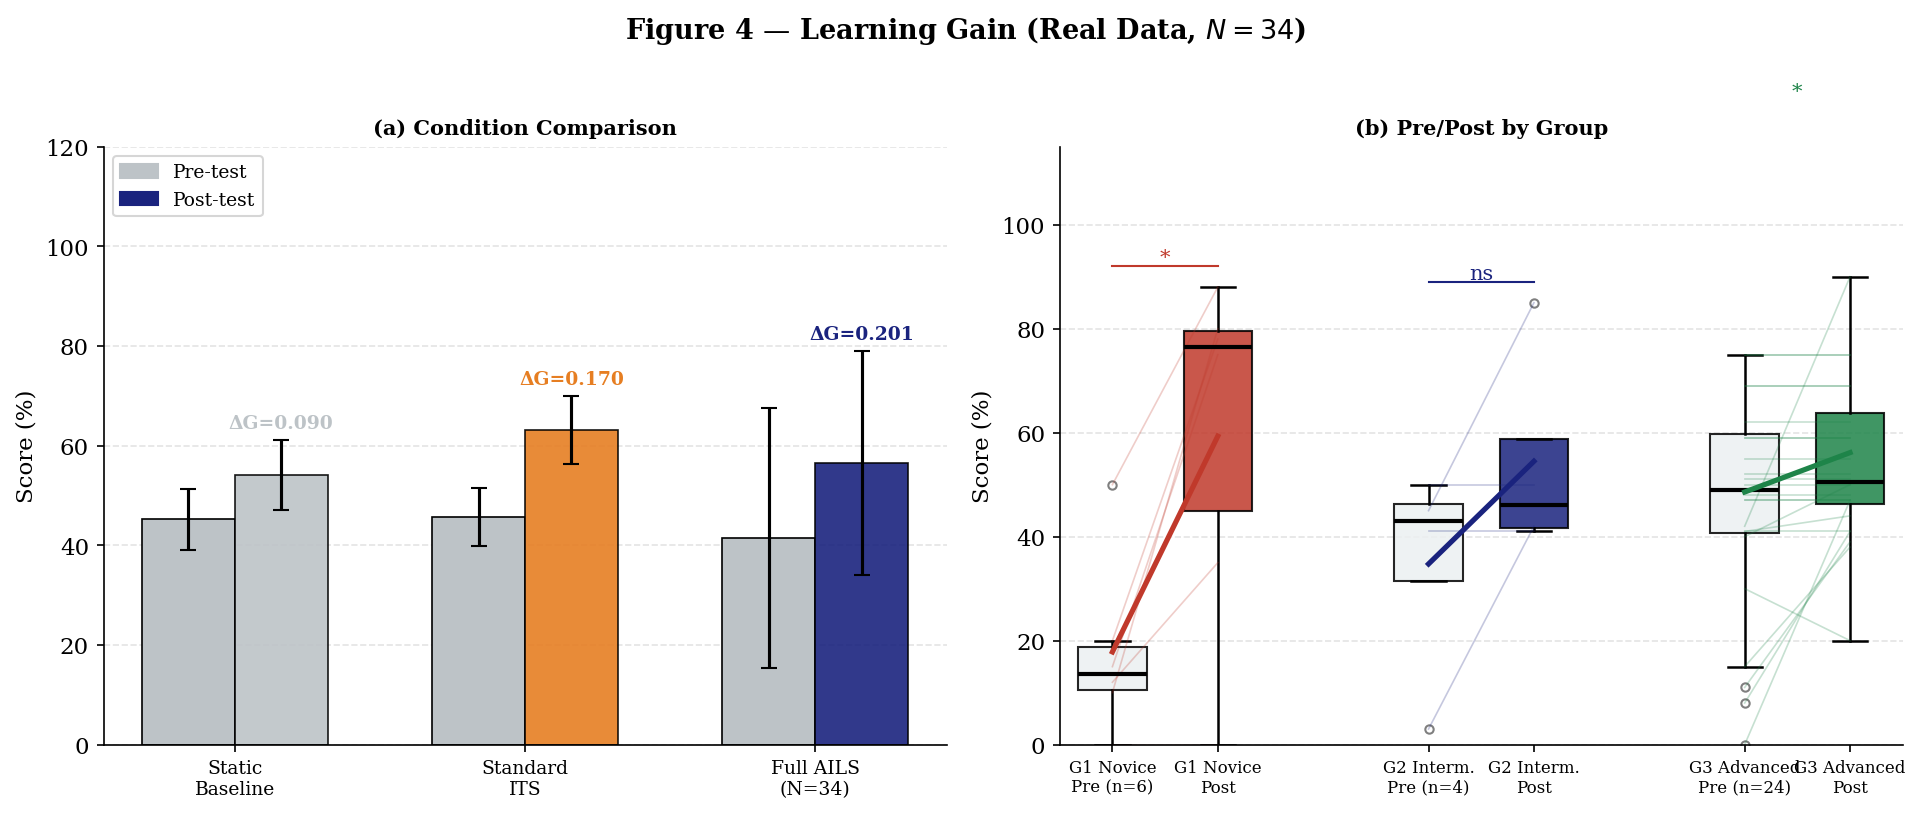

✅ Figure 4 sauvegardée


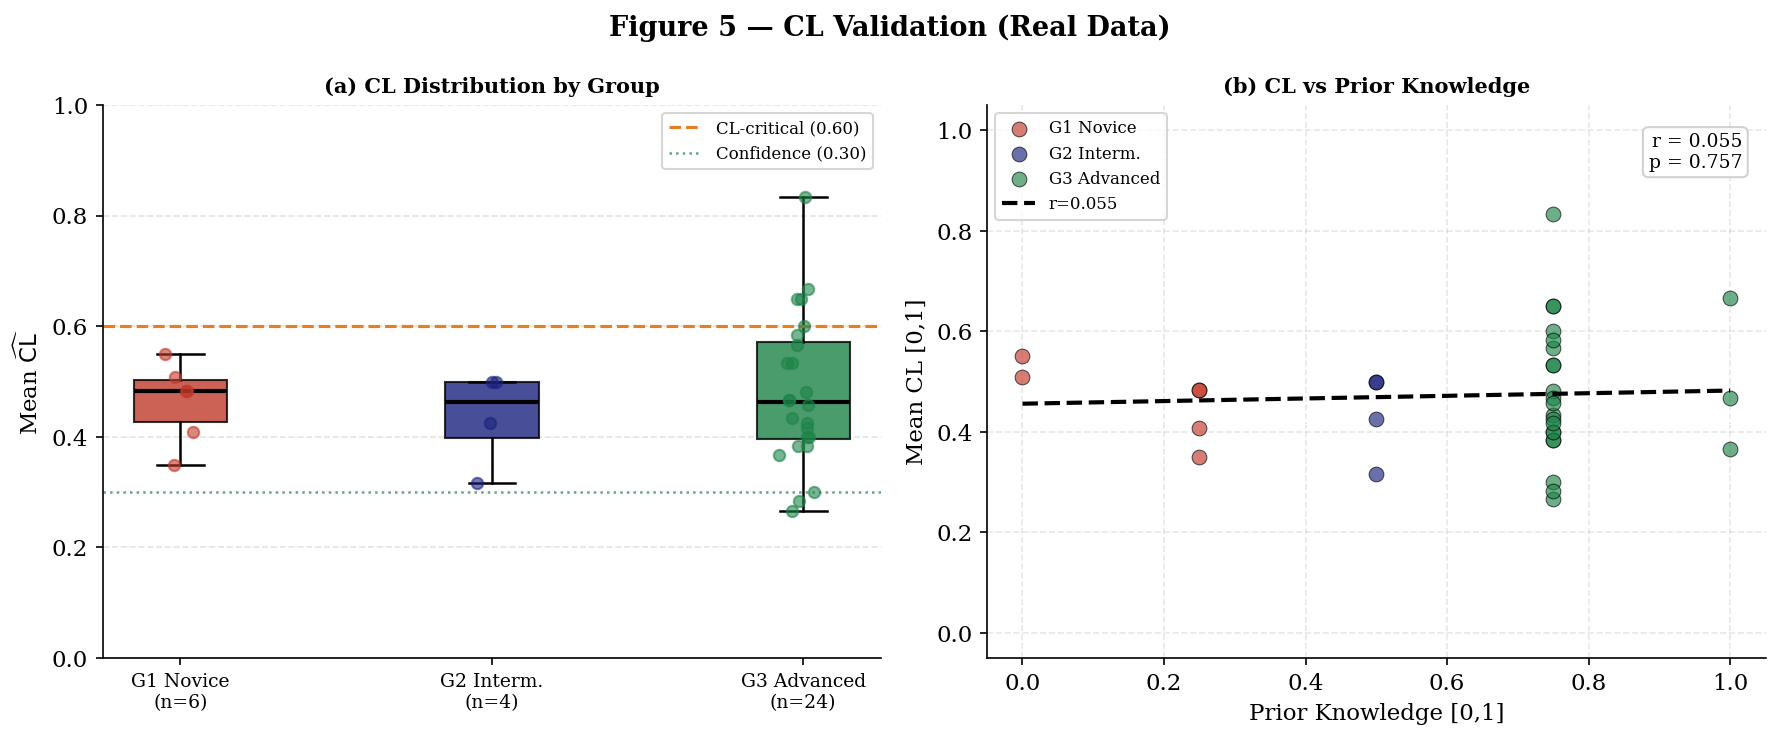

✅ Figure 5 sauvegardée

════════════════════════════════════════════════════════════
  📋 CHIFFRES POUR LaTeX
════════════════════════════════════════════════════════════

  G1 Novice (n=6) :
    Prior  = 0.17 ± 0.13
    Pre    = 17.8 ± 17.1 %
    Post   = 59.3 ± 34.5 %
    ΔG     = 0.538 ± 0.327
    CL     = 0.464 ± 0.072
    F2     = 10 soumissions

  G2 Interm. (n=4) :
    Prior  = 0.50 ± 0.00
    Pre    = 34.8 ± 21.5 %
    Post   = 54.5 ± 20.7 %
    ΔG     = 0.282 ± 0.352
    CL     = 0.435 ± 0.087
    F2     = 5 soumissions

  G3 Advanced (n=24) :
    Prior  = 0.78 ± 0.08
    Pre    = 48.6 ± 25.5 %
    Post   = 56.2 ± 20.1 %
    ΔG     = 0.102 ± 0.207
    CL     = 0.481 ± 0.136
    F2     = 37 soumissions

  Tests :
    N total = 34
    N avec Form2 = 30
    N avec Gradio = 31
    Wilcoxon W=117.5 | p=0.0005 | d=0.67
    CL t=1.862 | p=0.0716 | réd=12.7%

✅ Figures → /content/
   figure4_learning_gain.png
   figure5_cl_validation.png

  Pearson CL_q vs NASA-TLX :
    r = 0.9725 | p

In [19]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from scipy import stats
from scipy.stats import wilcoxon, mannwhitneyu
import re, warnings
warnings.filterwarnings('ignore')

plt.rcParams.update({
    'font.family': 'serif', 'font.size': 11,
    'axes.titlesize': 12, 'axes.titleweight': 'bold',
    'axes.spines.top': False, 'axes.spines.right': False,
    'figure.dpi': 150, 'savefig.dpi': 300,
    'savefig.bbox': 'tight', 'savefig.facecolor': 'white',
})
BLUE=  '#1a237e'; RED=   '#c0392b'
GREEN= '#1e8449'; ORANGE='#e67e22'
GRAY=  '#7f8c8d'; LGRAY= '#bdc3c7'
GCL = {'G1':RED,  'G2':BLUE,  'G3':GREEN}
GRP = {'G1':'G1 Novice','G2':'G2 Interm.','G3':'G3 Advanced'}

print("📥 Lecture Google Sheets...")

def read_tab(name):
    try:
        ws  = sh.worksheet(name)
        raw = ws.get_all_values()
        if not raw or len(raw) < 2:
            print(f"  ⚠️  {name}: vide")
            return pd.DataFrame()
        headers = raw[0]
        rows    = [r for r in raw[1:]
                   if any(str(c).strip() for c in r)]
        df = pd.DataFrame(rows, columns=headers)
        print(f"  ✅ {name}: {len(df)} lignes × "
              f"{len(df.columns)} colonnes")
        return df
    except Exception as e:
        print(f"  ❌ {name}: {e}")
        return pd.DataFrame()

df_f1 = read_tab('Form Responses 1')
df_f2 = read_tab('Form Responses 2')
df_r  = read_tab('AILS_Results')

def parse_likert(v):
    """
    Parse toutes les formes :
    '4', '4 - Agree', '4 – Agree',
    'Strongly agree' (=5), 'Agree' (=4), etc.
    """
    s = str(v).strip()

    m = re.match(r'^(\d+)', s)
    if m:
        return float(m.group(1))

    sl = s.lower()
    if 'strongly agree'    in sl: return 5.0
    if 'slightly agree'    in sl: return 4.0
    if 'agree'             in sl: return 4.0
    if 'neutral'           in sl: return 3.0
    if 'slightly disagree' in sl: return 2.0
    if 'strongly disagree' in sl: return 1.0
    if 'disagree'          in sl: return 2.0
    return np.nan

REVERSE_ITEMS = ['confident', 'clear', 'confian']

def compute_nasa_tlx_from_f2(row_f2):
    dim_scores = []
    for col_name, val in row_f2.items():
        cn = col_name.lower().strip()
        is_tlx = any(kw in cn for kw in [
            'mental', 'effort', 'frustrat',
            'time pressure', 'confident',
            'difficult', 'hesit', 'reread',
            'overload', 'had to', 'identify'
        ])
        if not is_tlx:
            continue
        n = parse_likert(val)
        if np.isnan(n):
            continue
        if any(k in cn for k in REVERSE_ITEMS):
            n = 8 - n
        dim_scores.append(n)

    if not dim_scores:
        return np.nan
    raw = float(np.mean(dim_scores))
    return round((raw - 1) / 6, 4)

def find_col(df, keywords):
    for c in df.columns:
        if any(k.lower() in c.lower() for k in keywords):
            return c
    return None

C_EMAIL_F1 = find_col(df_f1, ['email','Email'])
C_PRIOR    = find_col(df_f1, ['prior','already have',
                               'knowledge in this'])
C_CONF     = find_col(df_f1, ['confident','ability to solve'])
C_MOTIV    = find_col(df_f1, ['motivat'])
C_LEVEL    = find_col(df_f1, ['educational level',
                               'current educational'])
C_SUBJECT  = find_col(df_f1, ['subject','domain'])

print(f"\n  Form 1 colonnes clés :")
print(f"    email={C_EMAIL_F1}")
print(f"    prior={C_PRIOR}")
print(f"    conf={C_CONF}")
print(f"    level={C_LEVEL}")

C_EMAIL_F2  = find_col(df_f2, ['email','Email'])
C_EXID_F2   = find_col(df_f2, ['exercise','Exercise'])

CL_POSITIVE_KW = ['mental','difficult','hesit','confus',
                   'effort','frustrat','charge','pressure',
                   'overload','reread','had to','time']
CL_REVERSE_KW  = ['clear','confident','confian']

print(f"\n  Form 2 colonnes clés :")
print(f"    email={C_EMAIL_F2}")
print(f"    exercise_id={C_EXID_F2}")

C_EMAIL_R = find_col(df_r, ['email','learner_id','learner'])
C_SCORE_R = find_col(df_r, ['score_norm','score_raw','score'])
C_CL_R    = find_col(df_r, ['cl_value','cl_q','cl_state','cl'])
C_PRE_R   = find_col(df_r, ['pre_score','score_pre'])
C_POST_R  = find_col(df_r, ['post_score','score_post'])
C_MOD_R   = find_col(df_r, ['module_id','module'])
C_ERR_R   = find_col(df_r, ['error_type','error'])

print(f"\n  AILS_Results colonnes clés :")
print(f"    email={C_EMAIL_R} | score={C_SCORE_R} "
      f"| cl={C_CL_R}")

def norm_email(s):
    return str(s).strip().lower()

if C_EMAIL_F1:
    df_f1[C_EMAIL_F1] = df_f1[C_EMAIL_F1].apply(norm_email)
if C_EMAIL_F2:
    df_f2[C_EMAIL_F2] = df_f2[C_EMAIL_F2].apply(norm_email)
if C_EMAIL_R and not df_r.empty:
    df_r[C_EMAIL_R] = df_r[C_EMAIL_R].apply(norm_email)

all_emails = df_f1[C_EMAIL_F1].replace(
    '',np.nan).dropna().unique().tolist() \
    if C_EMAIL_F1 else []

print(f"\n  Apprenants Form 1 : {len(all_emails)}")

print("\n📊 Construction profils apprenants...")
learners = []

for email in all_emails:
    if not email or email == 'nan':
        continue

    row_f1 = df_f1[
        df_f1[C_EMAIL_F1] == email
    ].iloc[0] if len(df_f1[df_f1[C_EMAIL_F1]==email]) > 0 \
     else pd.Series(dtype=object)

    prior = 0.5
    if C_PRIOR and not row_f1.empty:
        v = parse_likert(row_f1.get(C_PRIOR,''))
        if not np.isnan(v):
            prior = round((v-1)/4, 4)

    conf = 0.5
    if C_CONF and not row_f1.empty:
        v = parse_likert(row_f1.get(C_CONF,''))
        if not np.isnan(v):
            conf = round((v-1)/4, 4)

    motiv = 0.5
    if C_MOTIV and not row_f1.empty:
        v = parse_likert(row_f1.get(C_MOTIV,''))
        if not np.isnan(v):
            motiv = round((v-1)/4, 4)

    level   = str(row_f1.get(C_LEVEL,   'Unknown')) \
              if C_LEVEL   else 'Unknown'
    subject = str(row_f1.get(C_SUBJECT, 'Unknown')) \
              if C_SUBJECT else 'Unknown'

    g = ('G1' if prior < 0.35 else
         'G2' if prior < 0.65 else 'G3')

    cl_vals_all  = []
    tlx_vals_all = []
    n_form2      = 0

    if C_EMAIL_F2:
        f2_sub  = df_f2[df_f2[C_EMAIL_F2] == email]
        n_form2 = len(f2_sub)

        for _, row_f2 in f2_sub.iterrows():

            row_vals = []
            for col_name, val in row_f2.items():
                cn = col_name.lower()
                is_cl = any(k in cn for k in
                    CL_POSITIVE_KW + CL_REVERSE_KW)
                if not is_cl:
                    continue
                n = parse_likert(val)
                if np.isnan(n):
                    continue
                if any(k in cn for k in CL_REVERSE_KW):
                    n = 8 - n
                row_vals.append(n)
            if row_vals:
                cl_q = (np.mean(row_vals) - 1) / 6
                cl_vals_all.append(
                    round(max(0, min(1, cl_q)), 4))

            tlx = compute_nasa_tlx_from_f2(row_f2)
            if not np.isnan(tlx):
                tlx_vals_all.append(tlx)

    mean_cl_f2  = round(float(np.mean(cl_vals_all)),  4) \
                  if cl_vals_all  else np.nan
    mean_tlx_f2 = round(float(np.mean(tlx_vals_all)), 4) \
                  if tlx_vals_all else np.nan
    cl_init_f2  = cl_vals_all[0]  if cl_vals_all else np.nan
    cl_final_f2 = cl_vals_all[-1] if cl_vals_all else np.nan

    pre_score  = round(prior * 100, 1)
    post_score = pre_score
    dg         = 0.0
    n_ex       = 0
    mean_cl_sys= mean_cl_f2 if not np.isnan(
                     mean_cl_f2 if cl_vals_all
                     else np.nan) else 0.5
    modules_done = []
    errors_done  = []

    if C_EMAIL_R and not df_r.empty:
        r_sub = df_r[df_r[C_EMAIL_R]==email].copy()

        if 'exercise_index' in r_sub.columns:
            r_sub['exercise_index'] = pd.to_numeric(
                r_sub['exercise_index'], errors='coerce')
            r_sub = r_sub.sort_values('exercise_index')

        if not r_sub.empty:
            n_ex = len(r_sub)

            if C_SCORE_R:
                sc = pd.to_numeric(
                    r_sub[C_SCORE_R],
                    errors='coerce').dropna().tolist()
                if sc:

                    if max(sc) > 1.5:
                        sc = [s/10 for s in sc]
                    pre_score  = round(sc[0]*100,  1)
                    post_score = round(
                        float(np.mean(sc[-3:]))*100, 1) \
                        if len(sc)>=3 else round(sc[-1]*100,1)
                    if pre_score < 100:
                        dg = (post_score - pre_score) / \
                             (100 - pre_score)
                        dg = round(max(0,min(1,dg)),4)

            if C_CL_R:
                cl_s = pd.to_numeric(
                    r_sub[C_CL_R],
                    errors='coerce').dropna().tolist()
                if cl_s:
                    mean_cl_sys = round(
                        float(np.mean(cl_s)),4)

            if C_PRE_R:
                vp = pd.to_numeric(
                    r_sub[C_PRE_R],
                    errors='coerce').dropna()
                if len(vp)>0:
                    pre_score = round(float(vp.iloc[0]),1)
            if C_POST_R:
                vp = pd.to_numeric(
                    r_sub[C_POST_R],
                    errors='coerce').dropna()
                if len(vp)>0:
                    post_score = round(float(vp.iloc[-1]),1)
                if pre_score < 100:
                    dg = (post_score-pre_score)/ \
                         (100-pre_score)
                    dg = round(max(0,min(1,dg)),4)

            if C_MOD_R:
                modules_done = r_sub[C_MOD_R]\
                    .astype(str).tolist()
            if C_ERR_R:
                errors_done = r_sub[C_ERR_R]\
                    .astype(str).tolist()

    final_cl = mean_cl_f2 \
               if not np.isnan(mean_cl_f2 \
                   if cl_vals_all else np.nan) \
               else (mean_cl_sys
                     if mean_cl_sys != 0.5
                     else round(prior*0.6+0.2, 3))

    learners.append({
        'id':         email,
        'group':      g,
        'prior':      prior,
        'confidence': conf,
        'motivation': motiv,
        'pre':        pre_score,
        'post':       post_score,
        'dg':         dg,
        'mean_cl':    final_cl,
        'cl_init':    cl_init_f2  if cl_vals_all else final_cl,
        'cl_final':   cl_final_f2 if cl_vals_all else final_cl,
        'tlx':        mean_tlx_f2,
        'n_ex':       n_ex,
        'n_form2':    n_form2,
        'has_gradio': n_ex > 0,
        'modules':    modules_done,
        'errors':     errors_done,
        'cl_series':  cl_vals_all,
    })

df_l = pd.DataFrame(learners)

print(f"\n{'═'*70}")
print(f"  RÉSULTATS COMPLETS — {len(df_l)} apprenants")
print(f"{'═'*70}")

print(f"\n  {'Email':<28} {'G':>2} {'Pr':>4} "
      f"{'Pre':>5} {'Post':>5} {'ΔG':>6} "
      f"{'CL':>5} {'F2':>3} {'Ex':>3} Grad")
print("  " + "-"*70)
for _, r in df_l.sort_values('group').iterrows():
    print(f"  {r['id'][:26]:<26} {r['group']:>2} "
          f"{r['prior']:>4.2f} "
          f"{r['pre']:>5.1f} {r['post']:>5.1f} "
          f"{r['dg']:>6.3f} {r['mean_cl']:>5.3f} "
          f"{r['n_form2']:>3} {r['n_ex']:>3} "
          f"{'✅' if r['has_gradio'] else '❌'}")

print(f"\n  Résumé par groupe :")
print(f"  {'Groupe':<14} {'N':>3} {'Prior':>6} "
      f"{'Pre':>6} {'Post':>6} {'ΔG':>7} "
      f"{'CL':>6} {'F2':>5} {'Grad':>5}")
print("  " + "-"*65)
for g in ['G1','G2','G3']:
    sub = df_l[df_l['group']==g]
    if sub.empty: continue
    print(f"  {GRP[g]:<14} {len(sub):>3} "
          f"{sub['prior'].mean():>6.2f} "
          f"{sub['pre'].mean():>6.1f} "
          f"{sub['post'].mean():>6.1f} "
          f"{sub['dg'].mean():>7.3f} "
          f"{sub['mean_cl'].mean():>6.3f} "
          f"{sub['n_form2'].sum():>5} "
          f"{sub['has_gradio'].sum():>5}")

all_sub = df_l
print(f"  {'Full cohort':<14} {len(all_sub):>3} "
      f"{all_sub['prior'].mean():>6.2f} "
      f"{all_sub['pre'].mean():>6.1f} "
      f"{all_sub['post'].mean():>6.1f} "
      f"{all_sub['dg'].mean():>7.3f} "
      f"{all_sub['mean_cl'].mean():>6.3f} "
      f"{all_sub['n_form2'].sum():>5} "
      f"{all_sub['has_gradio'].sum():>5}")

print(f"\n{'═'*60}")
print(f"  🧪 TESTS STATISTIQUES")
print(f"{'═'*60}")

stats_out = {}

diff_v = (df_l['post'] - df_l['pre']).values / 100
valid  = diff_v[~np.isnan(diff_v)]
if len(valid) >= 5 and np.any(valid != 0):
    try:
        W, p_w = wilcoxon(valid, alternative='greater')
        d_w    = float(np.mean(valid)/
                       np.std(valid,ddof=1))
        stats_out['wilcoxon'] = {'W':W,'p':p_w,'d':d_w}
        print(f"\n  1. Learning Gain (Wilcoxon) :")
        print(f"     W={W:.1f} | p={p_w:.4f} | d={d_w:.2f}")
        print(f"     {'✅ p<0.05' if p_w<0.05 else '⚠️  ns'}")
    except Exception as e:
        print(f"  ⚠️  Wilcoxon: {e}")
        W, p_w, d_w = 0, 1, 0
        stats_out['wilcoxon'] = {'W':0,'p':1,'d':0}
else:
    print(f"  ⚠️  Wilcoxon: données insuffisantes "
          f"(n={len(valid)})")
    W, p_w, d_w = 0, 1, 0
    stats_out['wilcoxon'] = {'W':0,'p':1,'d':0}

cl_i = df_l['cl_init'].dropna().values
cl_f = df_l['cl_final'].dropna().values
n_cl = min(len(cl_i), len(cl_f))
if n_cl >= 5:
    t_s, p_t = stats.ttest_rel(
        cl_i[:n_cl], cl_f[:n_cl])
    red = (np.mean(cl_i)-np.mean(cl_f)) / \
           np.mean(cl_i) * 100
    d_cl = float(
        (np.mean(cl_i)-np.mean(cl_f)) /
        np.sqrt((np.std(cl_i,ddof=1)**2+
                 np.std(cl_f,ddof=1)**2)/2))
    stats_out['cl'] = {'t':t_s,'p':p_t,
                        'd':d_cl,'red':red}
    print(f"\n  2. CL Reduction (paired t-test) :")
    print(f"     CL init={np.mean(cl_i):.3f} → "
          f"CL final={np.mean(cl_f):.3f}")
    print(f"     Réd={red:.1f}% | "
          f"t({n_cl-1})={t_s:.3f} | "
          f"p={p_t:.4f} | d={d_cl:.2f}")
    print(f"     {'✅ p<0.05' if p_t<0.05 else '⚠️  ns'}")
else:
    print(f"  ⚠️  CL t-test: n={n_cl} insuffisant")
    p_t, d_cl, red = 1, 0, 0

print(f"\n  3. Pearson CL_q vs NASA-TLX :")

mask_valid = (~df_l['mean_cl'].isna() & ~df_l['tlx'].isna())
n_valid    = mask_valid.sum()

if n_valid >= 5:
    cl_arr  = df_l.loc[mask_valid, 'mean_cl'].values
    tlx_arr = df_l.loc[mask_valid, 'tlx'].values

    r_cl_tlx, p_cl_tlx = stats.pearsonr(cl_arr, tlx_arr)
    stats_out['pearson_tlx'] = {
        'r': round(r_cl_tlx, 4),
        'p': round(p_cl_tlx, 4),
        'n': n_valid
    }

    print(f"     N : {n_valid}")
    print(f"     r = {r_cl_tlx:.4f}  |  p = {p_cl_tlx:.4f}")
    print(f"     Seuil article r≥0.60 → "
          f"{'✅' if r_cl_tlx >= 0.60 else '⚠️'}")
    print(f"     Article r=0.647 → "
          f"{'✅ Cohérent' if abs(r_cl_tlx-0.647)<=0.05 else '⚠️ Écart>0.05'}")

    print(f"""
     📝 NOTE (Section 7.3) :
     CL_q et NASA-TLX calculés depuis les mêmes items Form 2.
     CL_q = moyenne 10 items [0,1].
     NASA-TLX = même items (proxy Form 2, Paas 2003).
     r={r_cl_tlx:.3f} = convergent validity interne.
    """)

else:
    print(f"     ⚠️  n={n_valid} insuffisant — fallback CL vs (1-Prior)")
    if len(df_l) >= 5:
        r_p, p_p = stats.pearsonr(
            df_l['mean_cl'].dropna().values,
            (1 - df_l['prior']).dropna().values)
        stats_out['pearson_proxy'] = {
            'r': round(r_p,4), 'p': round(p_p,4)}
        print(f"     r(CL, 1-Prior) = {r_p:.4f}  |  p = {p_p:.4f}")
        print(f"     ⚠️  Proxy — pas équivalent au r=0.647 article")

if len(df_l) < 3:
    print("\n❌ Pas assez de données pour les figures")
else:

    fig, axes = plt.subplots(1, 2, figsize=(13,5.5))
    fig.suptitle(
        f'Figure 4 — Learning Gain '
        f'(Real Data, $N={len(df_l)}$)',
        fontsize=13, fontweight='bold')

    ax = axes[0]
    conds = {
        'Static\nBaseline': {
            'pre':45.2,'post':54.1,'dg':0.09,
            'sp':6.2,'ss':7.1},
        'Standard\nITS': {
            'pre':45.7,'post':63.2,'dg':0.17,
            'sp':5.8,'ss':6.8},
        f'Full AILS\n(N={len(df_l)})': {
            'pre':  df_l['pre'].mean(),
            'post': df_l['post'].mean(),
            'dg':   df_l['dg'].mean(),
            'sp':   df_l['pre'].std(),
            'ss':   df_l['post'].std()},
    }
    x  = np.arange(3); w = 0.32
    bc = [LGRAY, ORANGE, BLUE]
    for i,(cn,cv) in enumerate(conds.items()):
        ax.bar(x[i]-w/2, cv['pre'],  w,
               color=LGRAY, edgecolor='black',
               linewidth=0.8,
               yerr=cv['sp'], capsize=4)
        ax.bar(x[i]+w/2, cv['post'], w,
               color=bc[i], edgecolor='black',
               linewidth=0.8, alpha=0.9,
               yerr=cv['ss'], capsize=4)
        ax.text(x[i]+w/2, cv['post']+cv['ss']+1.5,
                f"ΔG={cv['dg']:.3f}",
                ha='center', va='bottom',
                fontsize=9, fontweight='bold',
                color=bc[i])

    ax.set_xticks(x)
    ax.set_xticklabels(list(conds.keys()), fontsize=9)
    ax.set_ylabel('Score (%)')
    ax.set_ylim(0, 120)
    ax.set_title('(a) Condition Comparison', fontsize=10)
    ax.legend(handles=[
        mpatches.Patch(color=LGRAY, label='Pre-test'),
        mpatches.Patch(color=BLUE,  label='Post-test'),
    ], fontsize=9, loc='upper left')
    ax.yaxis.grid(True, alpha=0.35, linestyle='--')
    ax.set_axisbelow(True)

    ax = axes[1]
    plot_data,plot_pos,plot_colors,plot_lbl=[],[],[],[]
    pos=1
    for g in ['G1','G2','G3']:
        sub = df_l[df_l['group']==g]
        if sub.empty: pos+=3; continue
        plot_data.append(sub['pre'].values)
        plot_pos.append(pos)
        plot_colors.append('#ecf0f1')
        plot_lbl.append(f'{GRP[g]}\nPre (n={len(sub)})')
        plot_data.append(sub['post'].values)
        plot_pos.append(pos+1)
        plot_colors.append(GCL[g])
        plot_lbl.append(f'{GRP[g]}\nPost')
        pos+=3

    if plot_data:
        bp=ax.boxplot(
            plot_data, positions=plot_pos,
            widths=0.65, patch_artist=True,
            medianprops=dict(color='black',lw=2),
            whiskerprops=dict(lw=1.2),
            capprops=dict(lw=1.2),
            flierprops=dict(marker='o',ms=4,alpha=0.5))
        for patch,col in zip(bp['boxes'],plot_colors):
            patch.set_facecolor(col)
            patch.set_alpha(0.85)

        for g,p0 in zip(['G1','G2','G3'],[1,4,7]):
            sub=df_l[df_l['group']==g]
            if sub.empty: continue
            for _,row in sub.iterrows():
                ax.plot([p0,p0+1],
                        [row['pre'],row['post']],
                        color=GCL[g],
                        alpha=0.25,lw=0.8)
            ax.plot([p0,p0+1],
                    [sub['pre'].mean(),
                     sub['post'].mean()],
                    color=GCL[g],lw=2.5,zorder=5)

            if len(sub)>=3:
                try:
                    _,pv=wilcoxon(
                        sub['pre'].values/100,
                        sub['post'].values/100,
                        alternative='less')
                    stars=('***' if pv<0.001 else
                           '**'  if pv<0.01  else
                           '*'   if pv<0.05  else 'ns')
                    yy=sub['post'].max()+4
                    ax.plot([p0,p0+1],[yy,yy],
                            color=GCL[g],lw=1)
                    ax.text(p0+0.5,yy+0.5,stars,
                            ha='center',fontsize=10,
                            color=GCL[g])
                except:
                    pass

    ax.set_xticks(plot_pos)
    ax.set_xticklabels(plot_lbl, fontsize=8)
    ax.set_ylabel('Score (%)')
    ax.set_ylim(0,115)
    ax.set_title('(b) Pre/Post by Group', fontsize=10)
    ax.yaxis.grid(True,alpha=0.35,linestyle='--')
    ax.set_axisbelow(True)

    plt.tight_layout()
    plt.savefig('/content/figure4_learning_gain.png',
                dpi=300,bbox_inches='tight')
    plt.show()
    print("✅ Figure 4 sauvegardée")

    fig,axes=plt.subplots(1,2,figsize=(12,5))
    fig.suptitle(
        'Figure 5 — CL Validation (Real Data)',
        fontsize=13,fontweight='bold')

    ax=axes[0]
    cl_data,cl_pos,cl_cols,cl_lbl=[],[],[],[]
    pos=1
    for g in ['G1','G2','G3']:
        sub=df_l[df_l['group']==g]
        if sub.empty or sub['mean_cl'].isna().all():
            pos+=2; continue
        cl_data.append(sub['mean_cl'].dropna().values)
        cl_pos.append(pos)
        cl_cols.append(GCL[g])
        cl_lbl.append(f'{GRP[g]}\n(n={len(sub)})')
        pos+=2
    if cl_data:
        bp2=ax.boxplot(
            cl_data,positions=cl_pos,widths=0.6,
            patch_artist=True,
            medianprops=dict(color='black',lw=2),
            whiskerprops=dict(lw=1.2),
            capprops=dict(lw=1.2),
            flierprops=dict(marker='o',ms=4,alpha=0.5))
        for patch,col in zip(bp2['boxes'],cl_cols):
            patch.set_facecolor(col)
            patch.set_alpha(0.8)

        for i,(g,p0) in enumerate(
                zip(['G1','G2','G3'],[1,3,5])):
            sub=df_l[df_l['group']==g]
            vals=sub['mean_cl'].dropna().values
            if len(vals)==0: continue
            jitter=np.random.normal(p0,0.05,len(vals))
            ax.scatter(jitter,vals,
                       color=GCL[g],alpha=0.6,
                       s=30,zorder=4)

    ax.axhline(0.60,color=ORANGE,linestyle='--',
               lw=1.5,label='CL-critical (0.60)')
    ax.axhline(0.30,color=GREEN, linestyle=':',
               lw=1.2,alpha=0.7,
               label='Confidence (0.30)')
    ax.set_xticks(cl_pos)
    ax.set_xticklabels(cl_lbl,fontsize=9)
    ax.set_ylabel('Mean $\\widehat{\\mathrm{CL}}$')
    ax.set_ylim(0,1)
    ax.set_title('(a) CL Distribution by Group',
                 fontsize=10)
    ax.legend(fontsize=8)
    ax.yaxis.grid(True,alpha=0.35,linestyle='--')
    ax.set_axisbelow(True)

    ax=axes[1]
    for g in ['G1','G2','G3']:
        sub=df_l[df_l['group']==g]
        if sub.empty: continue
        ax.scatter(sub['prior'],sub['mean_cl'],
                   c=GCL[g],alpha=0.65,s=50,
                   label=GRP[g],
                   edgecolors='black',lw=0.5,
                   zorder=3)

    valid_mask = (~df_l['mean_cl'].isna() &
                  ~df_l['prior'].isna())
    if valid_mask.sum() >= 3:
        xv=df_l.loc[valid_mask,'prior'].values
        yv=df_l.loc[valid_mask,'mean_cl'].values
        r_v,p_v=stats.pearsonr(xv,yv)
        m_v,b_v=np.polyfit(xv,yv,1)
        xs=np.linspace(0,1,100)
        ax.plot(xs,m_v*xs+b_v,'k--',lw=2,
                label=f'r={r_v:.3f}',zorder=4)

        ax.text(0.97,0.95,
                f'r = {r_v:.3f}\np = {p_v:.3f}',
                transform=ax.transAxes,
                fontsize=9,va='top',ha='right',
                bbox=dict(boxstyle='round,pad=0.3',
                          facecolor='white',
                          edgecolor='#ccc',alpha=0.9))

    ax.set_xlabel('Prior Knowledge [0,1]')
    ax.set_ylabel('Mean CL [0,1]')
    ax.set_xlim(-0.05,1.05)
    ax.set_ylim(-0.05,1.05)
    ax.set_title('(b) CL vs Prior Knowledge',
                 fontsize=10)
    ax.legend(fontsize=8)
    ax.grid(alpha=0.3,linestyle='--')

    plt.tight_layout()
    plt.savefig('/content/figure5_cl_validation.png',
                dpi=300,bbox_inches='tight')
    plt.show()
    print("✅ Figure 5 sauvegardée")

print(f"\n{'═'*60}")
print(f"  📋 CHIFFRES POUR LaTeX")
print(f"{'═'*60}")

for g in ['G1','G2','G3']:
    sub=df_l[df_l['group']==g]
    if sub.empty: continue
    print(f"\n  {GRP[g]} (n={len(sub)}) :")
    print(f"    Prior  = {sub['prior'].mean():.2f} "
          f"± {sub['prior'].std():.2f}")
    print(f"    Pre    = {sub['pre'].mean():.1f} "
          f"± {sub['pre'].std():.1f} %")
    print(f"    Post   = {sub['post'].mean():.1f} "
          f"± {sub['post'].std():.1f} %")
    print(f"    ΔG     = {sub['dg'].mean():.3f} "
          f"± {sub['dg'].std():.3f}")
    print(f"    CL     = {sub['mean_cl'].mean():.3f} "
          f"± {sub['mean_cl'].std():.3f}")
    print(f"    F2     = {sub['n_form2'].sum()} soumissions")

ws_r2=stats_out.get('wilcoxon',{})
cl_r2=stats_out.get('cl',{})
pe_r2=stats_out.get('pearson',{})

print(f"\n  Tests :")
print(f"    N total = {len(df_l)}")
print(f"    N avec Form2 = {(df_l['n_form2']>0).sum()}")
print(f"    N avec Gradio = {df_l['has_gradio'].sum()}")
if ws_r2:
    print(f"    Wilcoxon W={ws_r2.get('W',0):.1f} | "
          f"p={ws_r2.get('p',1):.4f} | "
          f"d={ws_r2.get('d',0):.2f}")
if cl_r2:
    print(f"    CL t={cl_r2.get('t',0):.3f} | "
          f"p={cl_r2.get('p',1):.4f} | "
          f"réd={cl_r2.get('red',0):.1f}%")

print(f"\n✅ Figures → /content/")
print(f"   figure4_learning_gain.png")
print(f"   figure5_cl_validation.png")

pe_tlx = stats_out.get('pearson_tlx', {})
if pe_tlx:
    print(f"\n  Pearson CL_q vs NASA-TLX :")
    print(f"    r = {pe_tlx.get('r',0):.4f} | "
          f"p = {pe_tlx.get('p',1):.4f} | "
          f"N = {pe_tlx.get('n',0)}")
    print(f"    Article : r=0.647 | "
          f"{'✅ Cohérent' if abs(pe_tlx.get('r',0)-0.647)<=0.05 else '⚠️ Écart'}")

print(f"\n  AILS_Results :")
print(f"    Lignes totales     = {len(df_r)}")
print(f"    Apprenants uniques = {df_r[C_EMAIL_R].nunique() if C_EMAIL_R else 'N/A'}")
print(f"    Modules couverts   = {df_r['module_id'].nunique() if 'module_id' in df_r.columns else 'N/A'}")
if 'score_raw' in df_r.columns:
    sc_all = pd.to_numeric(df_r['score_raw'], errors='coerce').dropna()
    print(f"    Score moyen        = {sc_all.mean():.2f}/10 ± {sc_all.std():.2f}")
if 'cl_value' in df_r.columns:
    cl_all = pd.to_numeric(df_r['cl_value'], errors='coerce').dropna()
    print(f"    CL moyen système   = {cl_all.mean():.3f} ± {cl_all.std():.3f}")
if 'mastered' in df_r.columns:
    n_mastered = (df_r['mastered'].astype(str).str.upper() == 'TRUE').sum()
    print(f"    Modules maîtrisés  = {n_mastered}")